In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils_data_clean
import missingno as msno
import plotly.express as px
from matplotlib.gridspec import GridSpec
from scipy.stats import chi2_contingency,f_oneway,jarque_bera,probplot
from sklearn.preprocessing import PowerTransformer

In [2]:
df = pd.read_csv('swiggy.csv')

In [3]:
df.sample(10)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
19000,0xb247,VADRES12DEL02,29,4.9,0.000000,0.000000,0.050000,0.050000,05-04-2022,17:10:00,17:20:00,conditions Fog,Medium,0,Buffet,motorcycle,0,No,Metropolitian,(min) 29
31497,0x8159,RANCHIRES08DEL03,31,4.8,23.353783,85.326967,23.383783,85.356967,03-03-2022,17:55:00,18:10:00,conditions Sunny,Medium,2,Drinks,scooter,NaN,No,Metropolitian,(min) 19
20626,0x7ff0,RANCHIRES20DEL01,36,4.8,23.399250,85.390464,23.409250,85.400464,26-03-2022,08:55:00,09:10:00,conditions Windy,Low,2,Snack,scooter,1,No,Metropolitian,(min) 22
941,0x2e4e,CHENRES18DEL02,31,4.8,12.981615,80.231598,13.031615,80.281598,28-03-2022,21:00:00,21:10:00,conditions Cloudy,Jam,0,Drinks,motorcycle,1,No,Metropolitian,(min) 30
16948,0x41d4,MUMRES08DEL03,39,4.5,19.065838,72.832658,19.095838,72.862658,05-04-2022,17:45:00,18:00:00,conditions Sunny,Medium,2,Meal,scooter,1,No,Metropolitian,(min) 23
10138,0xb37f,BANGRES20DEL02,22,4.7,12.972161,77.596014,13.052161,77.676014,04-03-2022,19:40:00,19:50:00,conditions Cloudy,Jam,0,Drinks,motorcycle,1,No,Metropolitian,(min) 35
40871,0x6c73,BANGRES010DEL02,22,4.9,12.933298,77.614293,13.063298,77.744293,04-03-2022,22:55:00,23:05:00,conditions Stormy,Low,1,Buffet,scooter,1,No,Urban,(min) 19
43084,0xbe3c,BANGRES17DEL03,27,4.2,12.972532,77.608179,13.032532,77.668179,30-03-2022,23:50:00,00:00:00,conditions Sandstorms,Low,0,Snack,motorcycle,1,No,Metropolitian,(min) 29
12289,0xdca3,AURGRES04DEL01,26,4.5,19.876106,75.340775,19.986106,75.450775,18-02-2022,23:25:00,23:30:00,conditions Stormy,Low,0,Buffet,motorcycle,0,No,NaN,(min) 22
6231,0x983e,VADRES18DEL02,38,5,0.000000,0.000000,0.080000,0.080000,20-03-2022,20:10:00,20:25:00,conditions Fog,Jam,2,Snack,scooter,1,Yes,Metropolitian,(min) 43


In [4]:
#Data Cleaning
data_clean = utils_data_clean.perform_data_cleaning(data=df)
data_clean.shape

(37695, 16)

In [5]:
# load the cleaned data
df_final = pd.read_csv('cleaned_data.csv')

In [6]:
df_final.shape

(45502, 30)

In [7]:
#Check for missing values in the data
df_final.isnull().sum()

rider_id                    0
age                      1854
ratings                  1908
restaurant_latitude      4029
restaurant_longitude     3765
delivery_latitude        3630
delivery_longitude       3630
order_date                  0
order_time               1640
order_picked_time           0
weather                   525
traffic                   510
vehicle_condition           0
type_of_order               0
type_of_vehicle             0
multiple_deliveries       993
festival                  228
city_type                1198
time_taken                  0
city_name                   0
restaurment_latitude        0
restaurment_longitude       0
order_day                   0
order_month                 0
order_day_of_week           0
is_weekend                  0
pickup_time_minutes      1640
order_time_hour          1640
order_time_of_day           0
distance                 4029
dtype: int64

In [8]:
#Number of rows in the data that having missing values
missing_rows_cnt = df_final.isnull().any(axis=1).sum()
print(f"There are {missing_rows_cnt} rows with missing valus in the data.")
print(f"It accounts for {(missing_rows_cnt/df_final.shape[0])*100:.2f}% of the data")

There are 7584 rows with missing valus in the data.
It accounts for 16.67% of the data


<span style="background-color:#1f2937; color:#fbbf24; padding:4px 10px; border-radius:999px;">
The initial percentage of missing data was 9.2% and increased to 16.67% because we transformed 0 values in the lat long columns to NaN
</span>

In [9]:
#There are no duplicate rows
df_final.duplicated().sum()

np.int64(0)

In [10]:
# data types of features
df_final.dtypes

rider_id                  object
age                      float64
ratings                  float64
restaurant_latitude      float64
restaurant_longitude     float64
delivery_latitude        float64
delivery_longitude       float64
order_date                object
order_time                object
order_picked_time         object
weather                   object
traffic                   object
vehicle_condition          int64
type_of_order             object
type_of_vehicle           object
multiple_deliveries      float64
festival                  object
city_type                 object
time_taken                 int64
city_name                 object
restaurment_latitude     float64
restaurment_longitude    float64
order_day                  int64
order_month                int64
order_day_of_week         object
is_weekend                 int64
pickup_time_minutes      float64
order_time_hour          float64
order_time_of_day         object
distance                 float64
dtype: obj

In [11]:
num_cols = df_final.select_dtypes(exclude='object').columns.tolist()
cat_cols = df_final.select_dtypes(include='object').columns.tolist()

print(f'There are {len(num_cols)} numerical columns and {len(cat_cols)} categorical columns in the data.')

There are 17 numerical columns and 13 categorical columns in the data.


In [12]:
# statistical summary of numerical columns
df_final[num_cols].describe()    

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,vehicle_condition,multiple_deliveries,time_taken,restaurment_latitude,restaurment_longitude,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,distance
count,43648.000000,43594.000000,41473.000000,41737.000000,41872.000000,41872.000000,45502.000000,44509.000000,45502.000000,45502.000000,45502.000000,45502.000000,45502.000000,45502.000000,43862.000000,43862.000000,41473.000000
mean,29.555008,4.635287,18.898979,76.920513,18.977356,76.985325,1.019406,0.744928,26.297591,17.404823,70.785107,13.811657,2.980726,0.274867,9.989399,17.423966,9.719256
std,5.761482,0.313827,5.460570,3.503334,5.469056,3.503260,0.835229,0.572488,9.386419,7.332705,21.111115,8.709540,0.546031,0.446452,4.087516,4.817856,5.602950
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,0.000000,0.000000,1.000000,2.000000,0.000000,5.000000,0.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,0.000000,0.000000,19.000000,12.934179,73.170283,6.000000,3.000000,0.000000,5.000000,15.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,1.000000,1.000000,26.000000,18.554382,75.898497,13.000000,3.000000,0.000000,10.000000,19.000000,9.193021
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000,32.000000,22.732225,78.046106,20.000000,3.000000,1.000000,15.000000,21.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000,30.914057,88.433452,31.000000,4.000000,1.000000,15.000000,23.000000,20.969489


In [13]:
# statistical summary of categorical columns
df_final.assign(**{
    col: df_final[col].astype('object')
    for col in cat_cols}).describe(include='object').T

,count,unique,top,freq
rider_id,45502,1320,PUNERES01DEL01,67
order_date,45502,44,2022-03-15,1190
order_time,43862,176,2026-02-24 21:55:00,461
order_picked_time,45502,193,2026-02-24 21:30:00,496
weather,44977,6,fog,7654
traffic,44992,4,low,15477
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029


<Axes: >

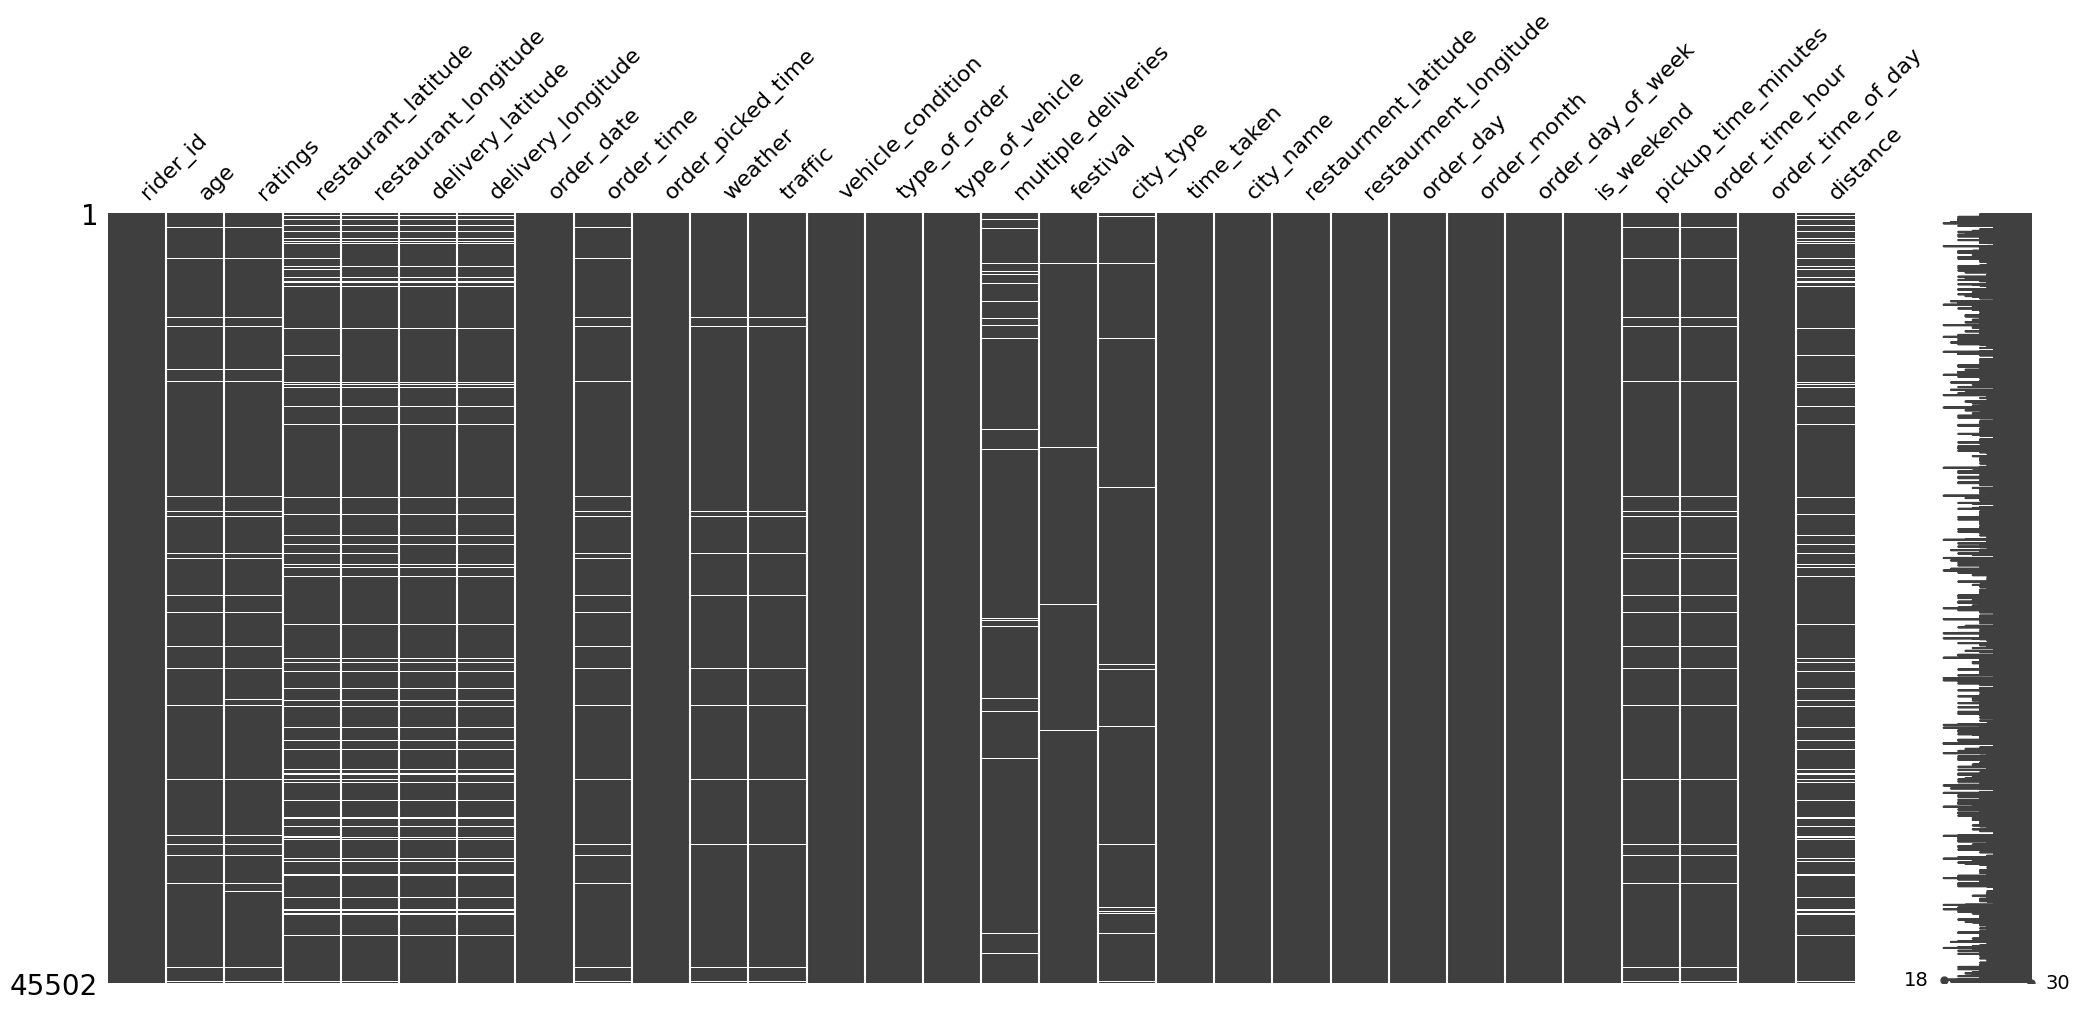

In [14]:
msno.matrix(df_final)

<Axes: >

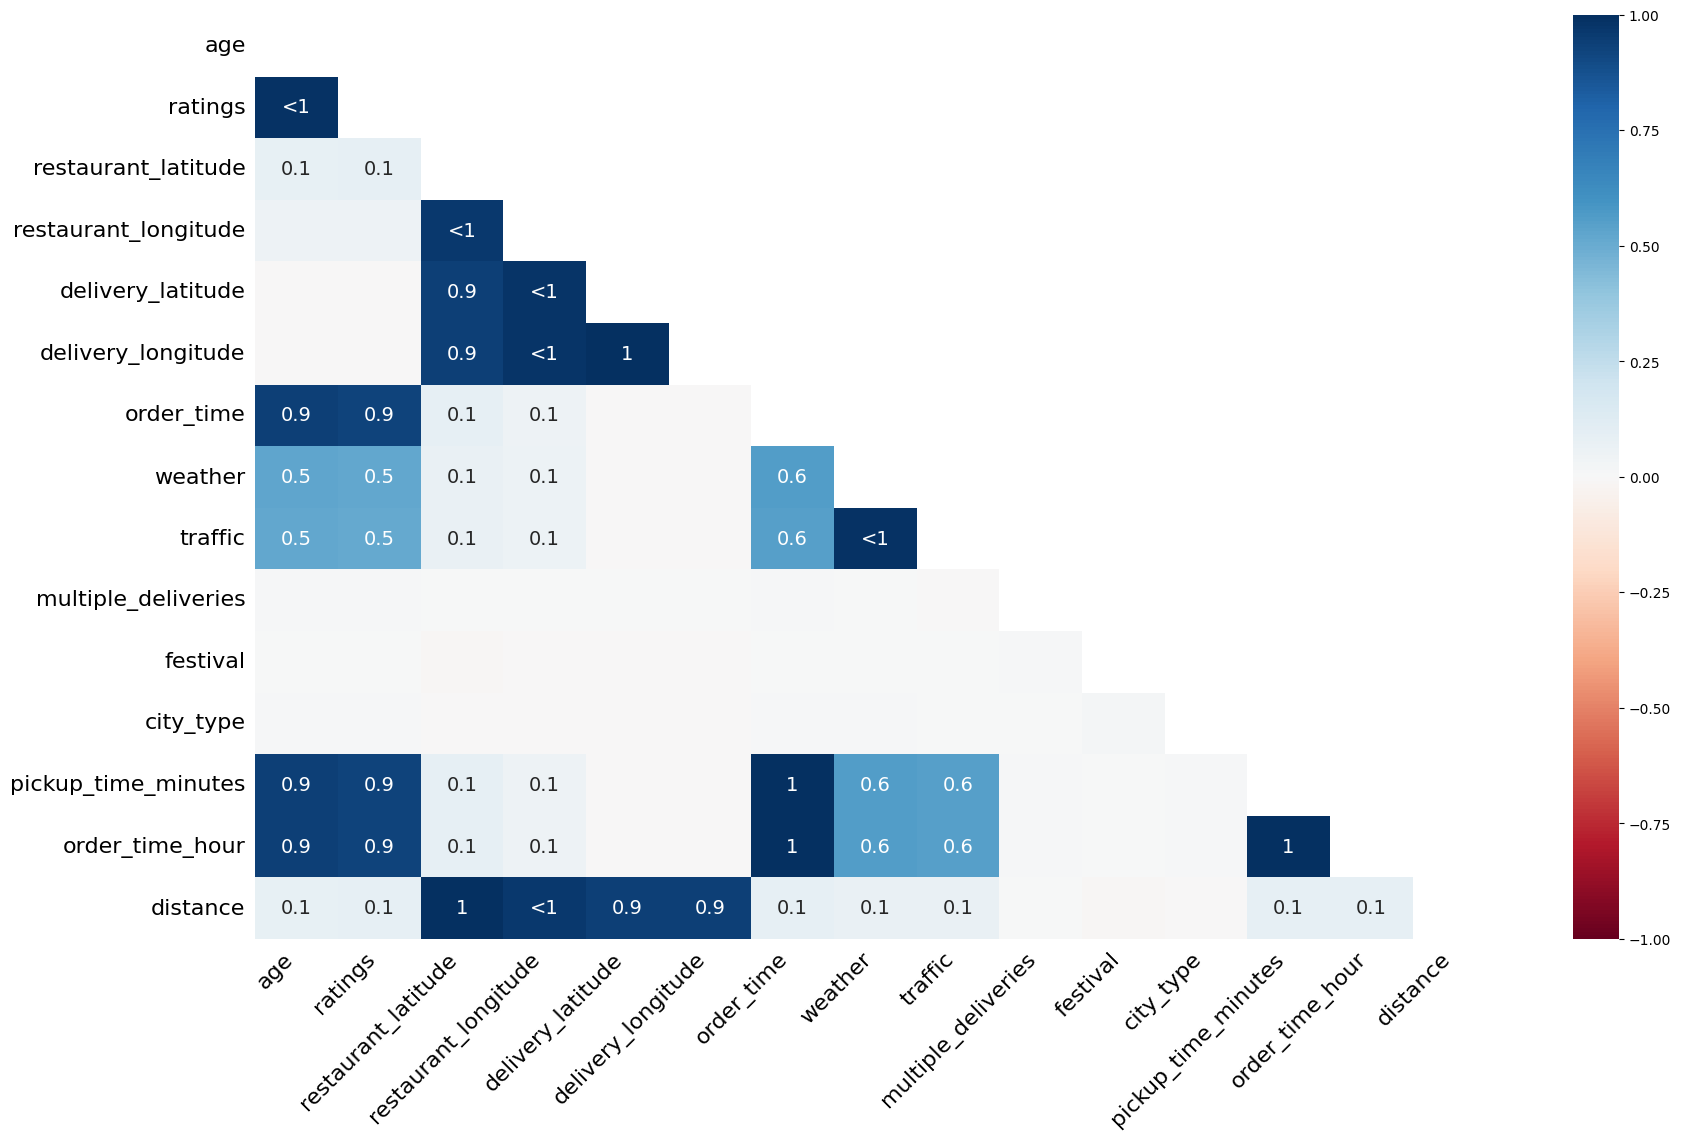

In [15]:
msno.heatmap(df_final)

<Axes: >

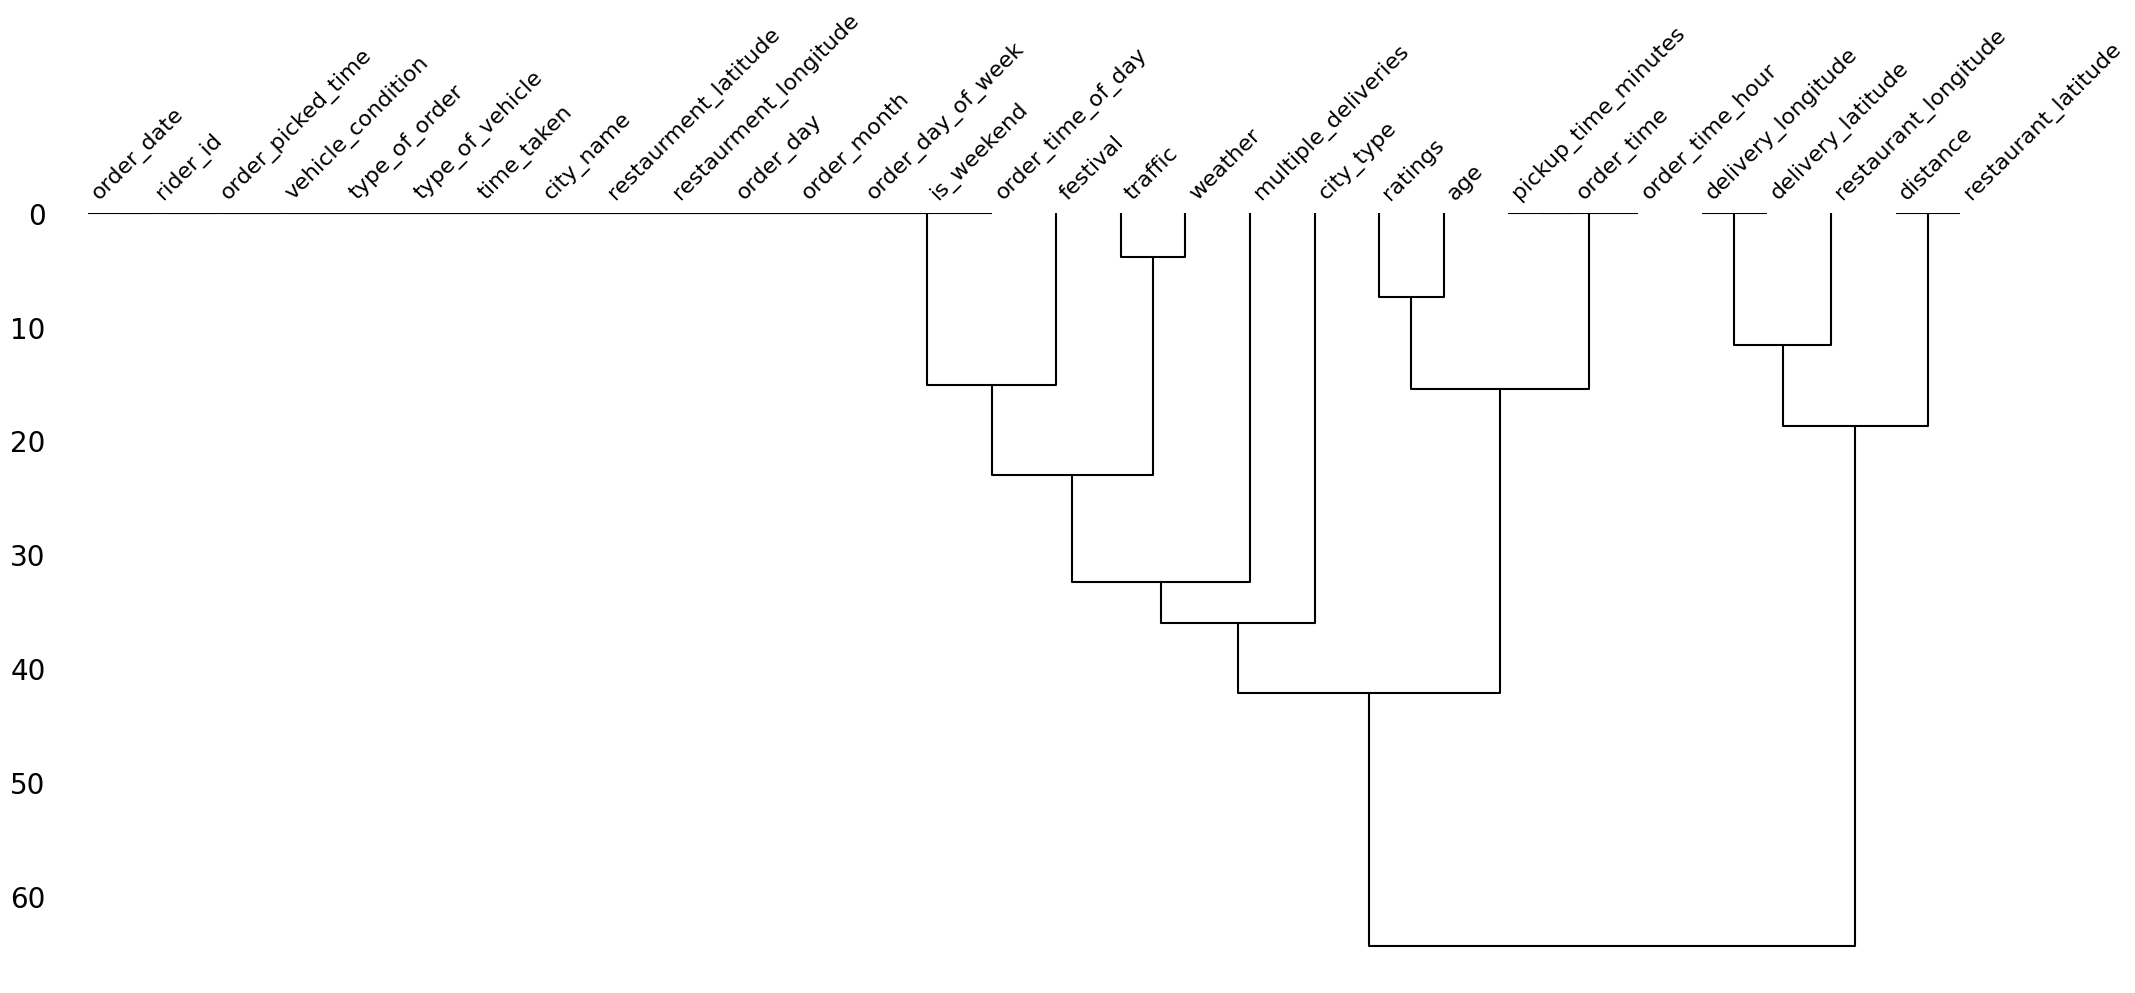

In [16]:
msno.dendrogram(df_final)

## Functions to perform analysis

In [17]:
def numerical_analysis(dataframe, num_col, cat_col=None, bins="auto"):
    """
    Perform detailed numerical analysis with visualization and statistics.

    Parameters:
    ----------
    dataframe : pandas.DataFrame
        Input dataset.
    num_col : str
        Numerical column to analyze.
    cat_col : str, optional
        Categorical column for comparison.
    bins : int or str, default='auto'
        Bin size for histogram.
    """

    data = dataframe[num_col].dropna()

    # ---------- Statistical Summary ----------
    mean = data.mean()
    median = data.median()
    std = data.std()
    skewness = data.skew()
    kurtosis = data.kurt()

    print("📊 Statistical Summary")
    print(f"Mean      : {mean:.3f}")
    print(f"Median    : {median:.3f}")
    print(f"Std Dev   : {std:.3f}")
    print(f"Skewness  : {skewness:.3f}")
    print(f"Kurtosis  : {kurtosis:.3f}")

    # ---------- Distribution Insight ----------
    if skewness > 0.5:
        print("➡ Distribution is Right Skewed")
    elif skewness < -0.5:
        print("⬅ Distribution is Left Skewed")
    else:
        print("⚖ Distribution is approximately Symmetric")

    # ---------- Outlier Detection (IQR) ----------
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)]
    print(f"🚨 Number of Outliers (IQR method): {outliers.shape[0]}")

    # ---------- Visualization ----------
    fig = plt.figure(figsize=(16, 10))
    grid = GridSpec(2, 2, figure=fig)

    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])

    sns.kdeplot(data=dataframe, x=num_col, hue=cat_col, ax=ax1, fill=True)
    ax1.set_title("Density Plot")

    sns.boxplot(data=dataframe, x=num_col, hue=cat_col, ax=ax2)
    ax2.set_title("Box Plot (Outliers & Spread)")

    sns.histplot(
        data=dataframe,
        x=num_col,
        bins=bins,
        hue=cat_col,
        kde=True,
        ax=ax3
    )
    ax3.set_title("Histogram with KDE")

    plt.tight_layout()
    plt.show()

In [18]:
def numerical_categorical_analysis(dataframe,cat_column_1,num_column):
    fig,(ax1,ax2) = plt.subplots(2,2,figsize=(15,7.5))
    sns.barplot(data=dataframe,x=cat_column_1,y=num_column,ax=ax1[0])
    sns.boxplot(data=dataframe,x=cat_column_1,y=num_column,ax=ax1[1])
    sns.violinplot(data=dataframe,x=cat_column_1,y=num_column,ax=ax2[0])
    sns.stripplot(data=dataframe,x=cat_column_1,y=num_column,ax=ax2[1])
    plt.tight_layout()
    plt.show()

In [19]:
def categorical_analysis(dataframe,column_name):
    df = pd.DataFrame({"Count":dataframe[column_name].value_counts(),"Percentage":dataframe[column_name].value_counts(normalize=True).mul(100).round(2).astype("str").add("%")})
    display(df)
    print("*" * 50)
    unique_categories = dataframe[column_name].unique().tolist()
    number_of_categories = dataframe[column_name].nunique()
    print(f"The unique categories in {column_name} column are {unique_categories}")
    print("*" * 50)
    print(f"The number of categories in {column_name} column are {number_of_categories}")
    # plot countplot
    sns.countplot(data=dataframe, x=column_name)
    plt.xticks(rotation=45)
    plt.show()

In [20]:
def multivariate_analysis(dataframe,num_column,cat_column_1,cat_column_2):
    fig,(ax1,ax2) = plt.subplots(2,2, figsize=(15,7.5))
    sns.barplot(data=dataframe,x=cat_column_1,y=num_column,hue=cat_column_2,ax=ax1[0])
    sns.boxplot(data=dataframe,x=cat_column_1,y=num_column,hue=cat_column_2,gap=0.1,ax=ax1[1])
    sns.violinplot(data=dataframe,x=cat_column_1,y=num_column,hue=cat_column_2,gap=0.1,ax=ax2[0])
    sns.stripplot(data=dataframe,x=cat_column_1,y=num_column,hue=cat_column_2,dodge=True,ax=ax2[1])
    plt.tight_layout()
    plt.show()

In [21]:
#Chi-Square Test of Independence checks whether two categorical variables are related or independent
def chi_square_test(dataframe, col1, col2, alpha=0.05):
    """
    Perform Chi-Square Test of Independence between two categorical columns.

    Parameters:
    ----------
    dataframe : pandas.DataFrame
        Input DataFrame containing the data.
    col1 : str
        First categorical column.
    col2 : str
        Second categorical column.
    alpha : float, default=0.05
        Significance level for hypothesis testing.

    Returns:
    -------
    None
        Prints the p-value and hypothesis test conclusion.
    """

    # 1️⃣ Select required columns and drop missing values
    data = dataframe[[col1, col2]].dropna()

    # 2️⃣ Create contingency table (frequency table)
    contingency_table = pd.crosstab(data[col1], data[col2])

    # 3️⃣ Perform Chi-Square Test
    chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)

    # 4️⃣ Print results
    print(f"Chi-Square Statistic : {chi2_stat:.4f}")
    print(f"Degrees of Freedom  : {dof}")
    print(f"P-value             : {p_value:.6f}")

    # 5️⃣ Hypothesis testing decision
    if p_value <= alpha:
        print(
            f"❌ Reject the Null Hypothesis: "
            f"There is a significant association between '{col1}' and '{col2}'."
        )
    else:
        print(
            f"✅ Fail to Reject the Null Hypothesis: "
            f"There is no significant association between '{col1}' and '{col2}'."
        )

| Condition         | Conclusion                           |
| ----------------- | ------------------------------------ |
| `p_value ≤ alpha` | Reject H₀ (Significant relationship) |
| `p_value > alpha` | Fail to reject H₀ (No relationship)  |


In [22]:
#“Does the average value change when the category changes?”
def anova_test(dataframe, num_col, cat_col, alpha=0.05):
    """
    Perform One-Way ANOVA to test whether the mean of a numerical variable
    differs significantly across categories of a categorical variable.

    Parameters:
    ----------
    dataframe : pandas.DataFrame
        Input DataFrame.
    num_col : str
        Numerical column (dependent variable).
    cat_col : str
        Categorical column (independent variable).
    alpha : float, default=0.05
        Significance level.

    Returns:
    -------
    None
        Prints ANOVA statistics and hypothesis test conclusion.
    """

    # 1️⃣ Select relevant columns and remove missing values
    data = dataframe[[num_col, cat_col]].dropna()

    # 2️⃣ Group numerical values by category
    grouped_data = data.groupby(cat_col)[num_col]

    # 3️⃣ Extract numerical values for each category
    groups = [values for _, values in grouped_data]

    # 4️⃣ Perform One-Way ANOVA
    f_statistic, p_value = f_oneway(*groups)

    # 5️⃣ Print test statistics
    print(f"F-Statistic : {f_statistic:.4f}")
    print(f"P-value     : {p_value:.6f}")

    # 6️⃣ Hypothesis testing decision
    if p_value <= alpha:
        print(
            f"❌ Reject the Null Hypothesis: "
            f"The mean of '{num_col}' differs significantly across '{cat_col}' categories."
        )
    else:
        print(
            f"✅ Fail to Reject the Null Hypothesis: "
            f"There is no significant difference in '{num_col}' across '{cat_col}' categories."
        )

In [23]:
#The Jarque–Bera test checks whether a dataset follows a normal distribution based on skewness and kurtosis.
def test_normality_jarque_bera(dataframe, column, alpha=0.05):
    """
    Perform Jarque-Bera test to check whether a numerical column
    follows a normal distribution.

    Parameters:
    ----------
    dataframe : pandas.DataFrame
        Input DataFrame.
    column : str
        Numerical column to test for normality.
    alpha : float, default=0.05
        Significance level.

    Returns:
    -------
    None
        Prints test statistics and interpretation.
    """

    # 1️⃣ Drop missing values
    data = dataframe[column].dropna()

    # 2️⃣ Perform Jarque-Bera test
    jb_stat, p_value = jarque_bera(data)

    # 3️⃣ Print results
    print("📊 Jarque–Bera Test for Normality")
    print(f"JB Statistic : {jb_stat:.4f}")
    print(f"P-value      : {p_value:.6f}")

    # 4️⃣ Hypothesis testing decision
    if p_value <= alpha:
        print("❌ Reject the Null Hypothesis: The data is NOT normally distributed.\n")
    else:
        print("✅ Fail to Reject the Null Hypothesis: The data IS normally distributed.\n")

# Column Wise Analysis

In [24]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'order_time', 'order_picked_time', 'weather', 'traffic',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city_type', 'time_taken',
       'city_name', 'restaurment_latitude', 'restaurment_longitude',
       'order_day', 'order_month', 'order_day_of_week', 'is_weekend',
       'pickup_time_minutes', 'order_time_hour', 'order_time_of_day',
       'distance'],
      dtype='object')

## Time Taken (Target)

📊 Statistical Summary
Mean      : 26.298
Median    : 26.000
Std Dev   : 9.386
Skewness  : 0.486
Kurtosis  : -0.312
⚖ Distribution is approximately Symmetric
Q1: 19.0
Q3: 32.0
🚨 Number of Outliers (IQR method): 270


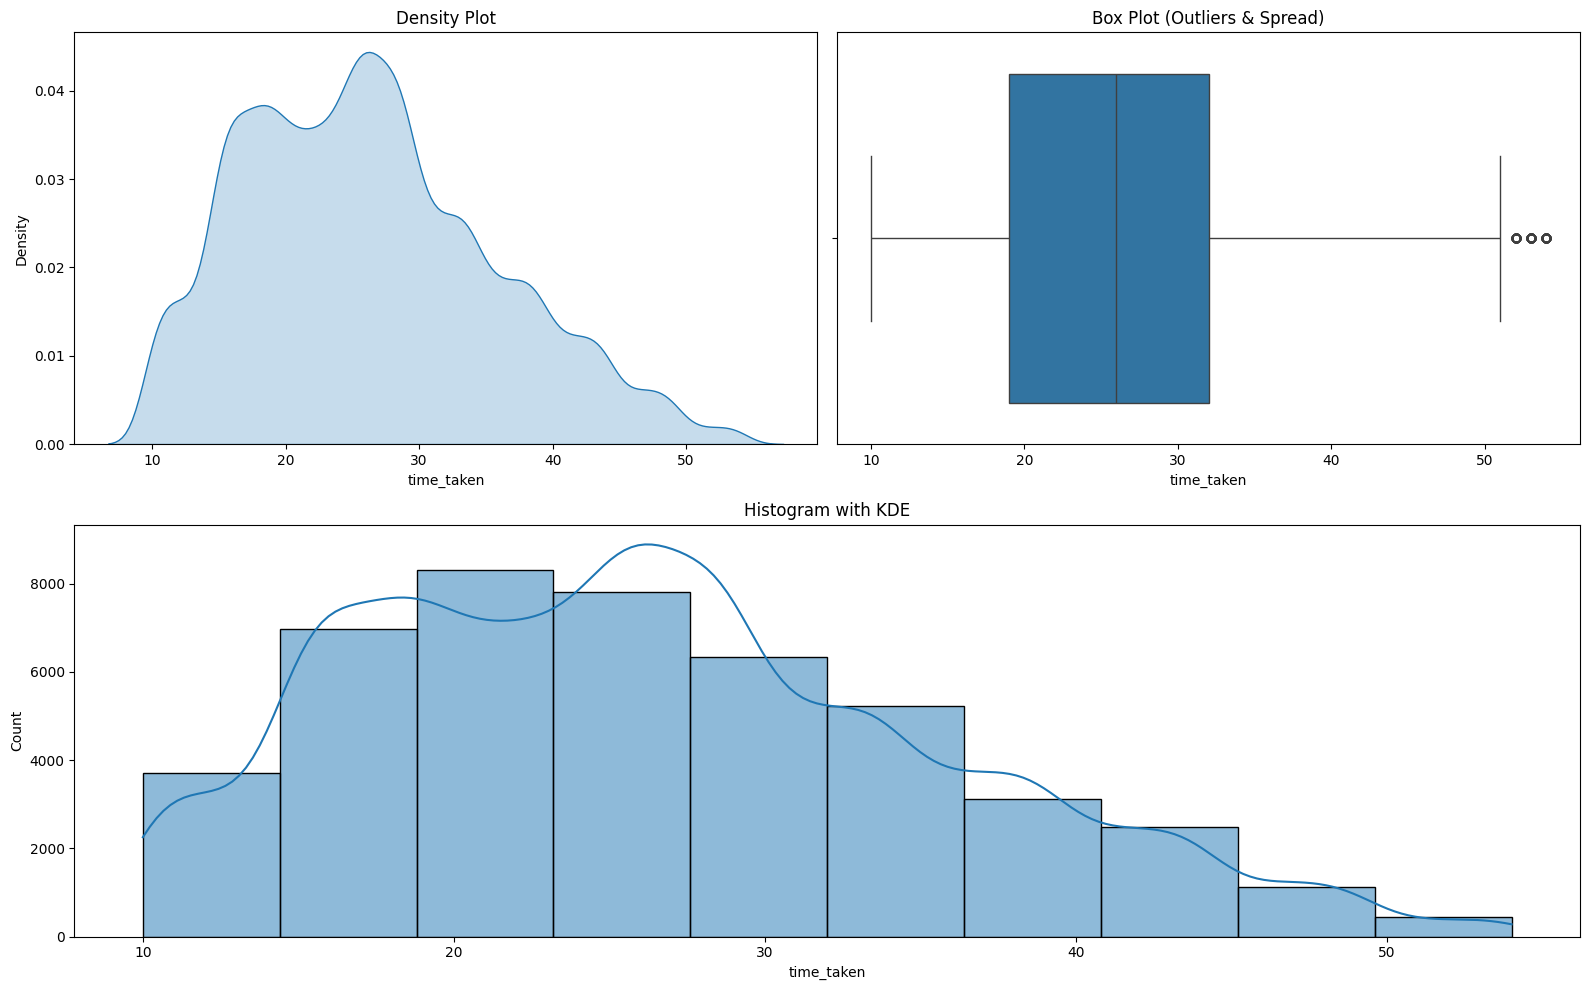

In [25]:
#numerical analysis
numerical_analysis(df_final,'time_taken',bins=10)

### 🔍 Time Taken(Column) – Observations

- <span style="color:#60a5fa;">The target column is <b>not fully continuous</b> in nature, indicating the presence of discrete or step-like values.</span>

- <span style="color:#34d399;">The distribution shows <b>dual modality</b> with two prominent peaks—one around the <b>17–18</b> range and another around the <b>26–27</b> range.</span>

- <span style="color:#facc15;">The target column contains <b>extreme but rare values</b>, which may initially appear as outliers; however, these represent valid real-world scenarios (e.g., delivery times of <b>~50 minutes</b> in exceptional cases).</span>

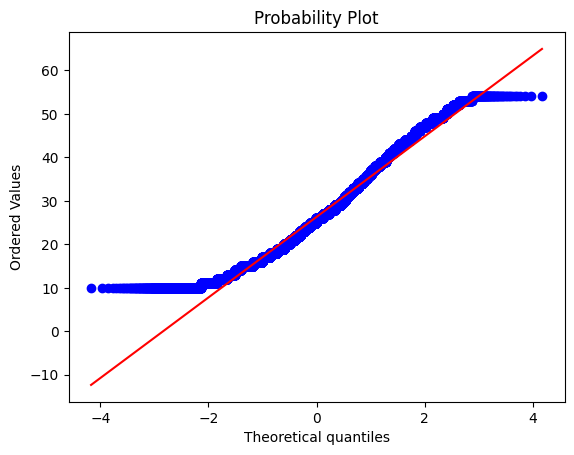

In [26]:
# plot QQ plot for the target
probplot(df_final['time_taken'],plot=plt)
plt.show()

In [27]:
#Test for normality
test_normality_jarque_bera(df_final,'time_taken')

📊 Jarque–Bera Test for Normality
JB Statistic : 1972.2806
P-value      : 0.000000
❌ Reject the Null Hypothesis: The data is NOT normally distributed.



In [28]:
# check out the rows where data is acting as outlier
Q1,Q3 = np.percentile(df_final["time_taken"],[25,75])
IQR = Q3 - Q1
upper_bound = Q3 + (1.5*IQR)

df_final.loc[(df_final['time_taken']> upper_bound),"traffic"].value_counts()

traffic
jam     241
high     24
Name: count, dtype: int64

In [29]:
df_final.loc[(df_final['time_taken'] > upper_bound),"weather"].value_counts()

weather
fog           57
sunny         51
windy         44
cloudy        44
stormy        37
sandstorms    32
Name: count, dtype: int64

In [30]:
#Average Distances
avg_distance = df_final.loc[:,"distance"].mean()
avg_distance_extreme = df_final.loc[(df_final['time_taken'] > upper_bound),'distance'].mean()

print(avg_distance,avg_distance_extreme)

9.71925622902865 13.259733986308081


📊 Statistical Summary
Mean      : 0.000
Median    : 0.088
Std Dev   : 1.000
Skewness  : -0.022
Kurtosis  : -0.591
⚖ Distribution is approximately Symmetric
Q1: -0.7357474242240921
Q3: 0.6834222301204695
🚨 Number of Outliers (IQR method): 0


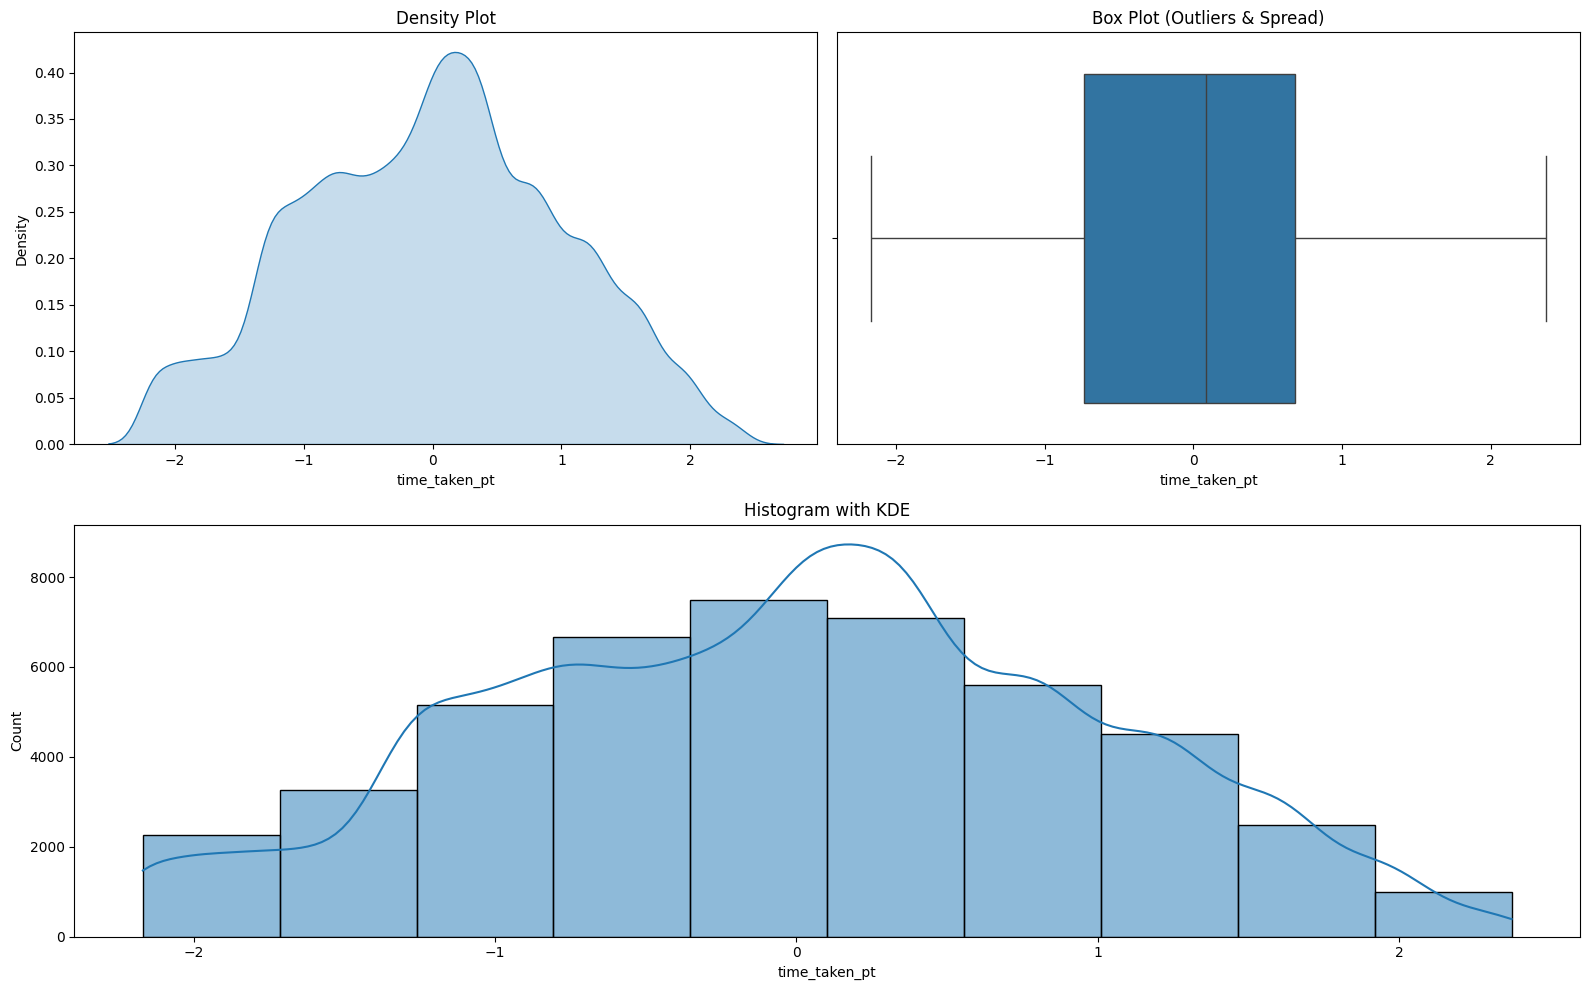

In [31]:
# fix traget column using transformation
pt = PowerTransformer(method='yeo-johnson')
df_final["time_taken_pt"] = pt.fit_transform(df_final[['time_taken']])
numerical_analysis(df_final,"time_taken_pt",bins=10)

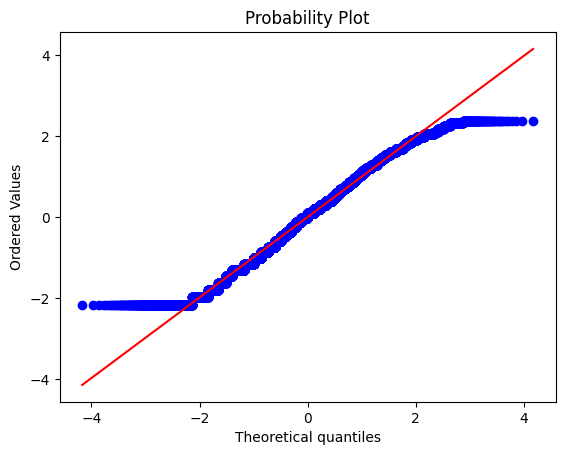

In [32]:
# plot QQ plot for the target after transformation

probplot(df_final['time_taken_pt'], plot=plt)
plt.show()     

## Rider ID

In [33]:
# datatype of rider id
df_final['rider_id'].dtype

dtype('O')

In [34]:
df_final[['rider_id',"age","ratings"]]

,rider_id,age,ratings
0,INDORES13DEL02,37.0,4.9
1,BANGRES18DEL02,34.0,4.5
2,BANGRES19DEL01,23.0,4.4
3,COIMBRES13DEL02,38.0,4.7
4,CHENRES12DEL01,32.0,4.6
...,...,...,...
45497,JAPRES04DEL01,30.0,4.8
45498,AGRRES16DEL01,21.0,4.6
45499,CHENRES08DEL03,30.0,4.9
45500,COIMBRES11DEL01,20.0,4.7


In [35]:
##Sample of data
rider_id_group = df_final[['rider_id','age','ratings']].groupby('rider_id')
rider_id_group.head(5).sort_values('rider_id')

,rider_id,age,ratings
92,AGRRES010DEL01,34.0,4.7
7738,AGRRES010DEL01,21.0,4.7
4554,AGRRES010DEL01,38.0,4.7
12416,AGRRES010DEL01,34.0,4.5
13223,AGRRES010DEL01,39.0,4.4
...,...,...,...
861,VADRES20DEL03,35.0,4.8
9792,VADRES20DEL03,30.0,4.6
9753,VADRES20DEL03,38.0,4.8
5094,VADRES20DEL03,35.0,4.9


In [36]:
# check for duplicates
df_final[['rider_id','age','ratings']].dropna().duplicated(keep=False).sum()

np.int64(10155)

In [37]:
#Filter the duplicates
df_final.loc[df_final[['rider_id','age','ratings']].duplicated(keep=False),['rider_id','age','ratings']].dropna().sort_values(['rider_id'])

,rider_id,age,ratings
18533,AGRRES03DEL02,24.0,4.9
40285,AGRRES03DEL02,24.0,4.9
28473,AGRRES03DEL03,30.0,4.7
26275,AGRRES03DEL03,30.0,4.7
36131,AGRRES06DEL02,36.0,4.9
...,...,...,...
12742,VADRES20DEL02,28.0,4.5
5094,VADRES20DEL03,35.0,4.9
17963,VADRES20DEL03,35.0,4.9
21957,VADRES20DEL03,37.0,4.9


**Not Useful for our analysis**

## Age

In [38]:
# statistical summary
df_final['age'].describe()

count    43648.000000
mean        29.555008
std          5.761482
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

📊 Statistical Summary
Mean      : 29.555
Median    : 30.000
Std Dev   : 5.761
Skewness  : -0.015
Kurtosis  : -1.209
⚖ Distribution is approximately Symmetric
Q1: 25.0
Q3: 35.0
🚨 Number of Outliers (IQR method): 0


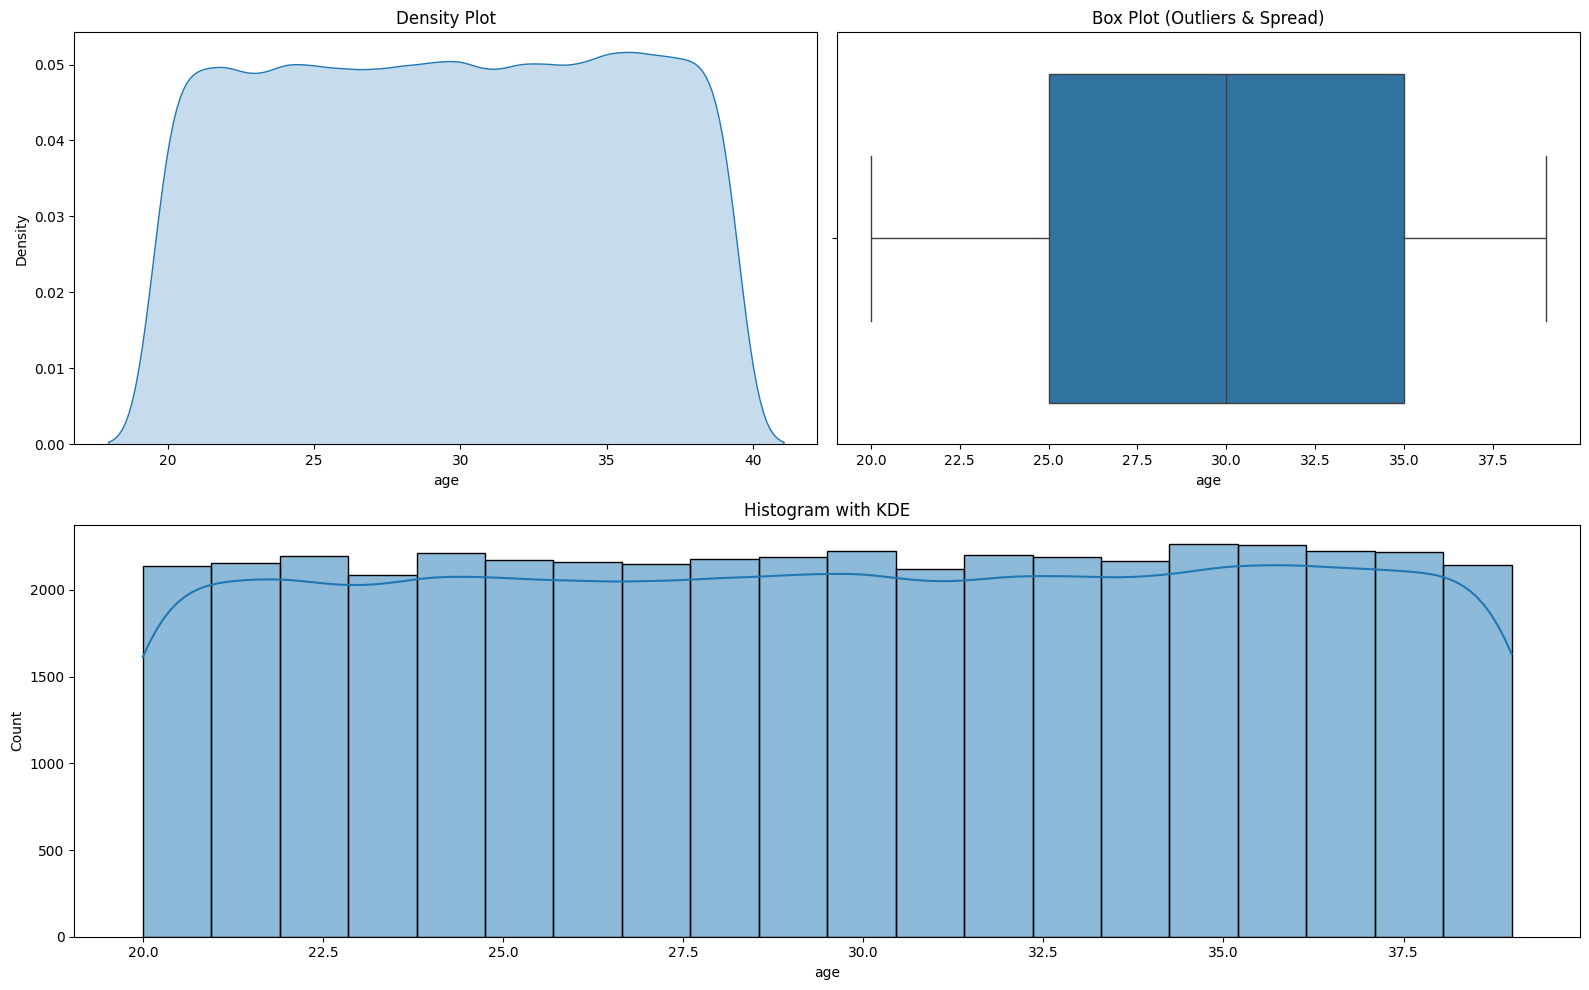

In [39]:
#numerical analysis for age
numerical_analysis(df_final,'age',bins=20)

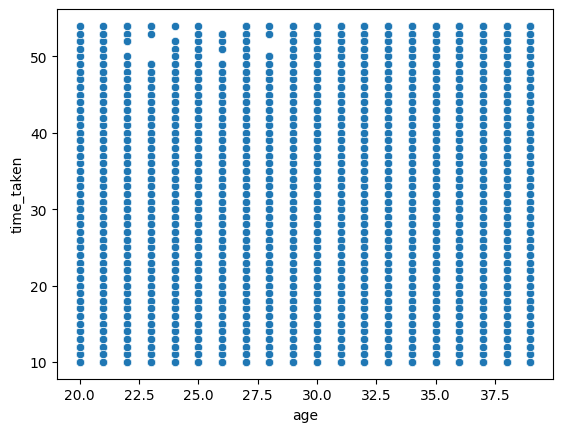

In [40]:
# relationship between target and age
sns.scatterplot(data=df_final, x='age', y='time_taken')
plt.show()

<span style="background-color:#0f5132; color:#a7f3d0; padding:4px 10px; border-radius:999px;">
Age of the rider does not show any impact on timetaken to deliver
</span>

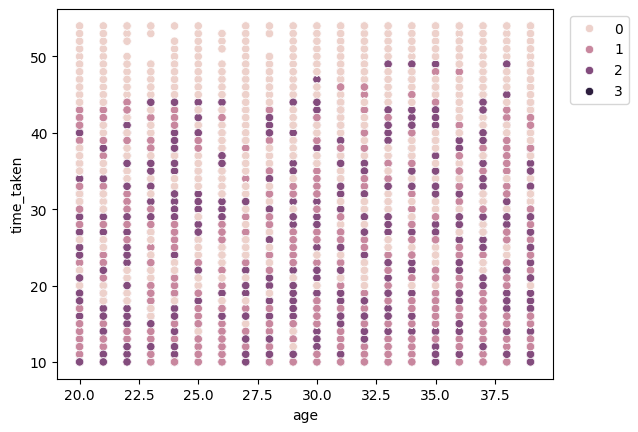

In [41]:
sns.scatterplot(data=df_final, x='age', y='time_taken', hue="vehicle_condition")
plt.legend(bbox_to_anchor=(1.02, 1), loc=2)
plt.show()

<Axes: xlabel='type_of_vehicle', ylabel='age'>

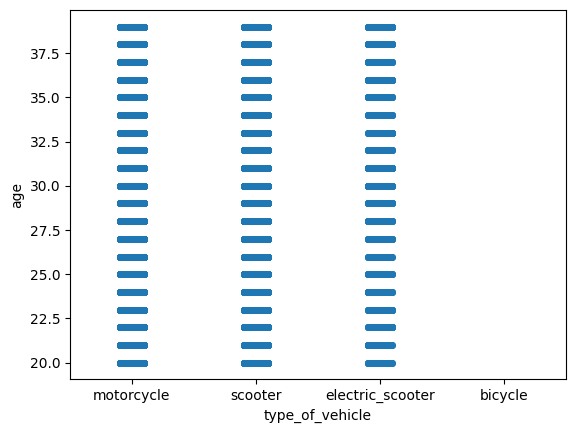

In [42]:
# preferences of vehicle type based on age
sns.stripplot(df_final,x='type_of_vehicle',y='age')

## Ratings

In [43]:
# statistical summary
df_final['ratings'].describe()

count    43594.000000
mean         4.635287
std          0.313827
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

📊 Statistical Summary
Mean      : 4.635
Median    : 4.700
Std Dev   : 0.314
Skewness  : -1.793
Kurtosis  : 5.138
⬅ Distribution is Left Skewed
Q1: 4.5
Q3: 4.9
🚨 Number of Outliers (IQR method): 1132


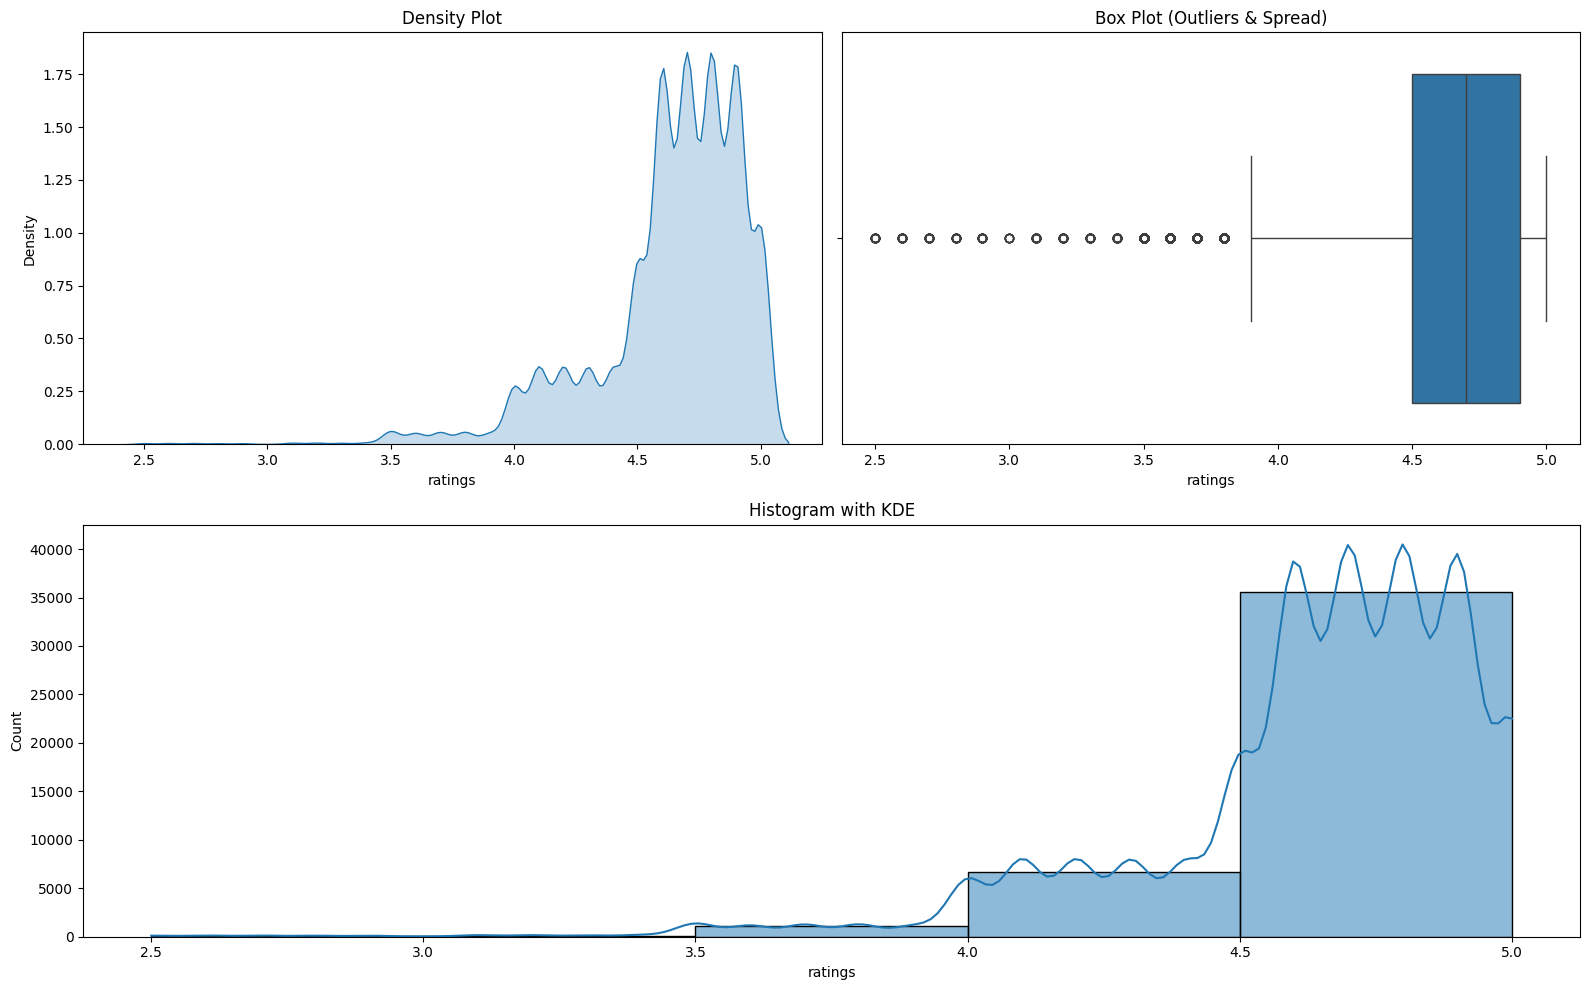

In [44]:
# numerical analysis
numerical_analysis(df_final,"ratings",bins=5)

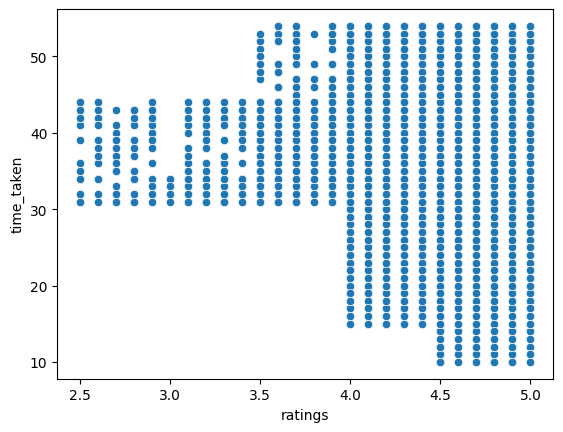

In [45]:
# does ratings affect delivery time
sns.scatterplot(data=df_final, x='ratings', y='time_taken')
plt.show()

### 🚴 Rider Ratings – Observations

- <span style="color:#60a5fa;">Riders with <b>higher ratings</b> tend to receive <b>more delivery orders</b>, indicating a preference or prioritization mechanism.</span>

- <span style="color:#34d399;">Higher rider ratings translate into <b>greater work allocation</b> and consequently <b>more income opportunities</b>.</span>

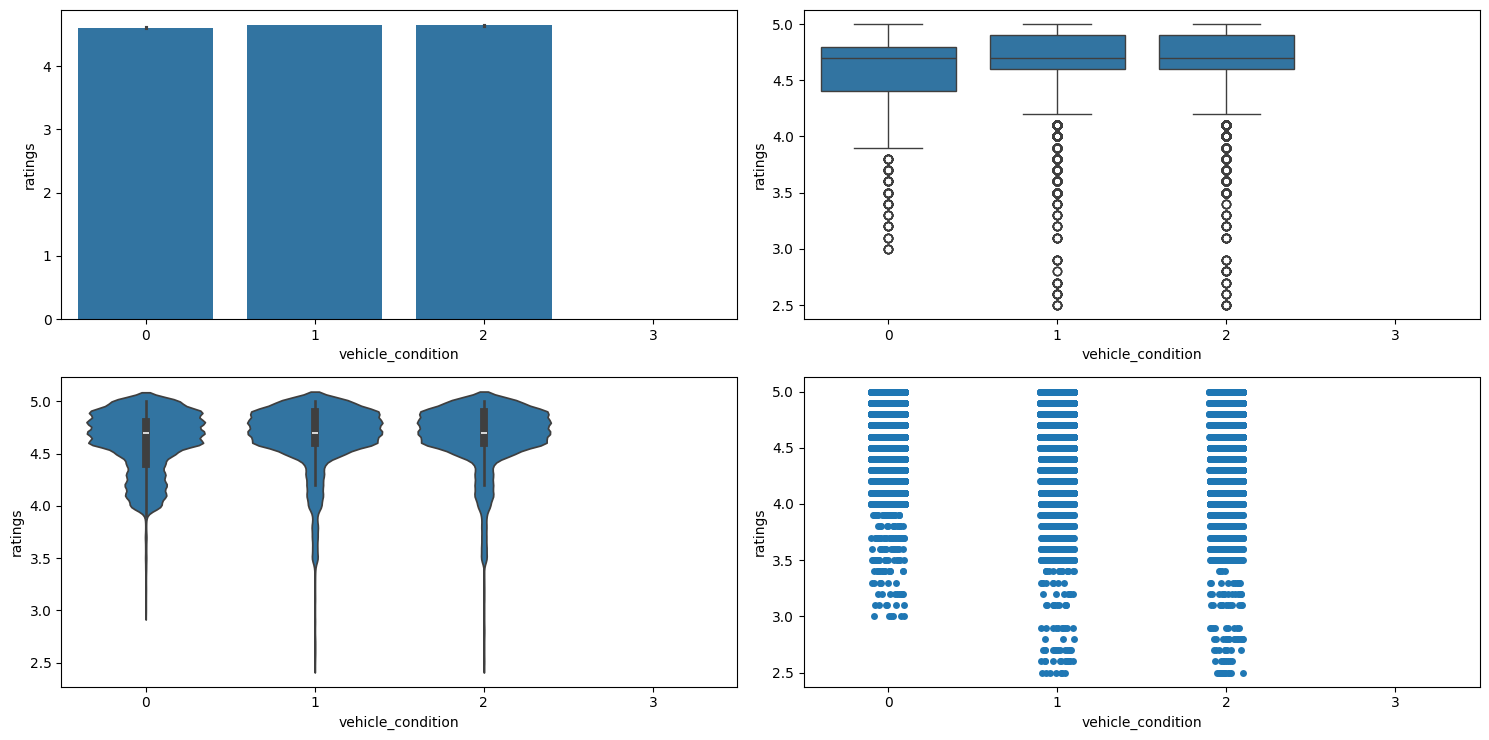

In [46]:
# does ratings get affected by vehicle type
numerical_categorical_analysis(df_final, 'vehicle_condition', 'ratings')

### 🚲 Vehicle Condition vs Rider Ratings – Observations

- <span style="color:#f87171;">As the <b>vehicle condition worsens</b>, rider ratings tend to <b>decrease</b>, indicating a strong negative perception from customers.</span>

- <span style="color:#fb923c;"><b>Vehicle condition category 3</b> contains <b>no valid rating data</b> (NaN values), suggesting missing feedback rather than neutral performance.</span>

- <span style="color:#facc15;">This pattern implies that customers may <b>avoid giving ratings altogether</b>—even low ratings such as <b>1</b>—when the vehicle condition is poor.</span>

In [47]:
(
    df_final[["ratings","vehicle_condition"]]
    .loc[df_final["vehicle_condition"]==3,"ratings"]
    .value_counts(dropna=False)
)

ratings
NaN    429
Name: count, dtype: int64

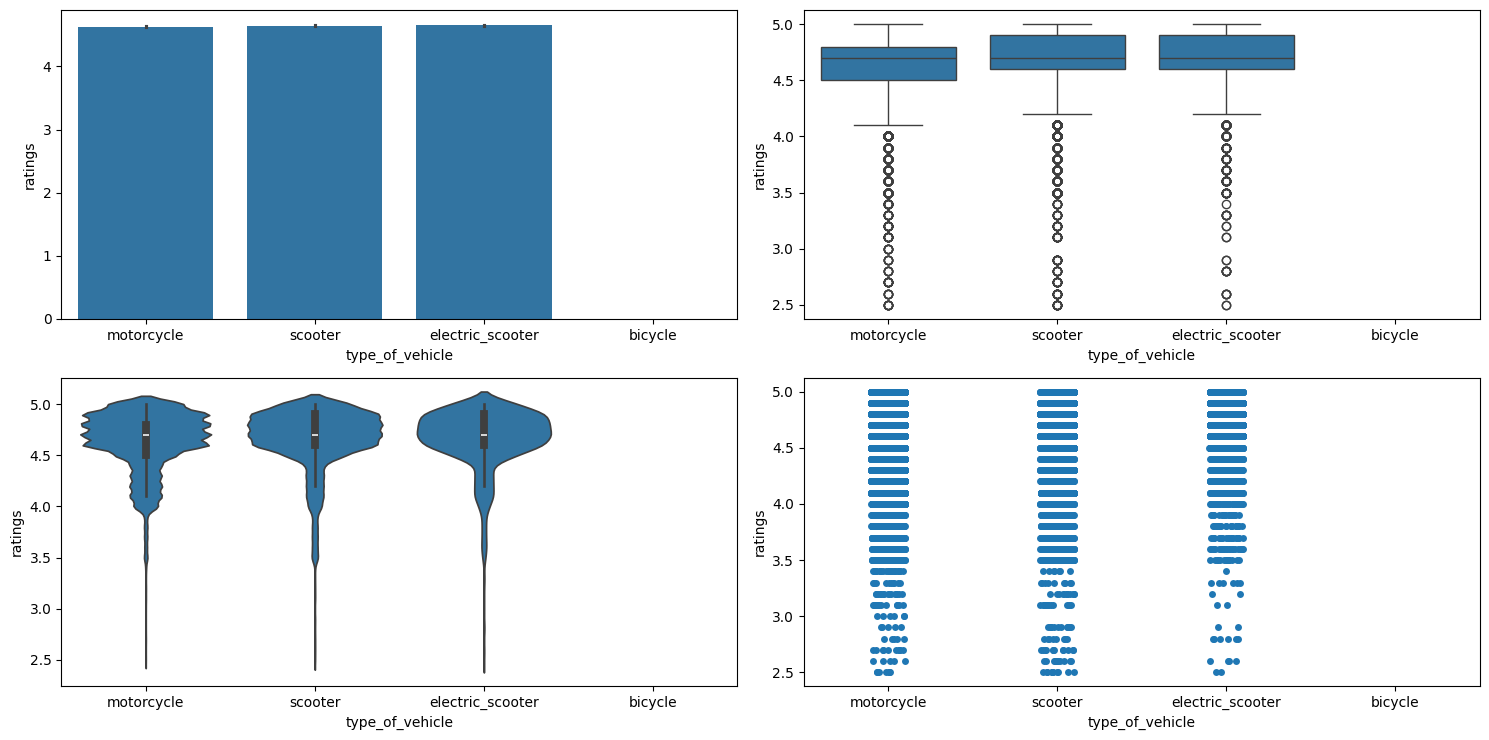

In [48]:
# does type of vehicle affects ratings
numerical_categorical_analysis(df_final, 'type_of_vehicle', 'ratings')

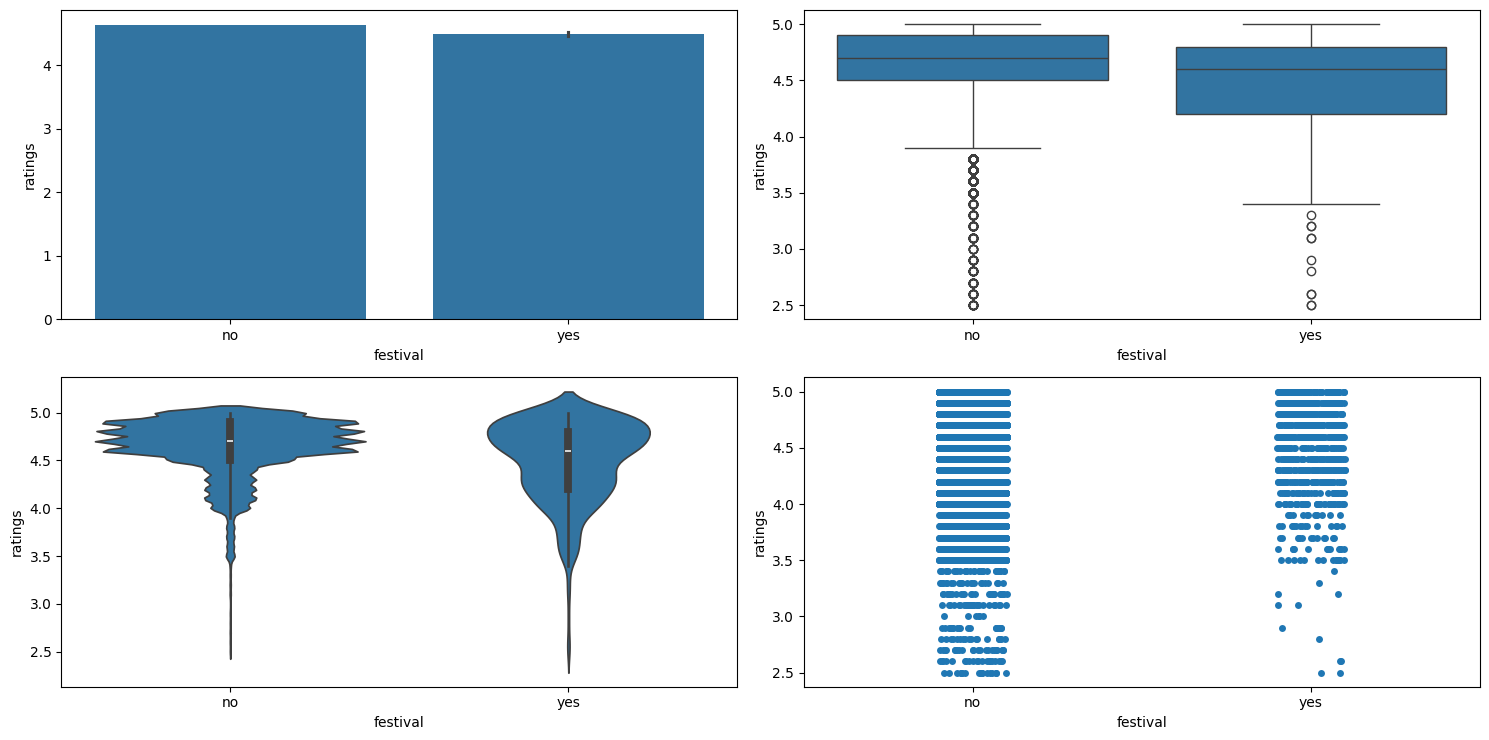

In [49]:
# festvals and rider ratings
numerical_categorical_analysis(df_final, 'festival', 'ratings')
     

## Location Based Features

In [50]:
df_final.columns[3:7].tolist() + ['city_name']

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'city_name']

In [51]:
# location subset
location_subset = df_final.loc[:,df_final.columns[3:7].tolist() + ["city_name"]]
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45497,26.902328,75.794257,26.912328,75.804257,JAP
45498,NaN,NaN,NaN,NaN,AGR
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [52]:
location_subset.dtypes

restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
city_name                object
dtype: object

In [53]:
#Drop missing values
location_subset.dropna(inplace=True)
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45496,23.371292,85.327872,23.481292,85.437872,RANCHI
45497,26.902328,75.794257,26.912328,75.804257,JAP
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [54]:
delivery_df = pd.DataFrame({
    "latitude": location_subset['delivery_latitude'],
    "longitude": location_subset['delivery_longitude'],
    "city_name": location_subset['city_name']
})

In [55]:
delivery_df.head()

,latitude,longitude,city_name
0,22.765049,75.912471,INDO
1,13.043041,77.813237,BANG
2,12.924264,77.688400,BANG
3,11.053669,77.026494,COIMB
4,13.012793,80.289982,CHEN


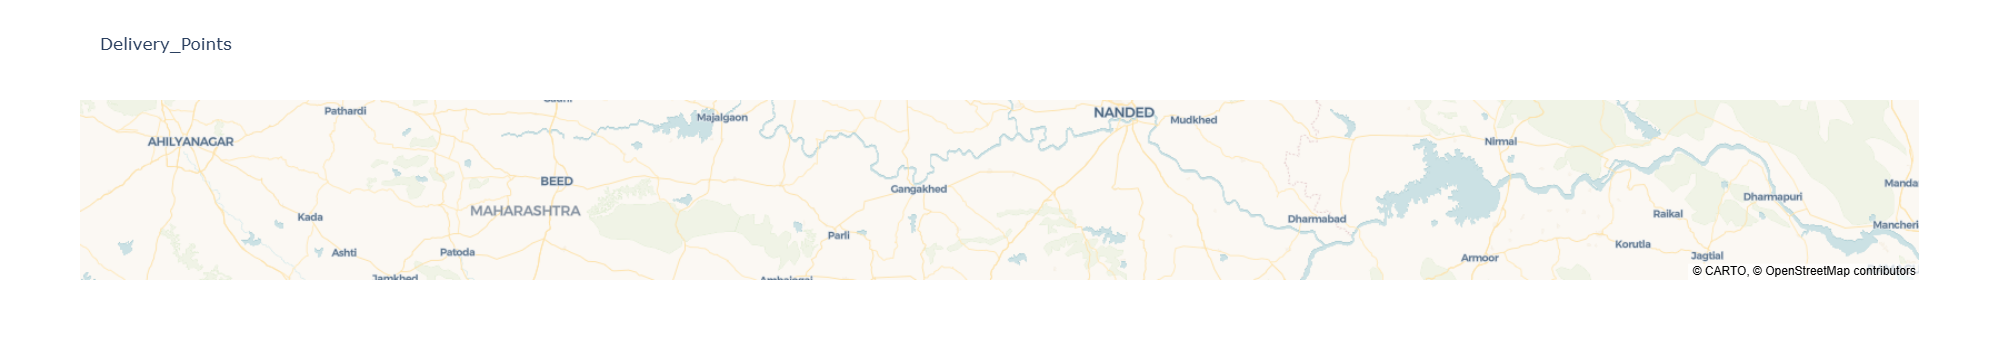

In [56]:
# Create a map using Plotly's scatter_mapbox
fig = px.scatter_map(delivery_df,lat='latitude',lon='longitude',title='Delivery_Points',hover_name='city_name')
fig.update_layout(mapbox_style='carto-positron',mapbox_center={"lat":20.5937,"lon":78.9629},mapbox_zoom = 3)
fig.show()

## Order Date

In [57]:
df_final.filter(like='order')

,order_date,order_time,order_picked_time,type_of_order,order_day,order_month,order_day_of_week,order_time_hour,order_time_of_day
0,2022-03-19,2026-02-24 11:30:00,2026-02-24 11:45:00,snack,19,3,saturday,11.0,morning
1,2022-03-25,2026-02-24 19:45:00,2026-02-24 19:50:00,snack,25,3,friday,19.0,evening
2,2022-03-19,2026-02-24 08:30:00,2026-02-24 08:45:00,drinks,19,3,saturday,8.0,morning
3,2022-04-05,2026-02-24 18:00:00,2026-02-24 18:10:00,buffet,5,4,tuesday,18.0,evening
4,2022-03-26,2026-02-24 13:30:00,2026-02-24 13:45:00,snack,26,3,saturday,13.0,afternoon
...,...,...,...,...,...,...,...,...,...
45497,2022-03-24,2026-02-24 11:35:00,2026-02-24 11:45:00,meal,24,3,thursday,11.0,morning
45498,2022-02-16,2026-02-24 19:55:00,2026-02-24 20:10:00,buffet,16,2,wednesday,19.0,evening
45499,2022-03-11,2026-02-24 23:50:00,2026-02-24 00:05:00,drinks,11,3,friday,23.0,night
45500,2022-03-07,2026-02-24 13:35:00,2026-02-24 13:40:00,snack,7,3,monday,13.0,afternoon


In [58]:
#Order date columns
order_date_subset = df_final.loc[:,["order_date","order_day","order_month","order_day_of_week","is_weekend","festival"]]
order_date_subset.head()

,order_date,order_day,order_month,order_day_of_week,is_weekend,festival
0,2022-03-19,19,3,saturday,1,no
1,2022-03-25,25,3,friday,0,no
2,2022-03-19,19,3,saturday,1,no
3,2022-04-05,5,4,tuesday,0,no
4,2022-03-26,26,3,saturday,1,no


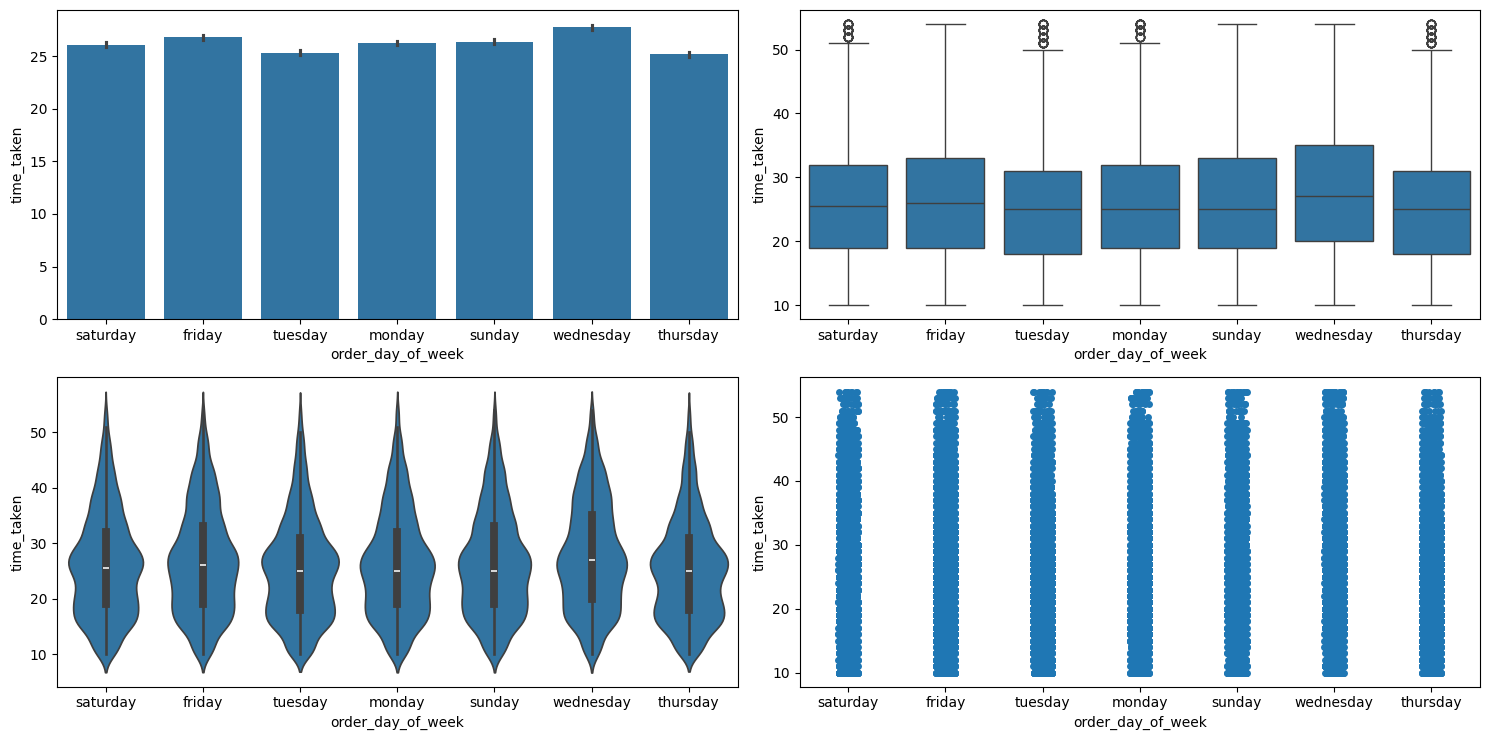

In [59]:
# analysis between day of week and target
numerical_categorical_analysis(df_final,"order_day_of_week","time_taken")

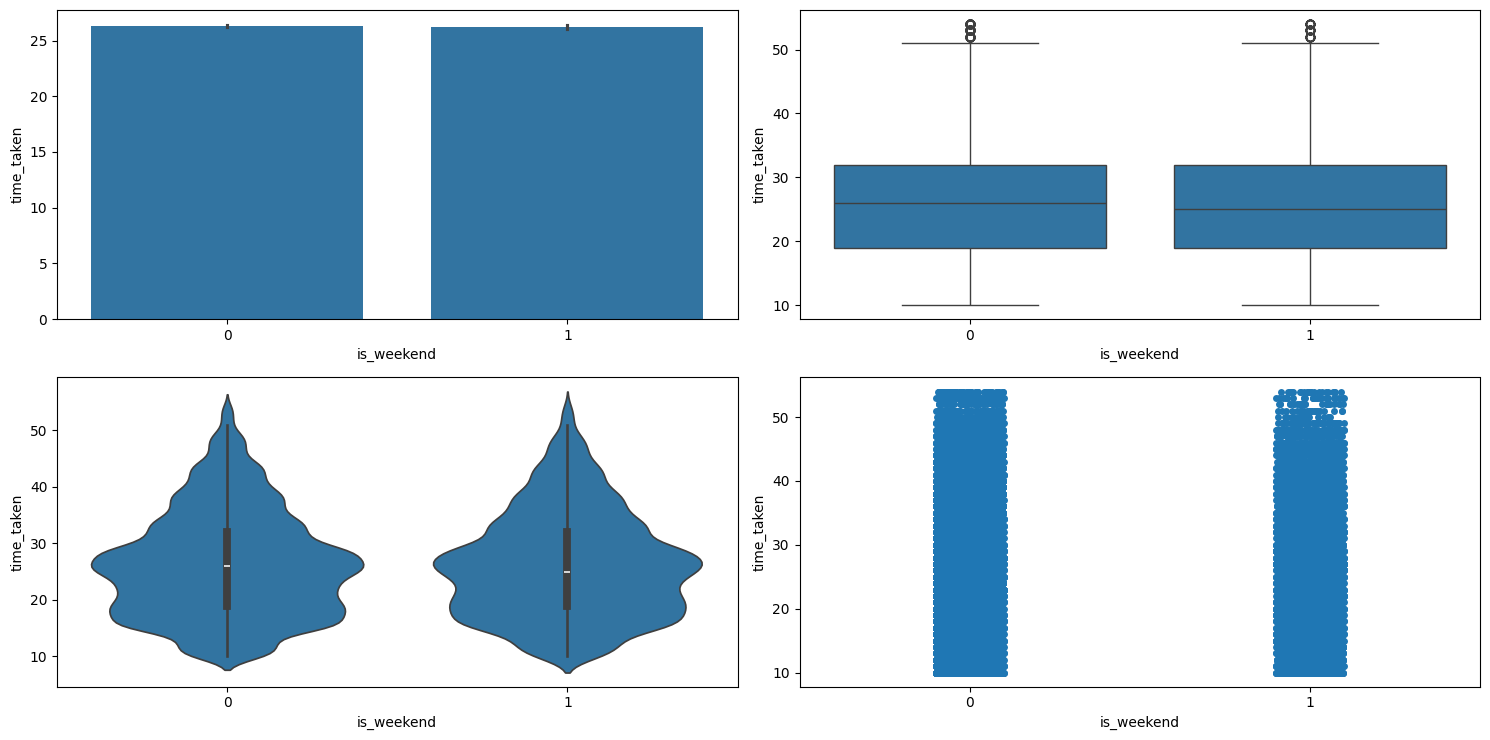

In [60]:
# does having a weekend affects target
numerical_categorical_analysis(df_final,"is_weekend","time_taken")

In [61]:
# do weekends have an impact on traffic
chi_square_test(df_final,"is_weekend","traffic")

Chi-Square Statistic : 1.4899
Degrees of Freedom  : 3
P-value             : 0.684596
✅ Fail to Reject the Null Hypothesis: There is no significant association between 'is_weekend' and 'traffic'.


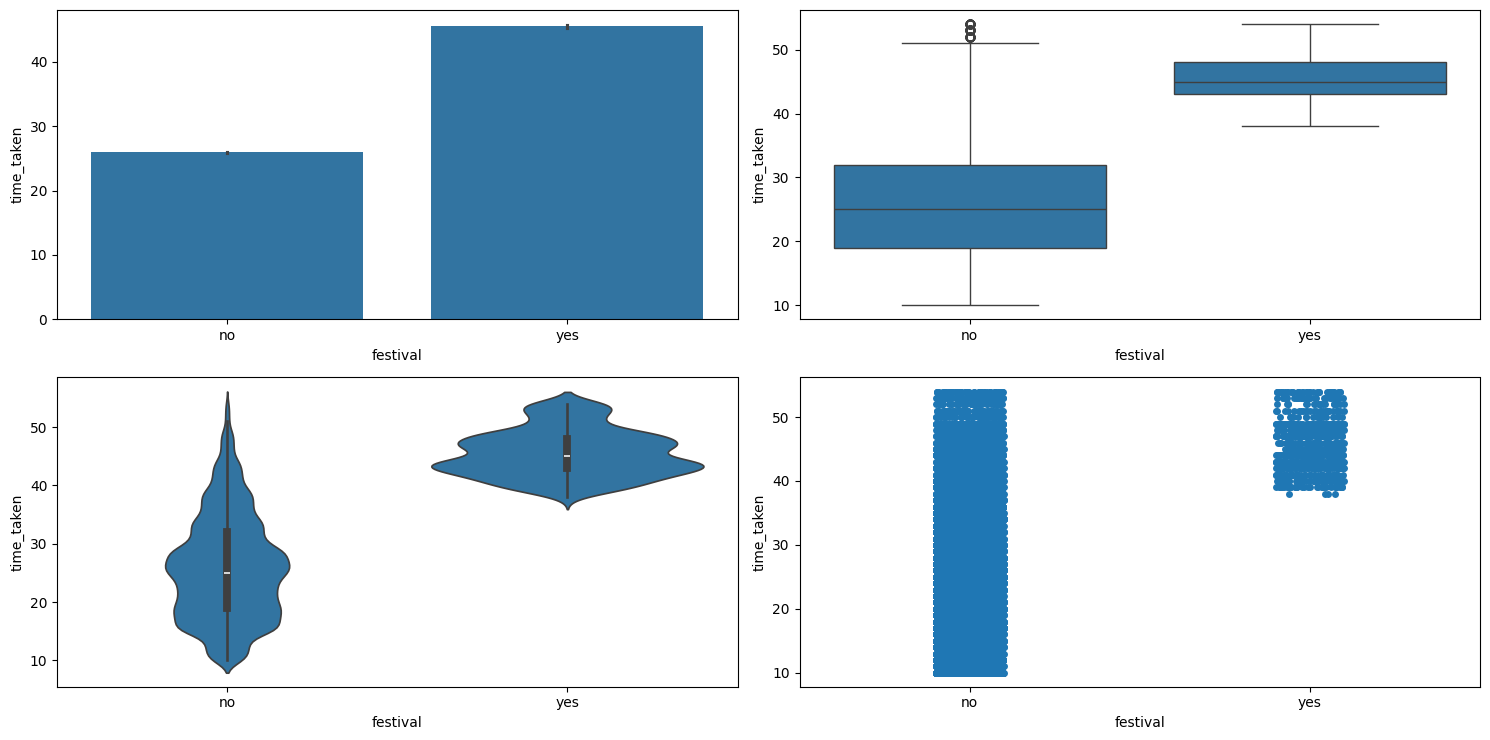

In [62]:
# festivals and target analysis
numerical_categorical_analysis(df_final, "festival", "time_taken")

**Observations**:

- The avg time it takes for delivery varies when there is a festival.
- The range of delivery time is shorter when there is a festival with lesser variation, which means on a festival delivery times usually takes longer

In [63]:
# do festival affect traffic
chi_square_test(df_final,"festival","traffic")

Chi-Square Statistic : 710.4774
Degrees of Freedom  : 3
P-value             : 0.000000
❌ Reject the Null Hypothesis: There is a significant association between 'festival' and 'traffic'.


In [64]:
df_final.pivot_table(index='traffic',columns='festival',values='time_taken',aggfunc='mean')

festival,no,yes
traffic,,
high,27.010373,45.826087
jam,30.538039,46.093651
low,21.284332,42.020000
medium,26.550288,43.715385


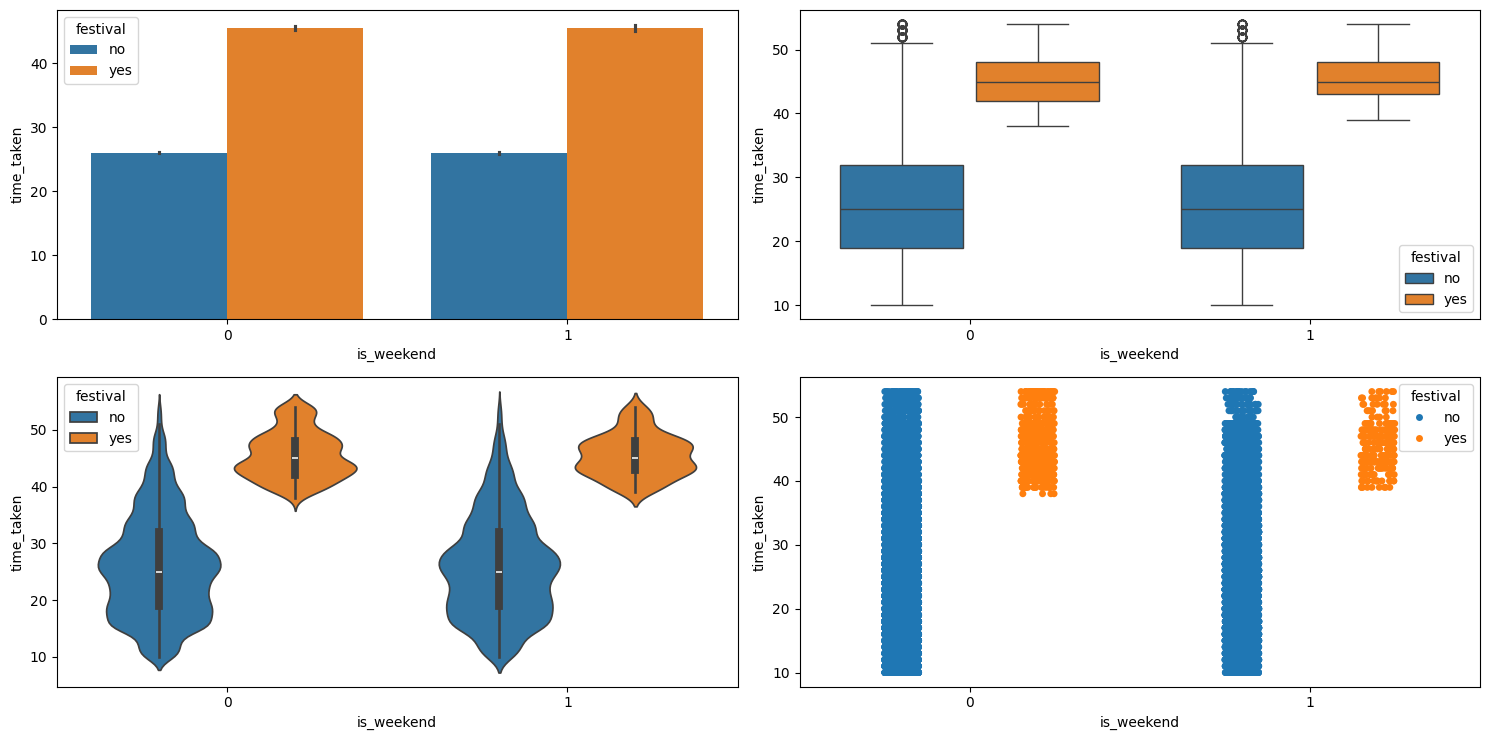

In [65]:
# does a weekend and a festival combined have an effect on delivery times
multivariate_analysis(df_final,"time_taken","is_weekend","festival")

## Order Time

In [66]:
# time related columns
time_subset = df_final.loc[:,["order_time_hour","order_time_of_day","pickup_time_minutes"]]
time_subset

,order_time_hour,order_time_of_day,pickup_time_minutes
0,11.0,morning,15.0
1,19.0,evening,5.0
2,8.0,morning,15.0
3,18.0,evening,10.0
4,13.0,afternoon,15.0
...,...,...,...
45497,11.0,morning,10.0
45498,19.0,evening,15.0
45499,23.0,night,15.0
45500,13.0,afternoon,5.0


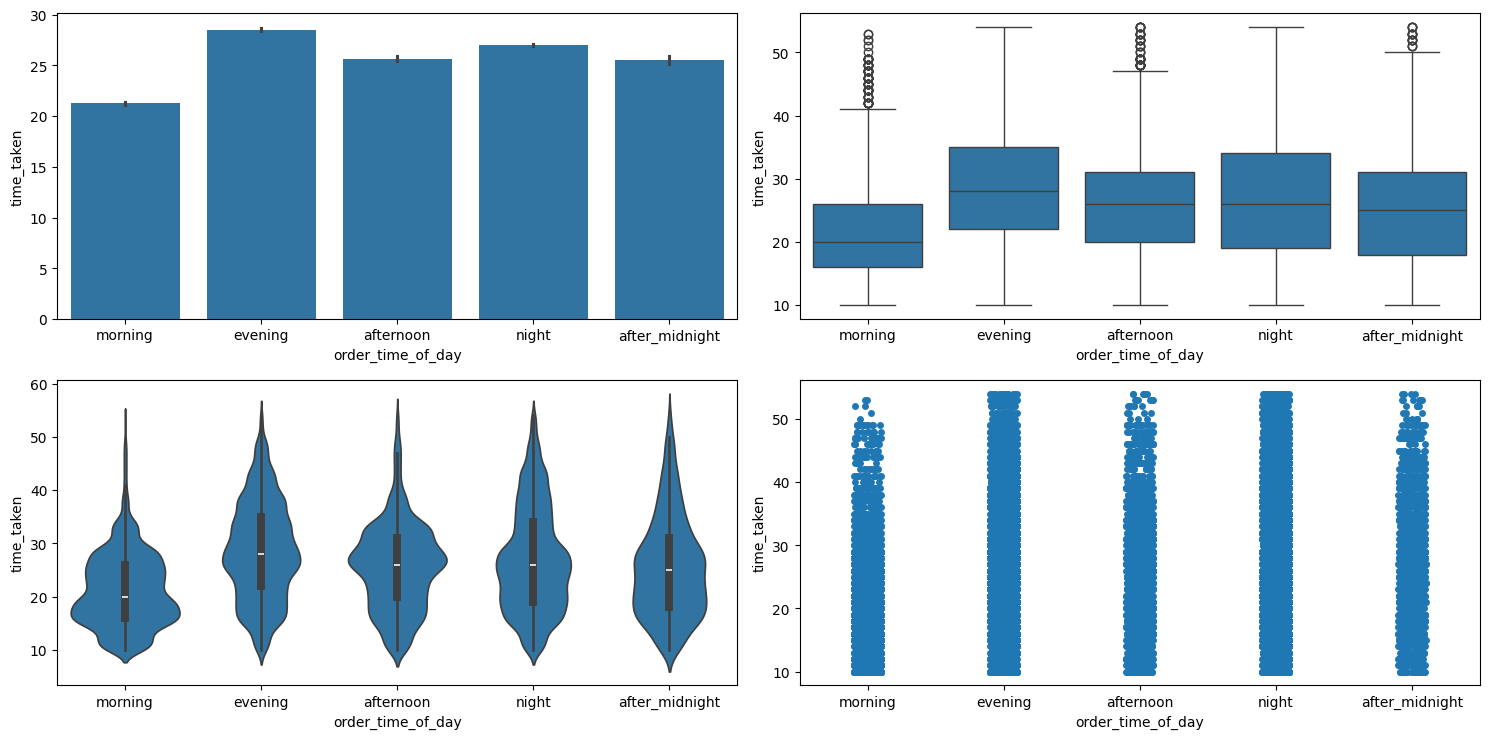

In [67]:
# does time of day affects delivery times
numerical_categorical_analysis(df_final, "order_time_of_day", "time_taken")

In [68]:
# relationship between time of day and traffic
chi_square_test(df_final,"order_time_of_day","traffic")

Chi-Square Statistic : 51100.6095
Degrees of Freedom  : 12
P-value             : 0.000000
❌ Reject the Null Hypothesis: There is a significant association between 'order_time_of_day' and 'traffic'.


In [69]:
# anova test
anova_test(df_final, "time_taken", "order_time_of_day")

F-Statistic : 834.7126
P-value     : 0.000000
❌ Reject the Null Hypothesis: The mean of 'time_taken' differs significantly across 'order_time_of_day' categories.


In [70]:
# Top 5 times(hrs) of the day in which customers  order the most
df_final["order_time_hour"].value_counts().head(5)

order_time_hour
21.0    4686
19.0    4595
22.0    4576
20.0    4539
23.0    4511
Name: count, dtype: int64

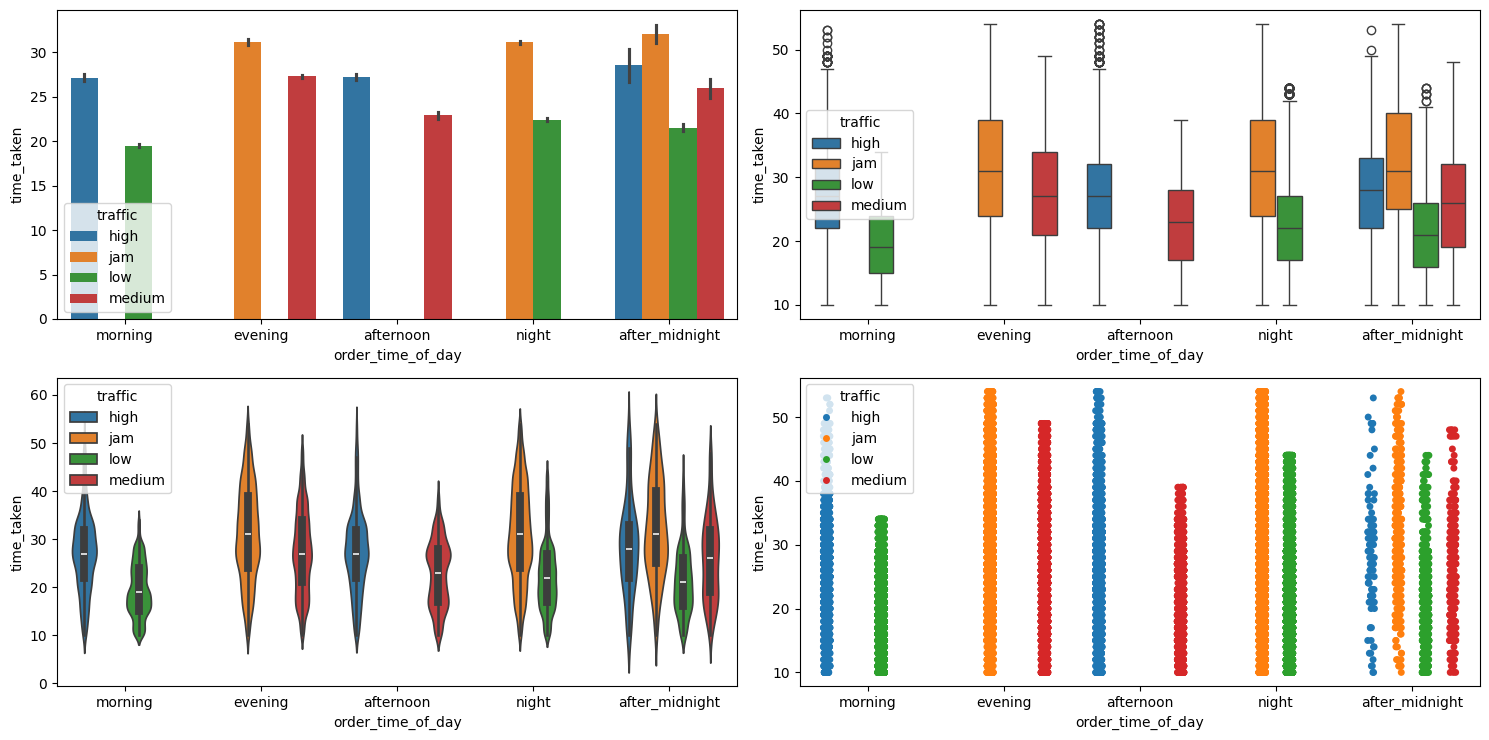

In [71]:
# can delivery time be affected by both time of day and traffic
multivariate_analysis(df_final, "time_taken", "order_time_of_day", "traffic")

,Count,Percentage
order_time_hour,,
21.0,4686,10.68%
19.0,4595,10.48%
22.0,4576,10.43%
20.0,4539,10.35%
23.0,4511,10.28%
18.0,4480,10.21%
17.0,4278,9.75%
10.0,1991,4.54%
11.0,1962,4.47%


**************************************************
The unique categories in order_time_hour column are [11.0, 19.0, 8.0, 18.0, 13.0, 21.0, 17.0, 20.0, 14.0, 9.0, 22.0, 12.0, 23.0, nan, 10.0, 16.0, 15.0, 0.0]
**************************************************
The number of categories in order_time_hour column are 17


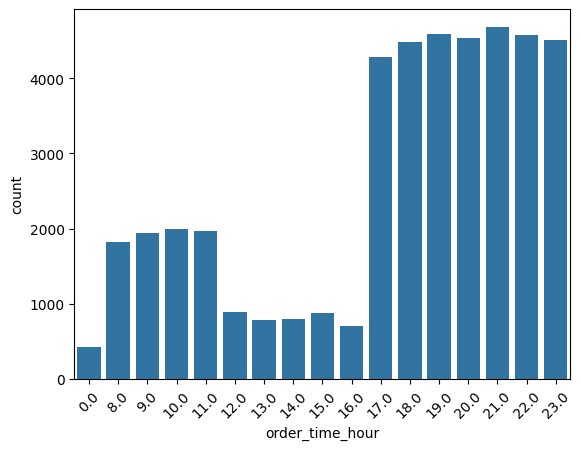

In [72]:
# categorical analysis on order_time_hour
categorical_analysis(df_final, "order_time_hour")

,Count,Percentage
order_time_of_day,,
night,18312,40.24%
evening,13353,29.35%
morning,7718,16.96%
afternoon,4049,8.9%
after_midnight,2070,4.55%


**************************************************
The unique categories in order_time_of_day column are ['morning', 'evening', 'afternoon', 'night', 'after_midnight']
**************************************************
The number of categories in order_time_of_day column are 5


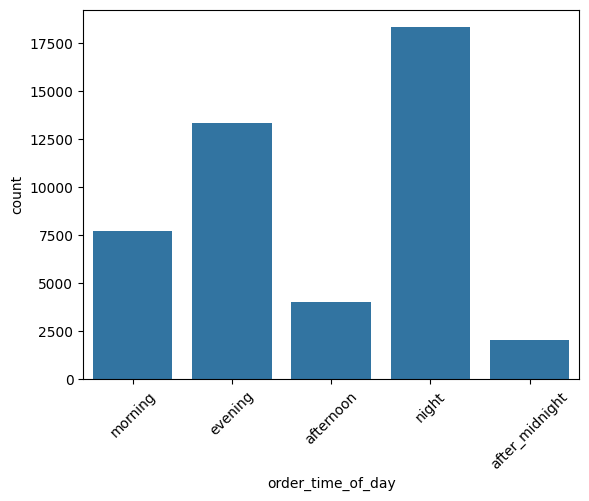

In [73]:
# categorical analysis on time of day
categorical_analysis(df_final, "order_time_of_day")

## Pickup Time

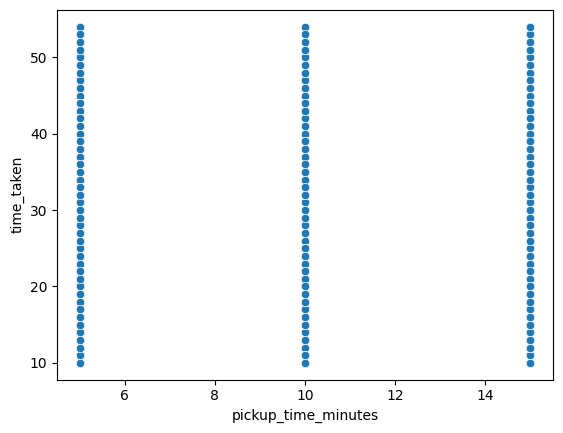

In [74]:
# relationship between pickup time and delivery time
sns.scatterplot(df_final,x="pickup_time_minutes",y="time_taken")
plt.show()

,Count,Percentage
pickup_time_minutes,,
5.0,14703,33.52%
15.0,14610,33.31%
10.0,14549,33.17%


**************************************************
The unique categories in pickup_time_minutes column are [15.0, 5.0, 10.0, nan]
**************************************************
The number of categories in pickup_time_minutes column are 3


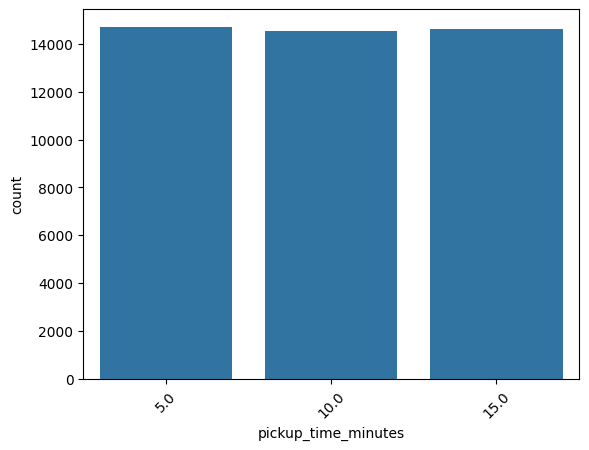

In [75]:
# pickup time categorical analysis
categorical_analysis(df_final, "pickup_time_minutes")

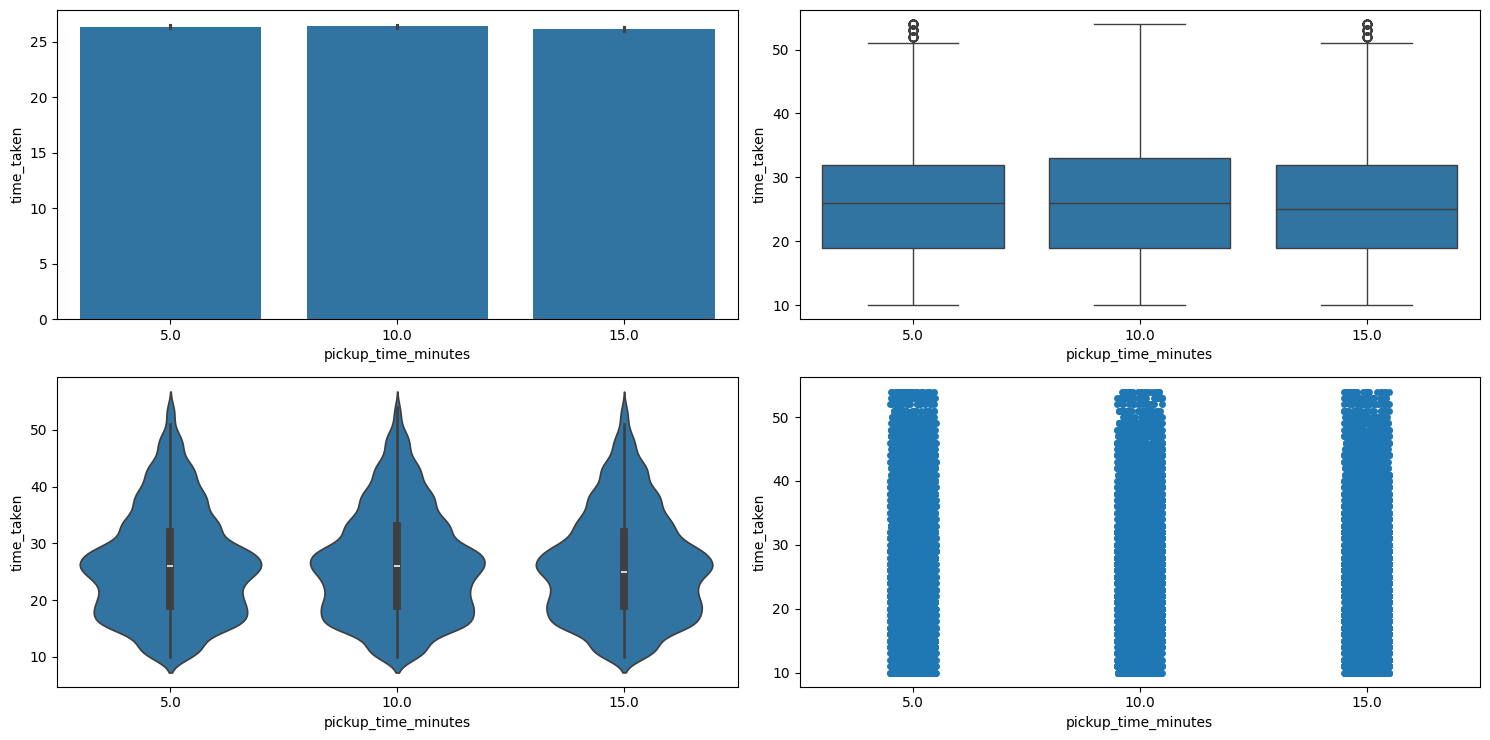

In [76]:
# does pickup time have an effect on delivery time
numerical_categorical_analysis(df_final, "pickup_time_minutes", "time_taken")

In [77]:
# hypothesis testing to prove point
anova_test(df_final, "time_taken", "pickup_time_minutes")

F-Statistic : 2.3095
P-value     : 0.099326
✅ Fail to Reject the Null Hypothesis: There is no significant difference in 'time_taken' across 'pickup_time_minutes' categories.


## Traffic

,Count,Percentage
traffic,,
low,15477,34.4%
jam,14143,31.43%
medium,10947,24.33%
high,4425,9.84%


**************************************************
The unique categories in traffic column are ['high', 'jam', 'low', 'medium', nan]
**************************************************
The number of categories in traffic column are 4


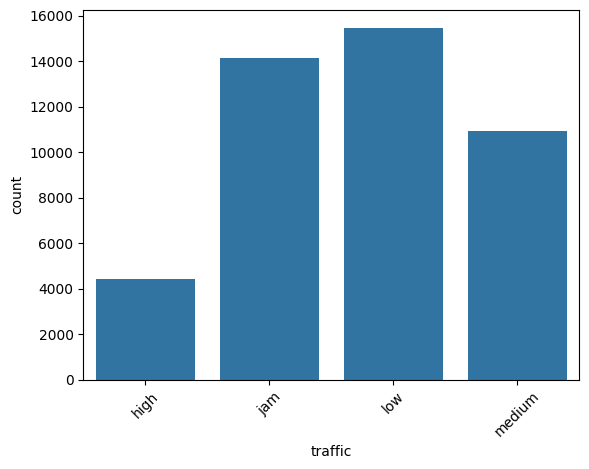

In [78]:
# categorical analysis on traffic
categorical_analysis(df_final, "traffic")

In [79]:
#Does traffic depends on type of city
chi_square_test(df_final,"traffic","city_type")

Chi-Square Statistic : 497.9373
Degrees of Freedom  : 6
P-value             : 0.000000
❌ Reject the Null Hypothesis: There is a significant association between 'traffic' and 'city_type'.


In [80]:
#Does traffic depends on city
chi_square_test(df_final,"traffic","city_name")

Chi-Square Statistic : 62.3959
Degrees of Freedom  : 63
P-value             : 0.497808
✅ Fail to Reject the Null Hypothesis: There is no significant association between 'traffic' and 'city_name'.


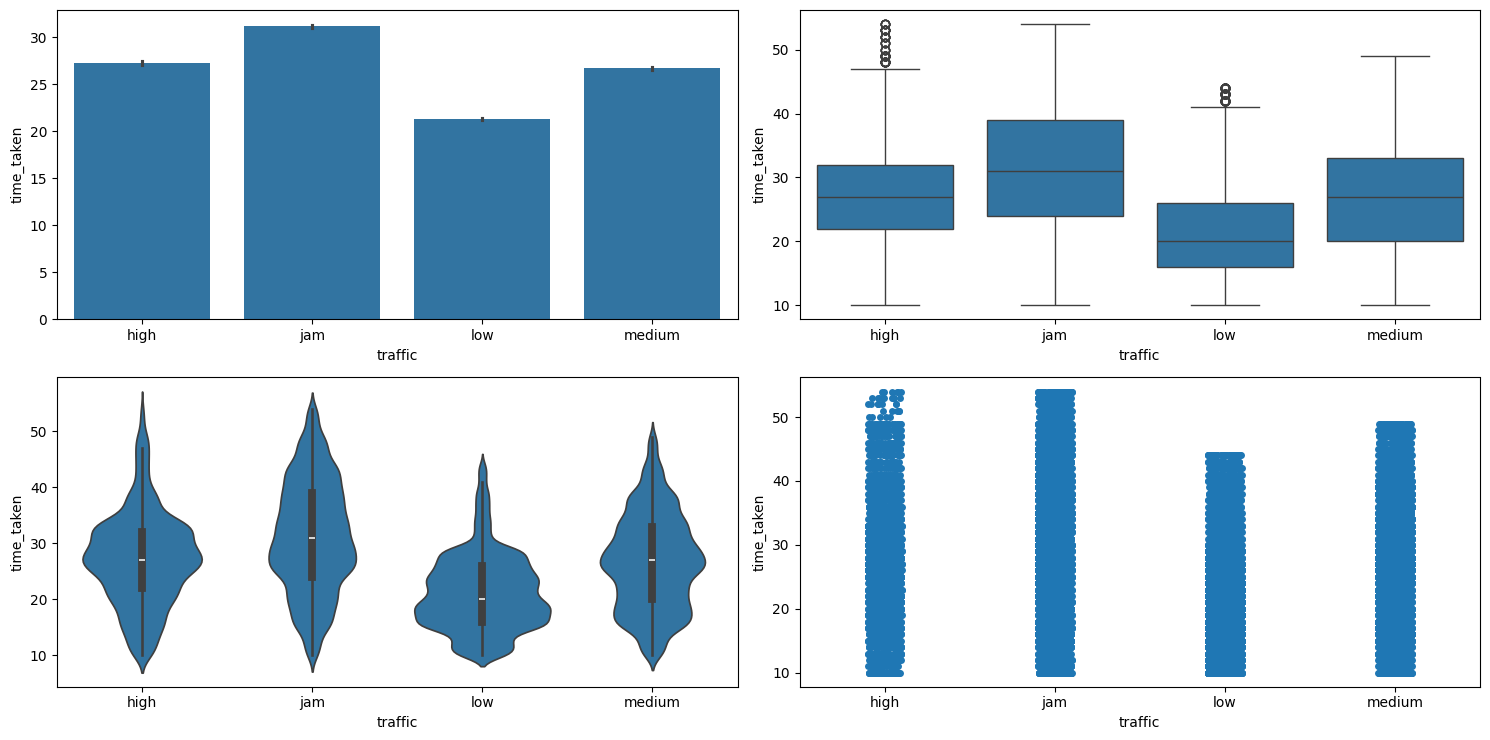

In [81]:
# does traffic affects delivery times
numerical_categorical_analysis(df_final, "traffic", "time_taken")

In [82]:
# hypothesis test on does traffic affects delivery times
anova_test(df_final, "time_taken", "traffic") #There is a significant relationship between time_taken and traffic

F-Statistic : 3411.2667
P-value     : 0.000000
❌ Reject the Null Hypothesis: The mean of 'time_taken' differs significantly across 'traffic' categories.


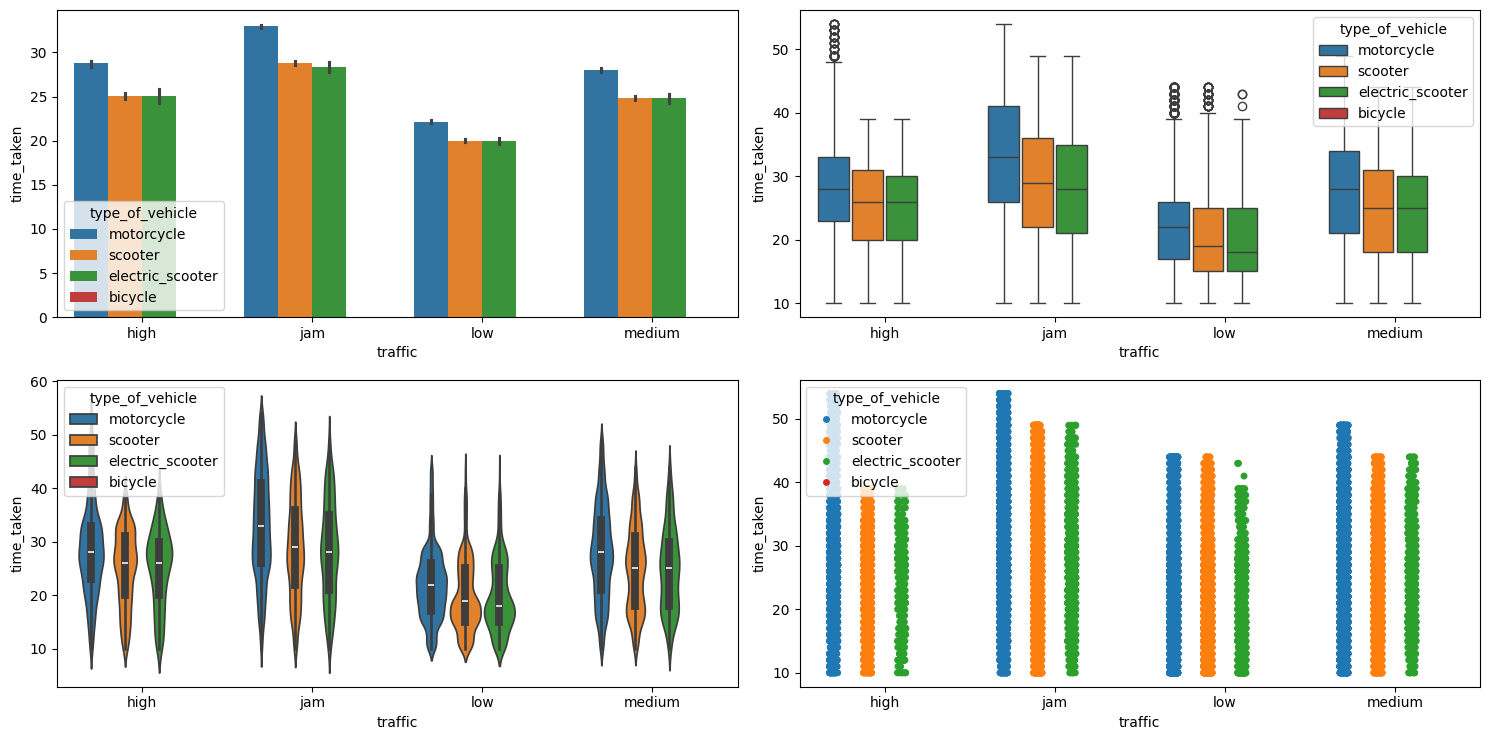

In [83]:
# are some vehicle types more suitable in traffic than others
multivariate_analysis(df_final, "time_taken", "traffic", "type_of_vehicle")
     

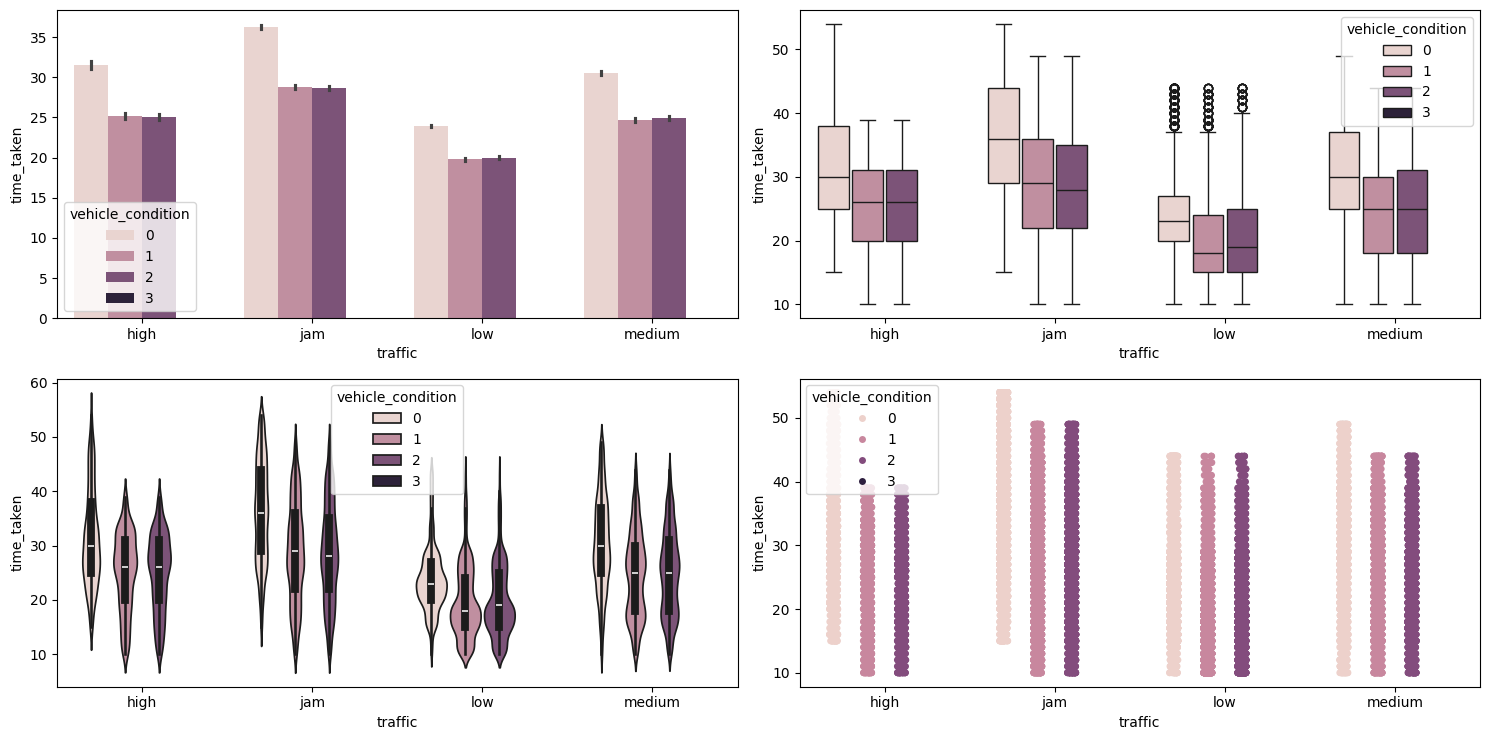

In [84]:
# does vehicle condition in traffic situations affects delivery times
multivariate_analysis(df_final, "time_taken", "traffic", "vehicle_condition")

- Dont make wrong interpretations that good condition vehicles takes longer times on avg

- This simply means that good vehicles are preferred for deliveries during festivals which results in longer delivery times

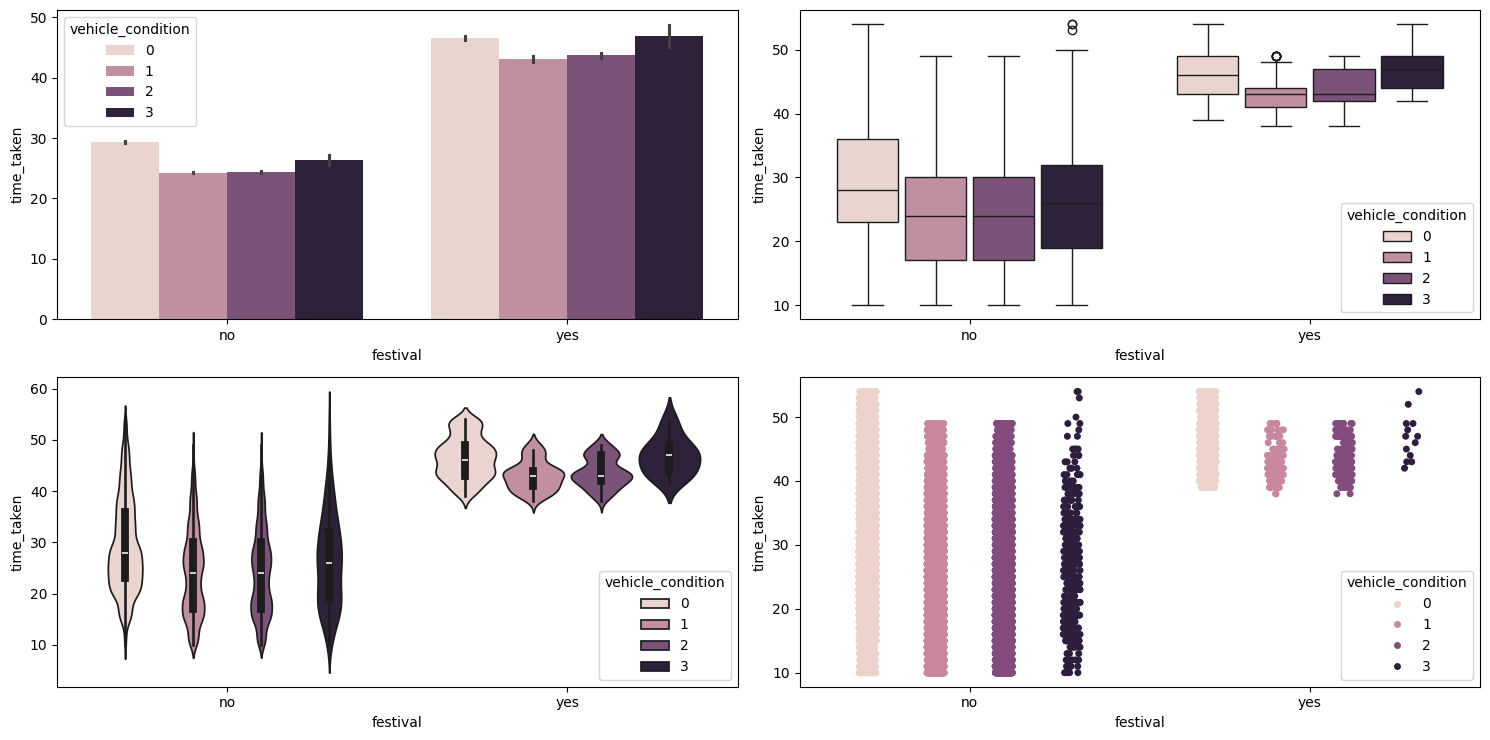

In [85]:
multivariate_analysis(df_final, "time_taken", "festival", "vehicle_condition")

## Multiple Deliveries

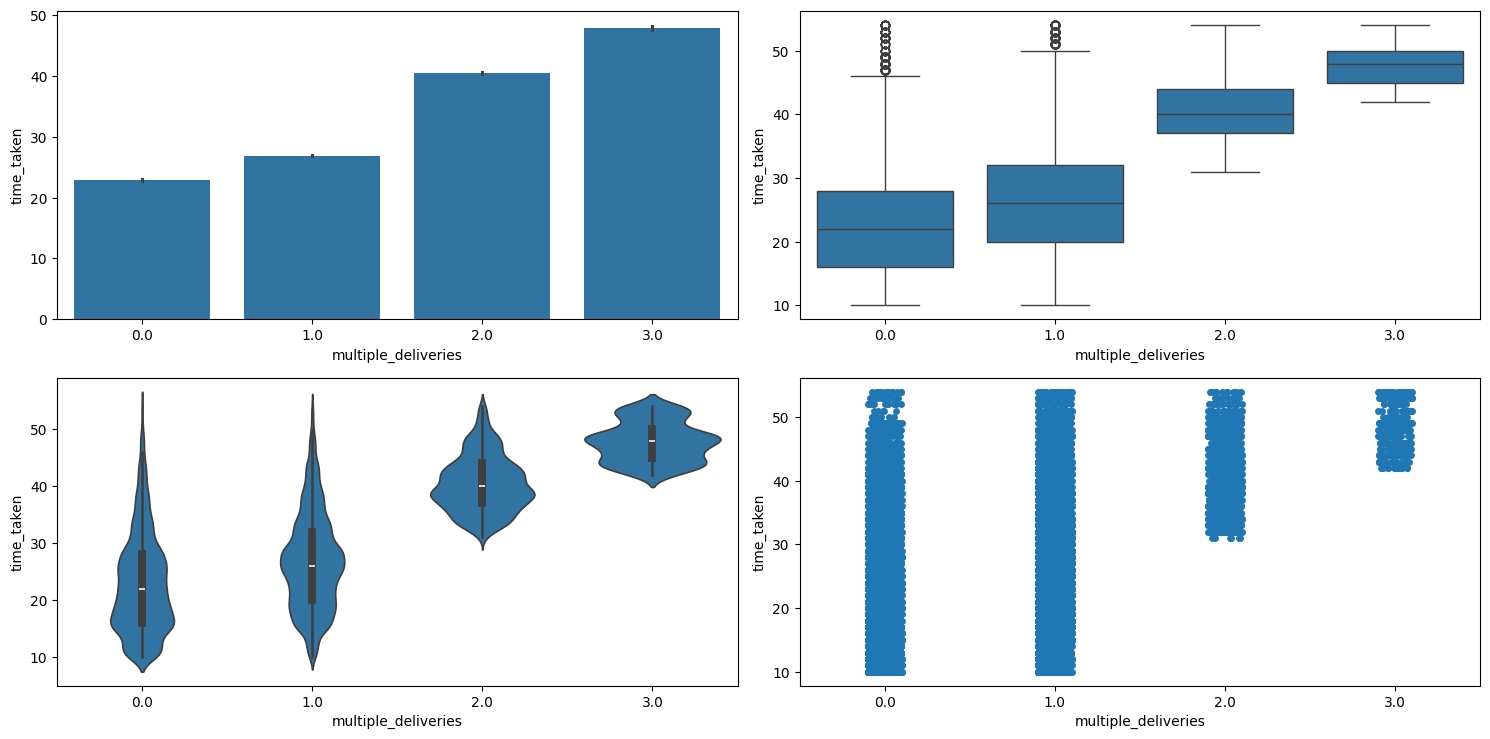

In [86]:
# does multiple delivereis affect delivery times
numerical_categorical_analysis(df_final, "multiple_deliveries", "time_taken")

In [87]:
# hypothesis test ##There is a significant relationship between time_taken and multiple_deliveries
anova_test(df_final, "time_taken", "multiple_deliveries")

F-Statistic : 3438.7922
P-value     : 0.000000
❌ Reject the Null Hypothesis: The mean of 'time_taken' differs significantly across 'multiple_deliveries' categories.


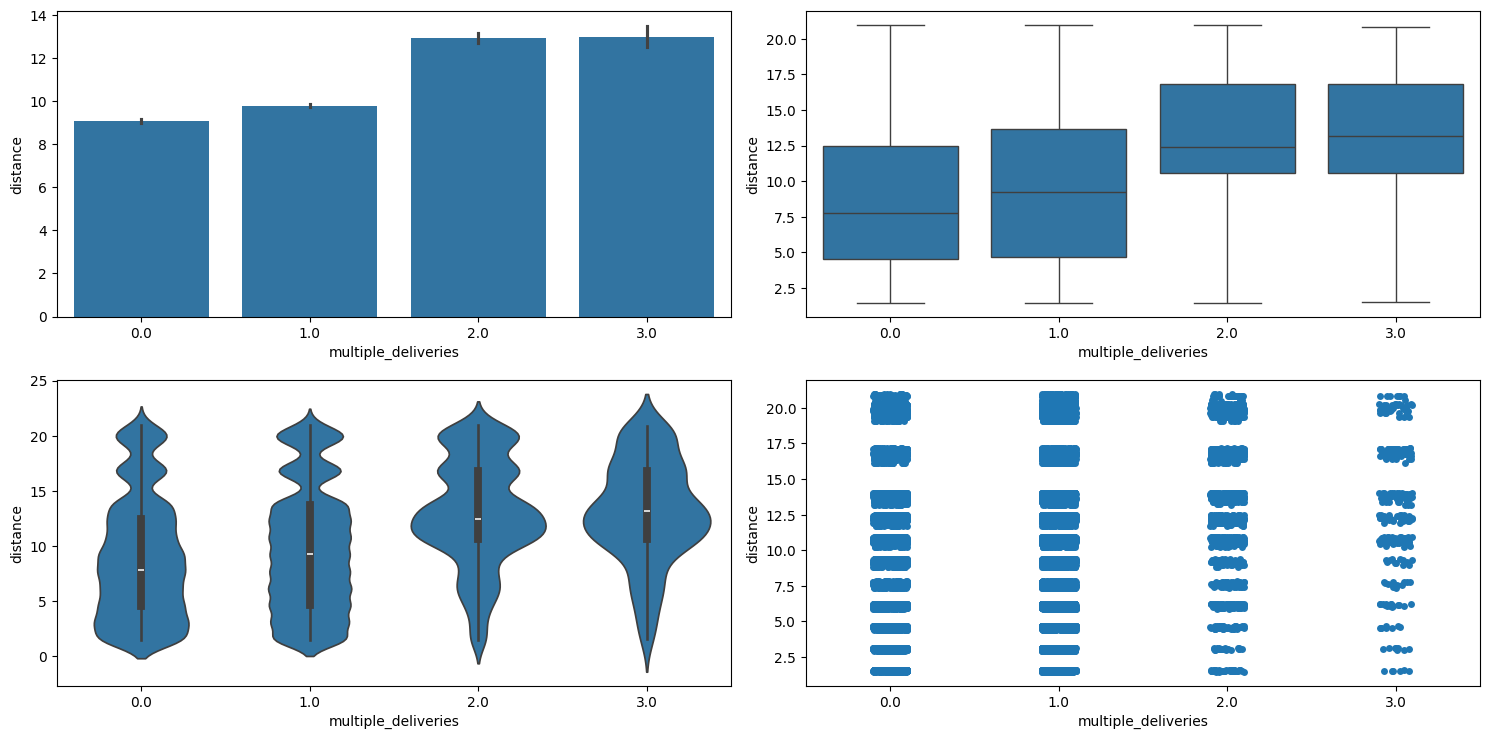

In [88]:
# do multiple deliveries are of longer distances
numerical_categorical_analysis(df_final, "multiple_deliveries", "distance")

## Weather

,Count,Percentage
weather,,
fog,7654,17.02%
stormy,7586,16.87%
cloudy,7536,16.76%
sandstorms,7495,16.66%
windy,7422,16.5%
sunny,7284,16.19%


**************************************************
The unique categories in weather column are ['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan]
**************************************************
The number of categories in weather column are 6


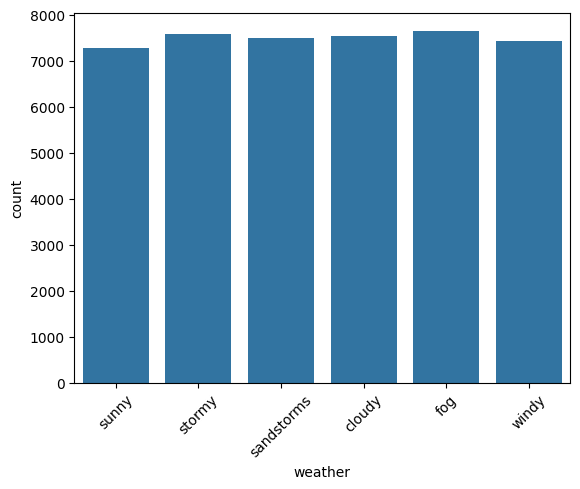

In [89]:
# categorical analysis on type of weather
categorical_analysis(df_final, "weather")

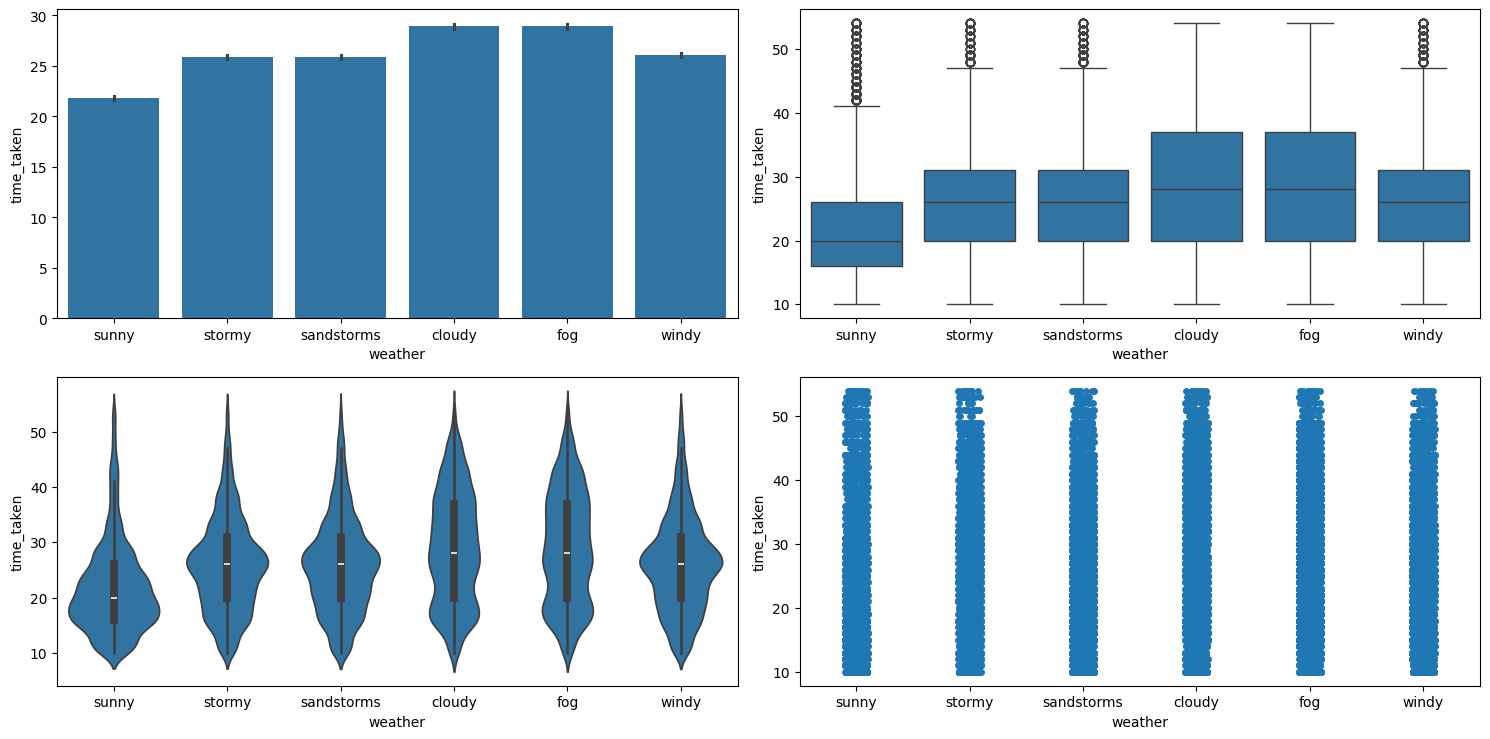

In [90]:
# does weather affect delivery times
numerical_categorical_analysis(df_final, "weather", "time_taken")

In [91]:
# hypothesis test
anova_test(df_final, "time_taken", "weather") #There is a significant relationship between time_taken and weather.

F-Statistic : 608.2196
P-value     : 0.000000
❌ Reject the Null Hypothesis: The mean of 'time_taken' differs significantly across 'weather' categories.


In [92]:
# does the weather affects traffic
chi_square_test(df_final, "weather", "traffic")

Chi-Square Statistic : 14.6130
Degrees of Freedom  : 15
P-value             : 0.479639
✅ Fail to Reject the Null Hypothesis: There is no significant association between 'weather' and 'traffic'.


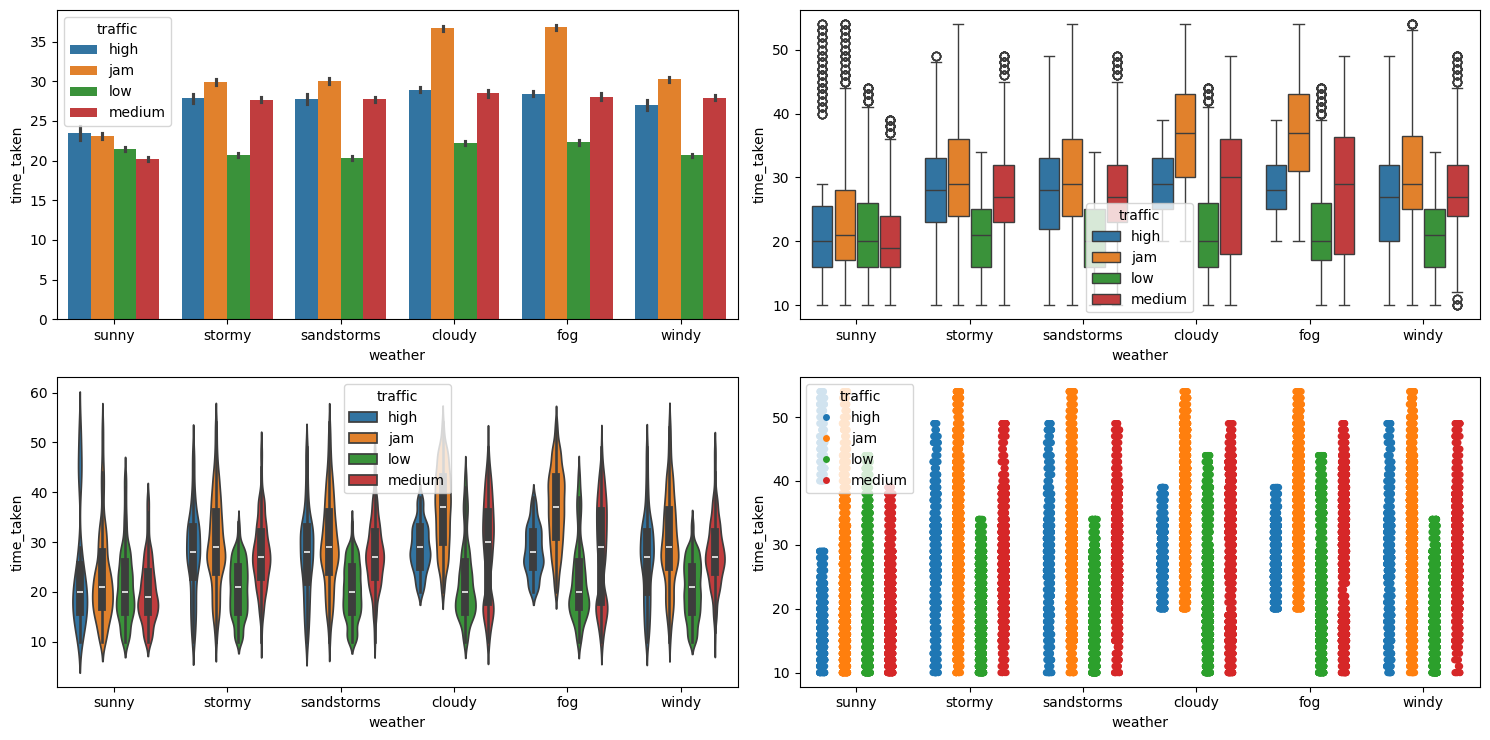

In [93]:
# delivery times based on weather and traffic
multivariate_analysis(df_final, "time_taken", "weather", "traffic")

**Seems like traffic along with other features combined acts as great discriminatory feature**

In [94]:
# pivot table
df_final.pivot_table(index="weather",columns="traffic",values="time_taken",aggfunc="mean")

traffic,high,jam,low,medium
weather,,,,
cloudy,28.940860,36.689655,22.208445,28.483134
fog,28.426546,36.806916,22.303427,28.044816
sandstorms,27.711840,30.018758,20.297049,27.738522
stormy,27.845839,29.850194,20.681734,27.680502
sunny,23.448980,23.082132,21.449293,20.195518
windy,26.972789,30.219056,20.665862,27.888769


## Vehicle - Condition and Type

,Count,Percentage
vehicle_condition,,
2,15034,33.04%
1,15030,33.03%
0,15009,32.99%
3,429,0.94%


**************************************************
The unique categories in vehicle_condition column are [2, 0, 1, 3]
**************************************************
The number of categories in vehicle_condition column are 4


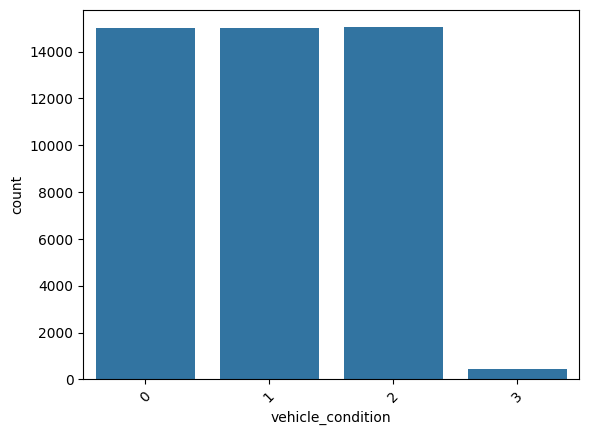

In [95]:
# categorical analysis on vehicle condition
categorical_analysis(df_final, "vehicle_condition")

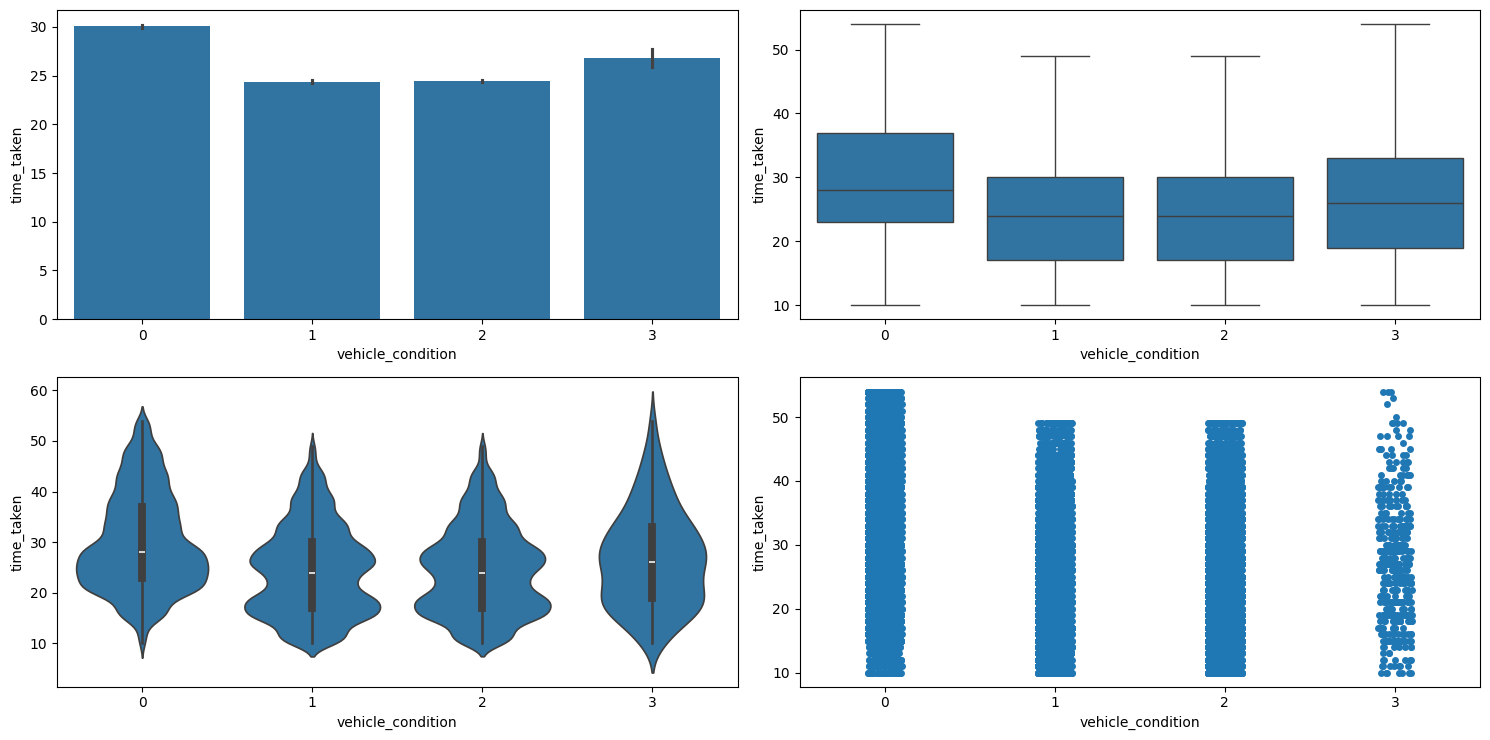

In [96]:
# does vehicle condition affect delivery times
numerical_categorical_analysis(df_final, "vehicle_condition", "time_taken")

### 🚲 Vehicle Condition vs Delivery Time – Observations

- <span style="color:#60a5fa;">Vehicle condition <b>0</b> has the highest average delivery time (around 30 minutes), indicating comparatively slower deliveries.</span>

- <span style="color:#34d399;">Vehicle conditions <b>1 and 2</b> show lower average delivery times (around 24–25 minutes), suggesting better operational efficiency.</span>

- <span style="color:#facc15;">Vehicle condition <b>3</b> shows slightly higher variability and moderate delivery time, but the sample size is very small, so interpretation should be cautious.</span>

- <span style="color:#f87171;">The spread of delivery times is wider for condition <b>0</b>, indicating inconsistency and possible performance issues.</span>

- <span style="color:#a78bfa;">Overall trend suggests that <b>better vehicle condition is associated with faster and more consistent delivery times</b>.</span>

In [97]:
#Anova test
anova_test(df_final,"time_taken","vehicle_condition") #There is a significant relationship between time_taken and vehicle_condition.

F-Statistic : 1323.2530
P-value     : 0.000000
❌ Reject the Null Hypothesis: The mean of 'time_taken' differs significantly across 'vehicle_condition' categories.


,Count,Percentage
type_of_vehicle,,
motorcycle,26427,58.08%
scooter,15244,33.5%
electric_scooter,3778,8.3%
bicycle,53,0.12%


**************************************************
The unique categories in type_of_vehicle column are ['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
**************************************************
The number of categories in type_of_vehicle column are 4


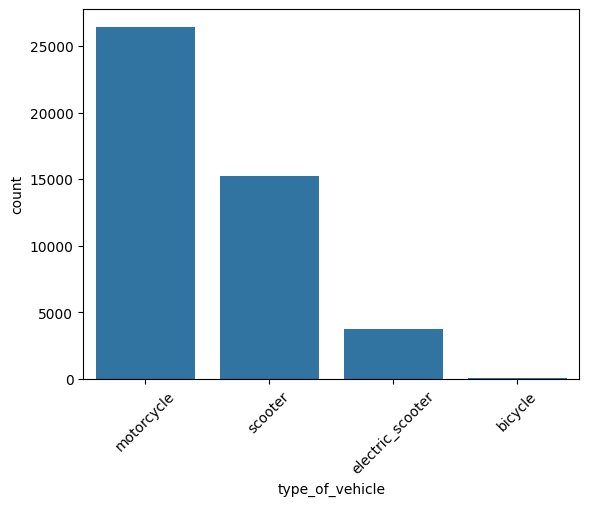

In [98]:
# analysis on vehicle type
categorical_analysis(df_final, "type_of_vehicle")

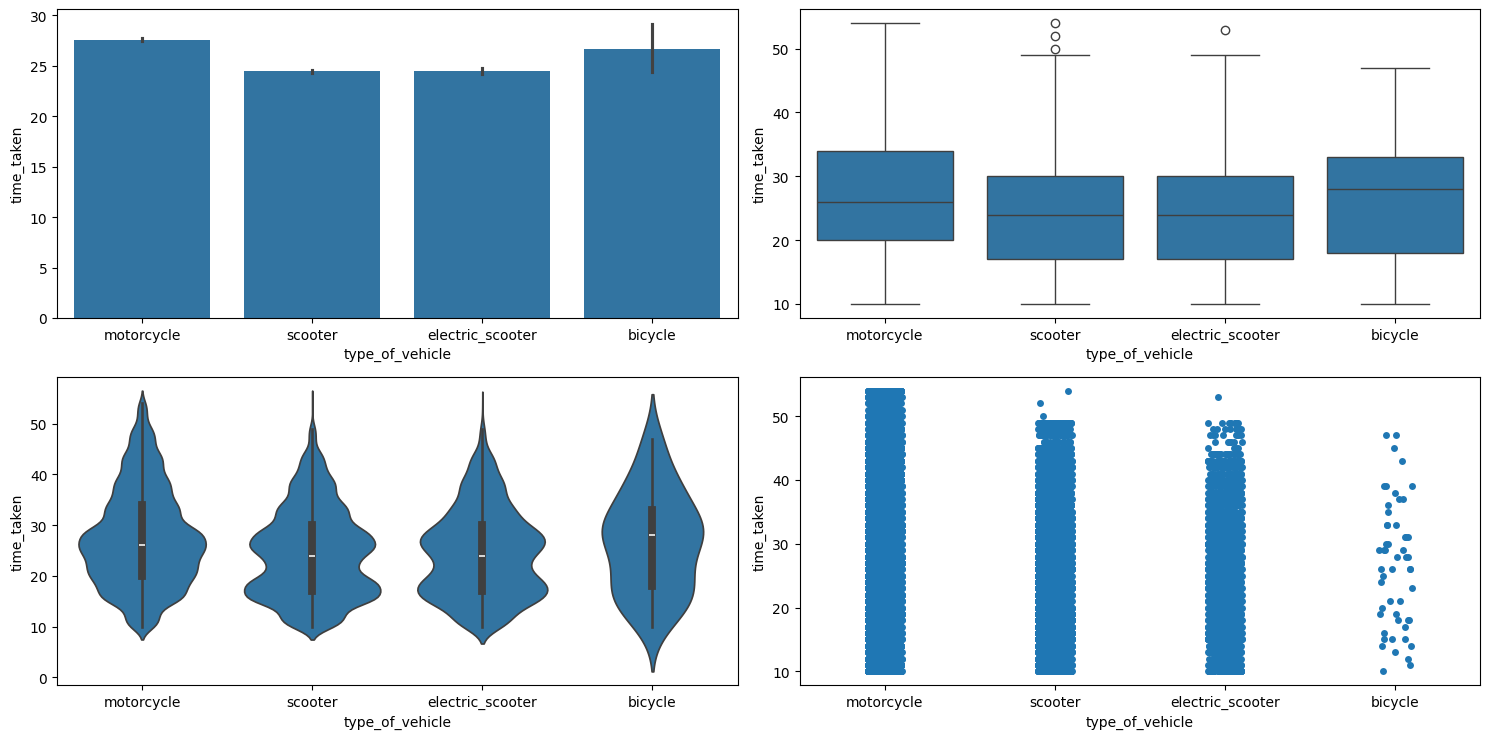

In [99]:
# does the type of vehicle affects delivery time
numerical_categorical_analysis(df_final, "type_of_vehicle", "time_taken")

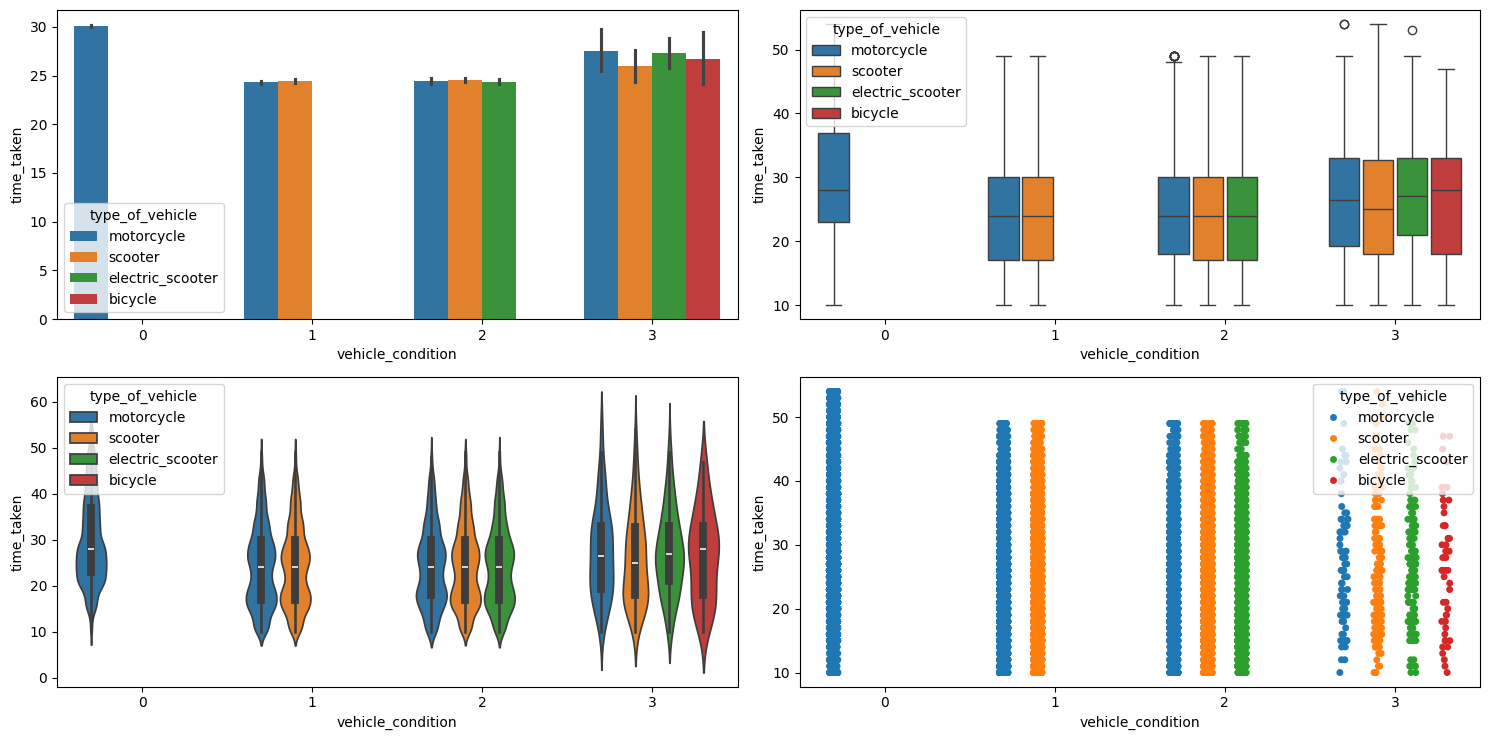

In [100]:
# vehicle condition and type
multivariate_analysis(df_final, "time_taken", "vehicle_condition", "type_of_vehicle")

**`Delivery time is more influenced by vehicle condition than vehicle type, as differences across vehicle types are minimal while poorer vehicle condition shows consistently higher delivery times`**

In [102]:
# is their a relation between vehicle type and conditions
chi_square_test(df_final, "type_of_vehicle", "vehicle_condition")

Chi-Square Statistic : 28159.4382
Degrees of Freedom  : 9
P-value             : 0.000000
❌ Reject the Null Hypothesis: There is a significant association between 'type_of_vehicle' and 'vehicle_condition'.


## Type of Order

,Count,Percentage
type_of_order,,
snack,11512,25.3%
meal,11435,25.13%
drinks,11294,24.82%
buffet,11261,24.75%


**************************************************
The unique categories in type_of_order column are ['snack', 'drinks', 'buffet', 'meal']
**************************************************
The number of categories in type_of_order column are 4


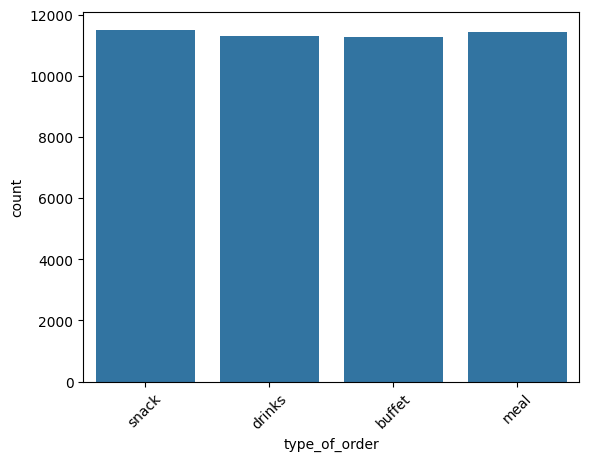

In [103]:
#Analysis on type of order
categorical_analysis(df_final,"type_of_order")

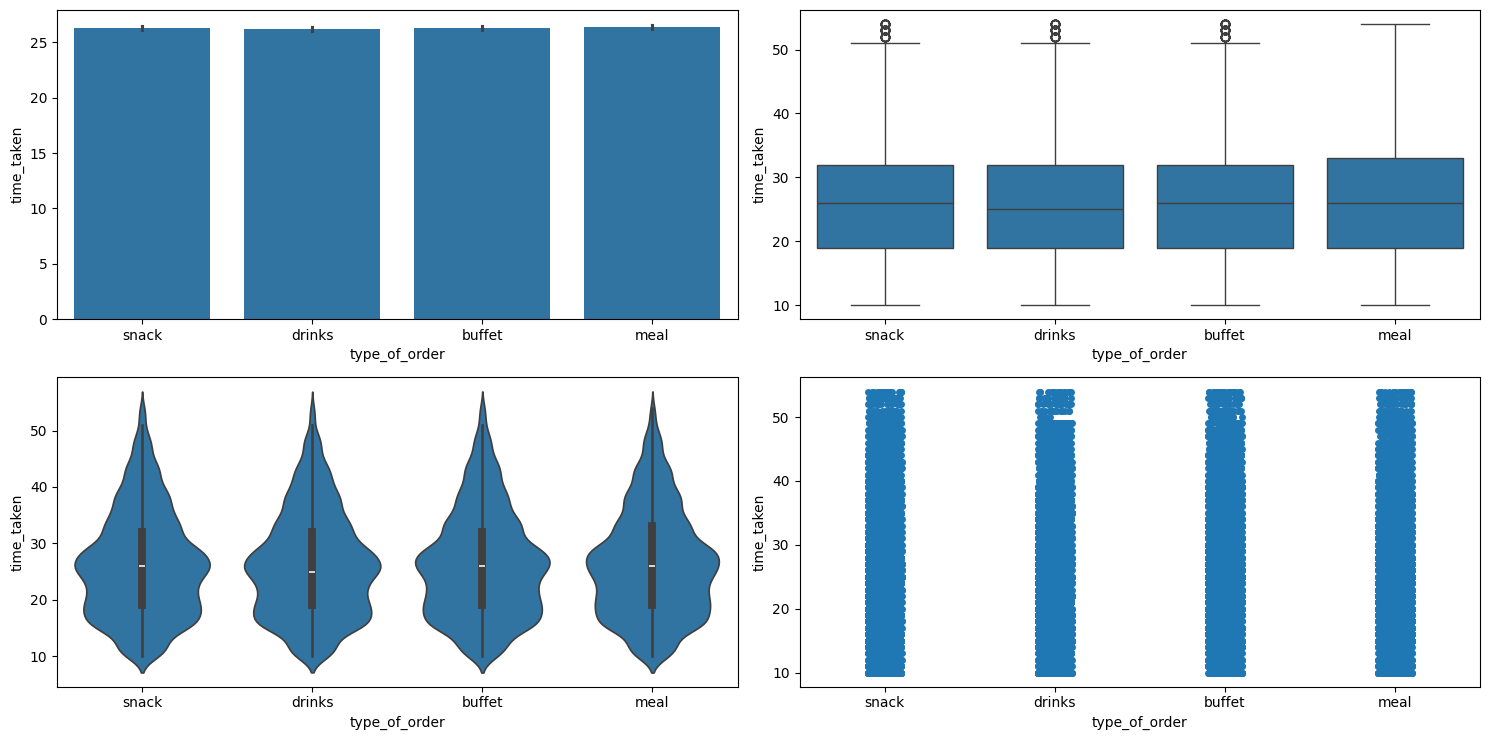

In [104]:
# does order type have have effect on delivery times
numerical_categorical_analysis(df_final, "type_of_order", "time_taken")

In [105]:
#Anova Test
anova_test(df_final,"time_taken","type_of_order")

F-Statistic : 1.2099
P-value     : 0.304331
✅ Fail to Reject the Null Hypothesis: There is no significant difference in 'time_taken' across 'type_of_order' categories.


In [106]:
# contingency table
pd.crosstab(df_final["type_of_order"],df_final["is_weekend"])

is_weekend,0,1
type_of_order,,
buffet,8238,3023
drinks,8130,3164
meal,8290,3145
snack,8337,3175


In [107]:
# does type of order have an effect over pickup time
chi_square_test(df_final,"pickup_time_minutes",'type_of_order')

Chi-Square Statistic : 5.4200
Degrees of Freedom  : 6
P-value             : 0.491181
✅ Fail to Reject the Null Hypothesis: There is no significant association between 'pickup_time_minutes' and 'type_of_order'.


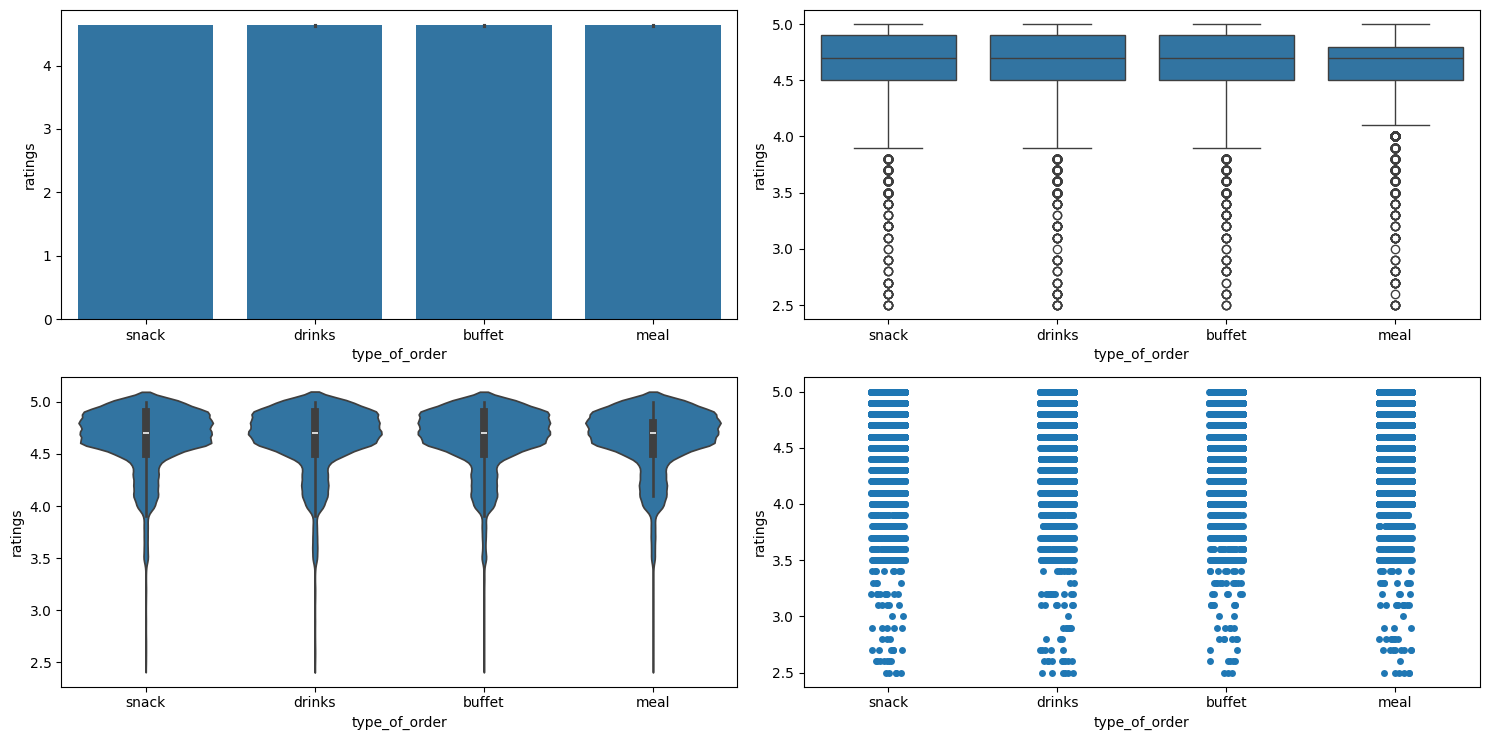

In [108]:
# does order type has an effect on ratings
numerical_categorical_analysis(df_final, "type_of_order", "ratings")

In [109]:
# is their a relationship between weekends and type of order
chi_square_test(df_final,"is_weekend",'type_of_order')

Chi-Square Statistic : 3.9600
Degrees of Freedom  : 3
P-value             : 0.265816
✅ Fail to Reject the Null Hypothesis: There is no significant association between 'is_weekend' and 'type_of_order'.


In [110]:
# is their a relationship between festivals and type of order
chi_square_test(df_final,"festival","type_of_order")

Chi-Square Statistic : 1.8002
Degrees of Freedom  : 3
P-value             : 0.614902
✅ Fail to Reject the Null Hypothesis: There is no significant association between 'festival' and 'type_of_order'.


## City Name

,Count,Percentage
city_name,,
JAP,3439,7.56%
RANCHI,3222,7.08%
BANG,3184,7.0%
SUR,3182,6.99%
HYD,3177,6.98%
MUM,3168,6.96%
MYS,3164,6.95%
COIMB,3162,6.95%
VAD,3159,6.94%


**************************************************
The unique categories in city_name column are ['INDO', 'BANG', 'COIMB', 'CHEN', 'HYD', 'RANCHI', 'MYS', 'DEH', 'KOC', 'PUNE', 'LUDH', 'KNP', 'MUM', 'KOL', 'JAP', 'SUR', 'GOA', 'AURG', 'AGR', 'VAD', 'ALH', 'BHP']
**************************************************
The number of categories in city_name column are 22


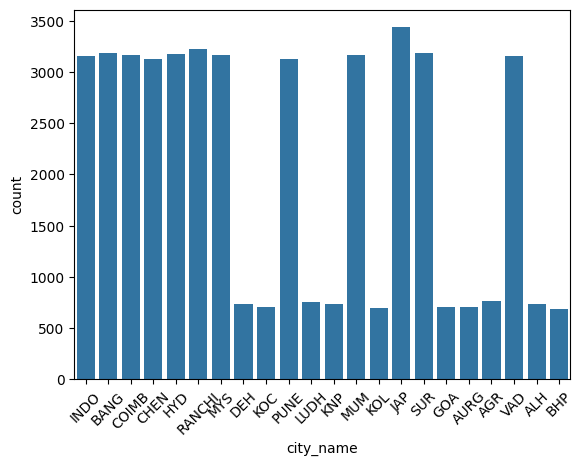

In [111]:
# categorical analysis on city name
categorical_analysis(df_final, "city_name")

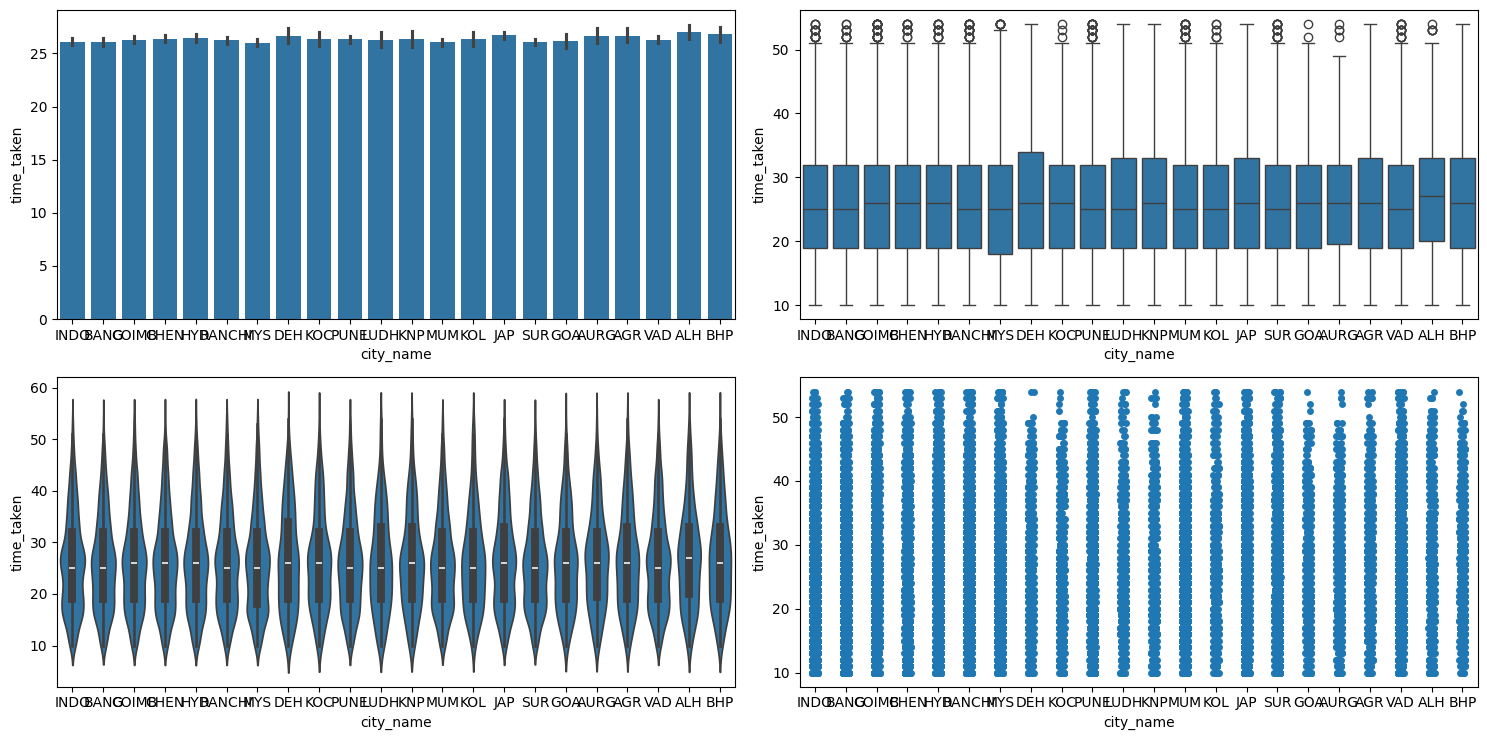

In [113]:
# does a city affects delivery times
numerical_categorical_analysis(df_final,"city_name","time_taken")

,Count,Percentage
city_type,,
metropolitian,34029,76.81%
urban,10111,22.82%
semi-urban,164,0.37%


**************************************************
The unique categories in city_type column are ['urban', 'metropolitian', 'semi-urban', nan]
**************************************************
The number of categories in city_type column are 3


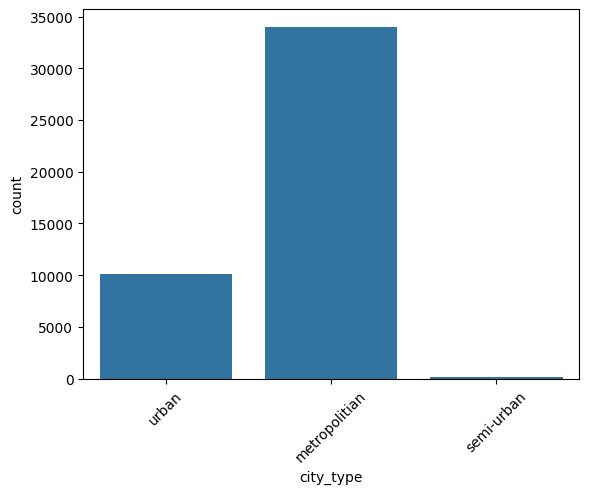

In [114]:
# categorical analysis on city type
categorical_analysis(df_final, "city_type")

### 🏙️ City Category Meanings

- <span style="color:#60a5fa;"><b>Urban</b> – Well-developed city areas with high population density and established infrastructure.</span>

- <span style="color:#34d399;"><b>Metropolitian</b> – Large metropolitan cities with advanced infrastructure, heavy traffic, and high commercial activity.</span>

- <span style="color:#facc15;"><b>Semi-Urban</b> – Transitional areas between urban and rural regions with moderate development.</span>


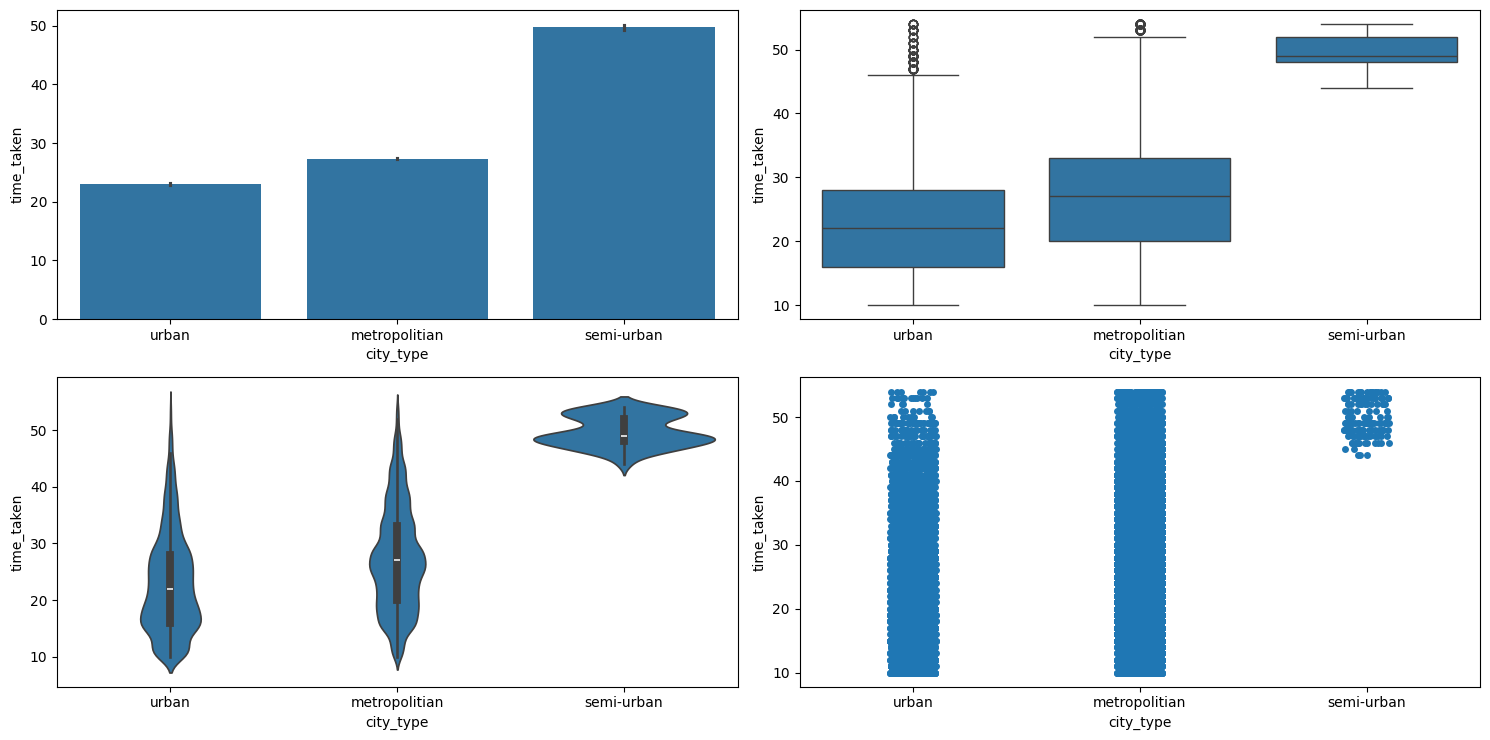

In [115]:
# does city types affect delivery times
numerical_categorical_analysis(df_final, "city_type", "time_taken")

**`Delivery time increases as we move from Urban → Metropolitan → Semi-Urban areas.
Infrastructure density and distance likely play a major role in delivery performance.`**

In [117]:
# Anova test
anova_test(df_final, "time_taken", "city_type") #There is a significant relationship between time_taken and city_type.

F-Statistic : 1423.3223
P-value     : 0.000000
❌ Reject the Null Hypothesis: The mean of 'time_taken' differs significantly across 'city_type' categories.


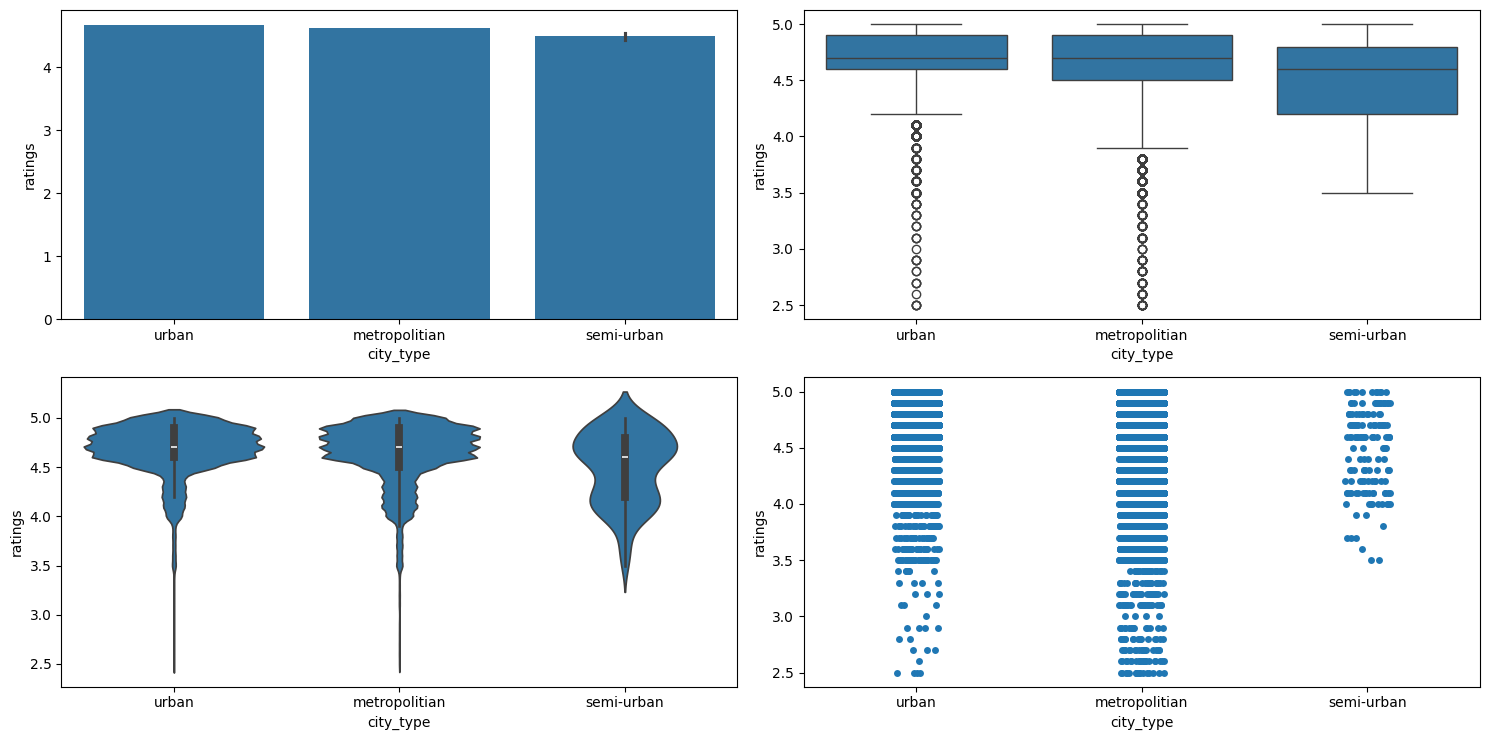

In [118]:
# does city type affects rider ratings
numerical_categorical_analysis(df_final, "city_type", "ratings")

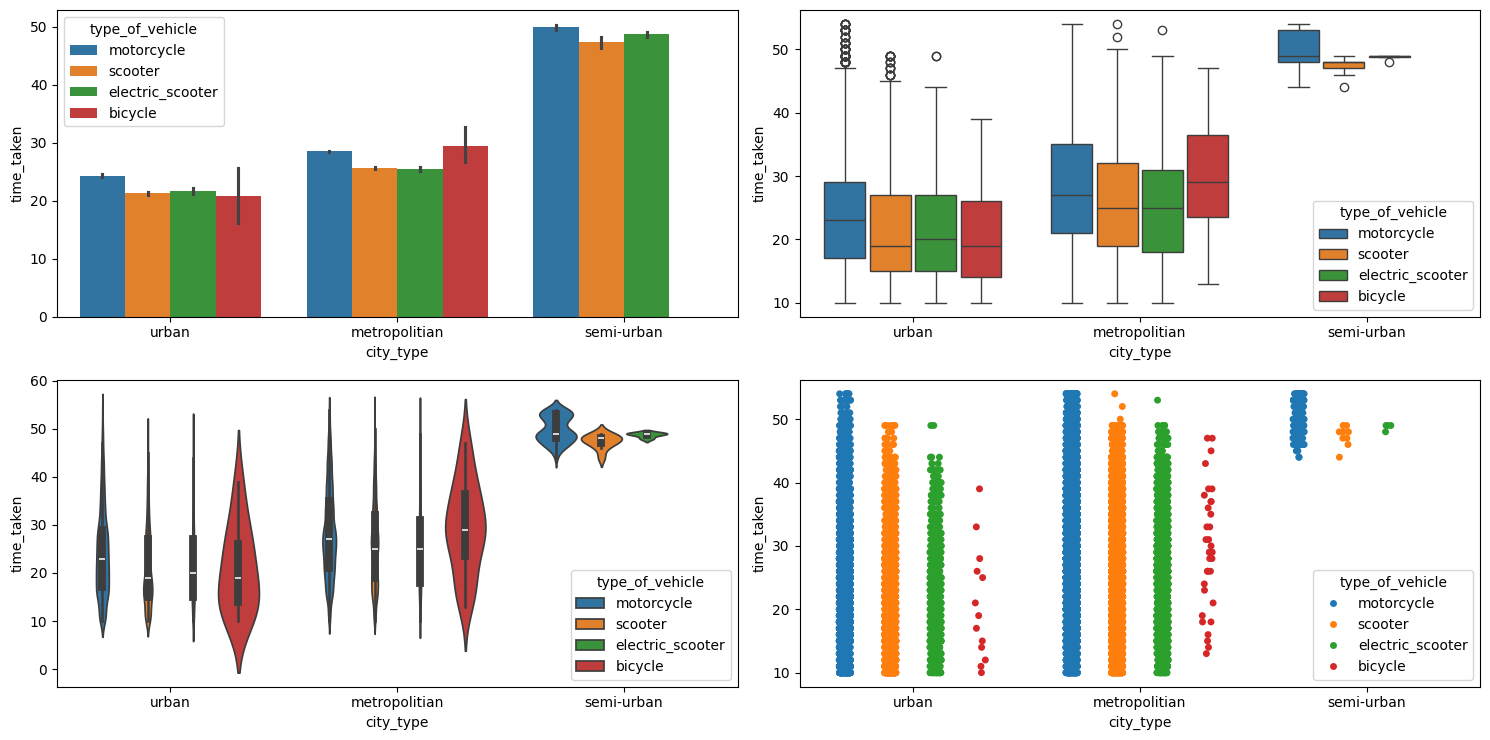

In [119]:
# city type, type of vehicle and delivery time analysis
multivariate_analysis(df_final, "time_taken", "city_type", "type_of_vehicle")

## Distance

📊 Statistical Summary
Mean      : 9.719
Median    : 9.193
Std Dev   : 5.603
Skewness  : 0.325
Kurtosis  : -0.906
⚖ Distribution is approximately Symmetric
Q1: 4.657654937060173
Q3: 13.68092007746041
🚨 Number of Outliers (IQR method): 0


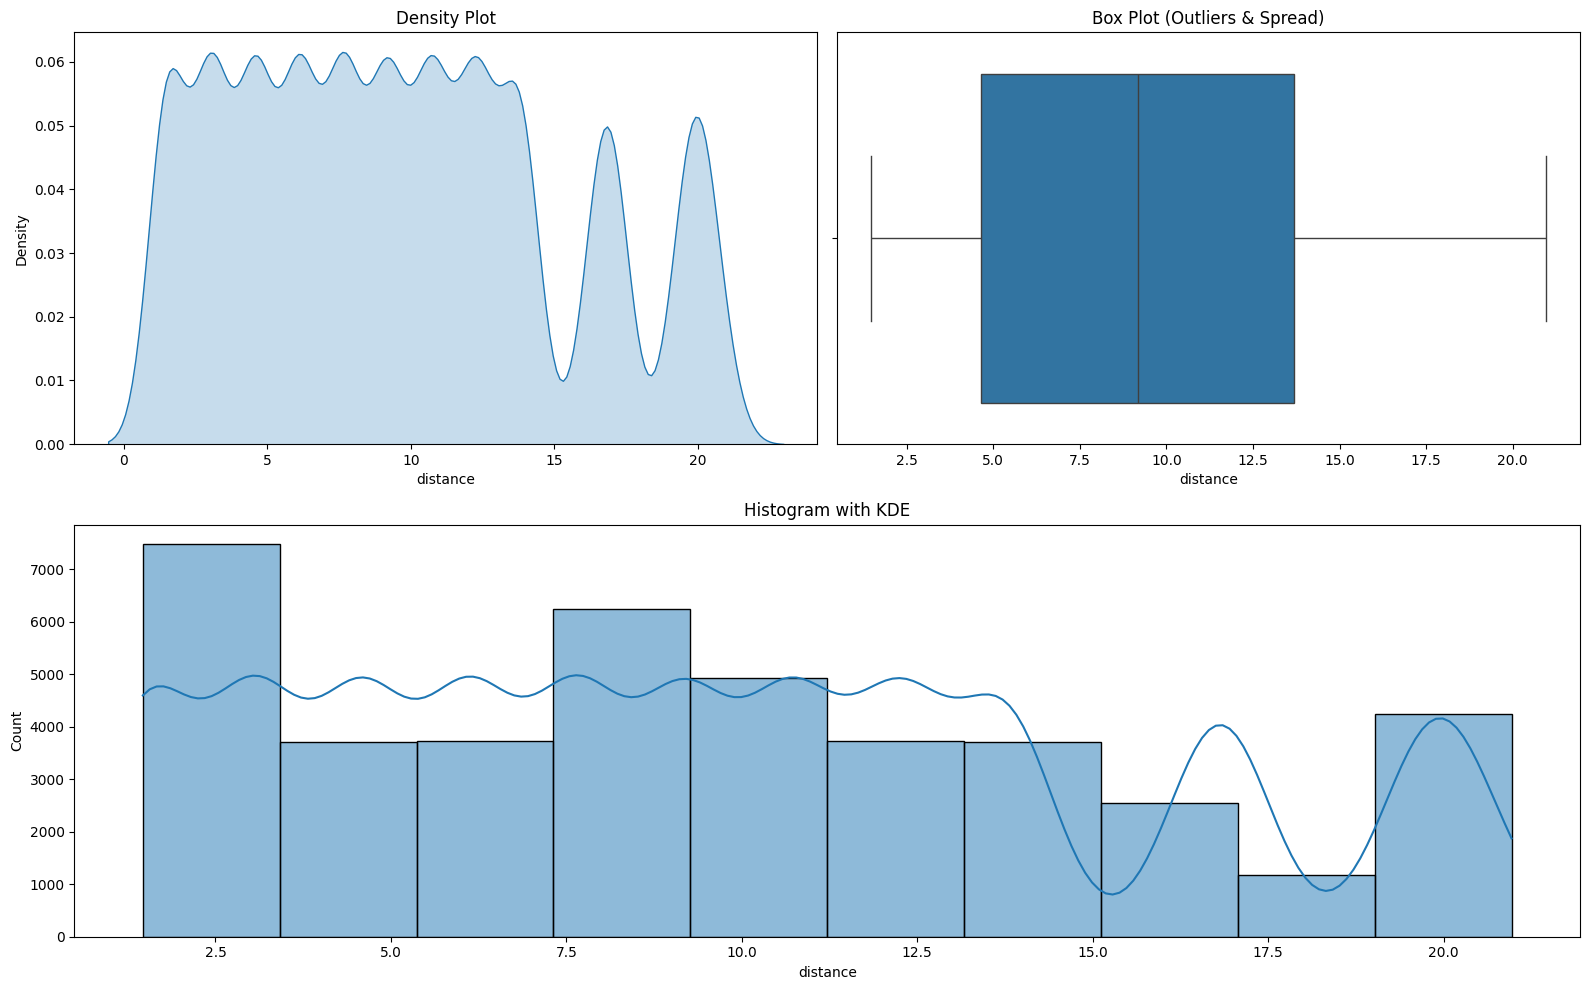

In [120]:
# numerical analysis of distance
numerical_analysis(df_final, "distance",bins=10)

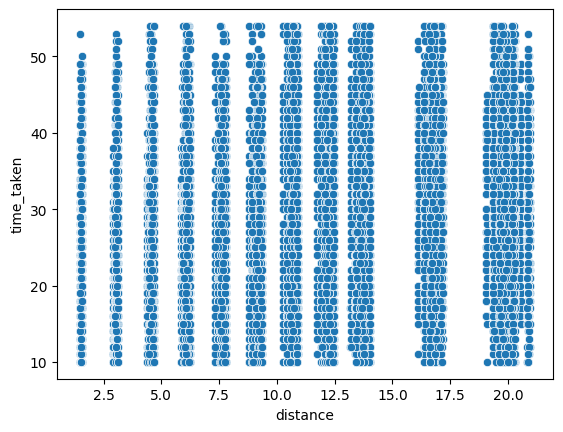

In [121]:
# relationship between distance and delivery times
sns.scatterplot(df_final,x="distance",y="time_taken")
plt.show()

In [122]:
# corr
df_final[["distance","time_taken"]].corr()

,distance,time_taken
distance,1.000000,0.321176
time_taken,0.321176,1.000000


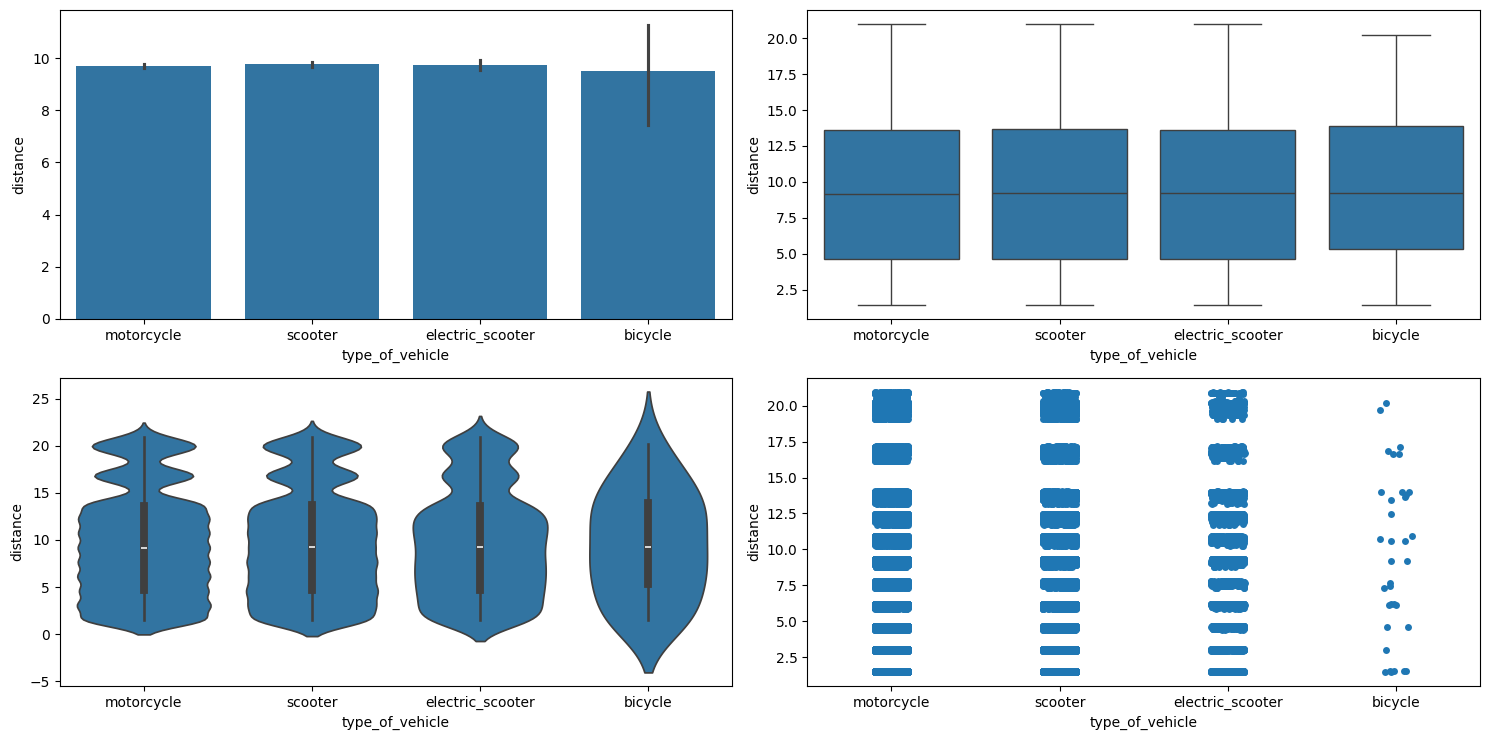

In [123]:
# vehicle type and distance analysis
numerical_categorical_analysis(df_final, "type_of_vehicle", "distance")

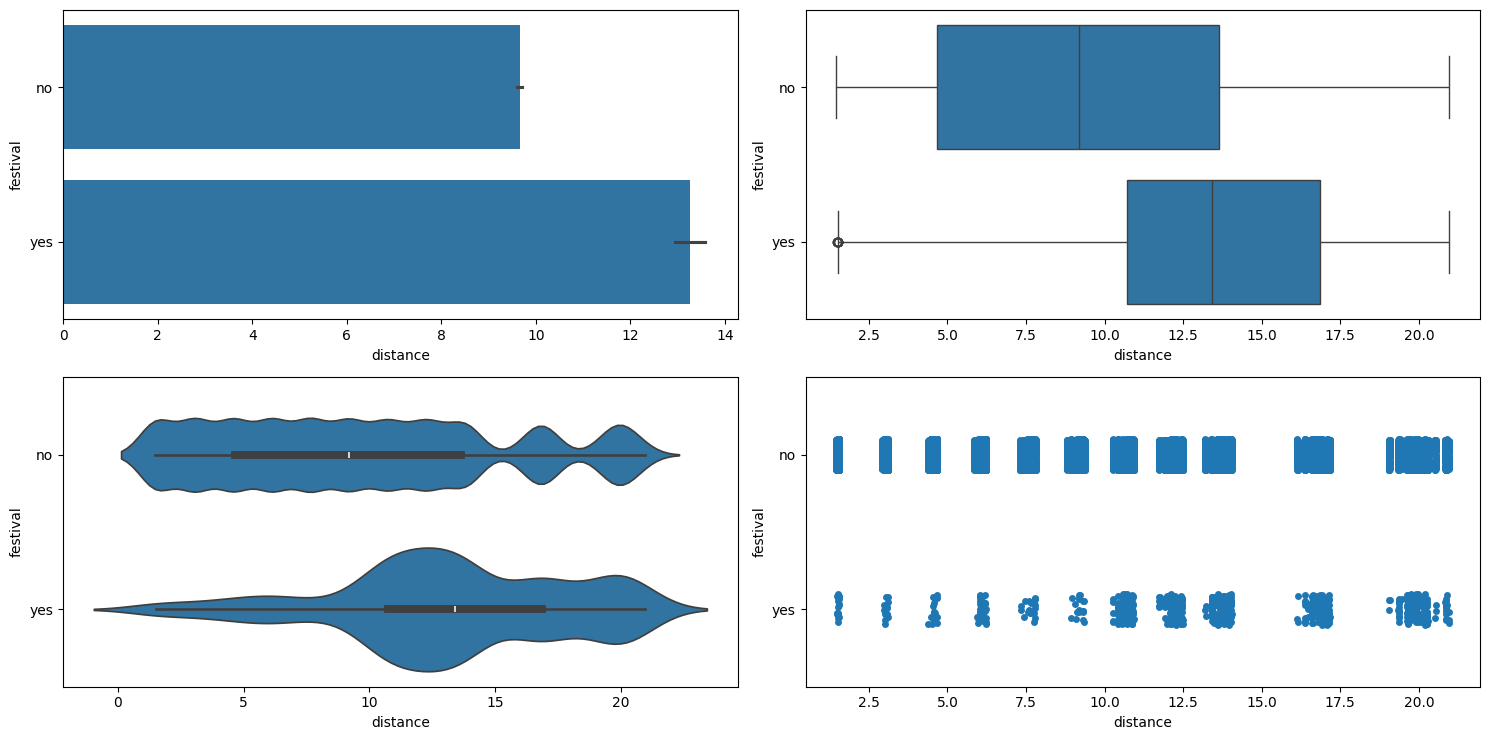

In [124]:
# do riders cover more distances during festivals
numerical_categorical_analysis(df_final, "distance", "festival")

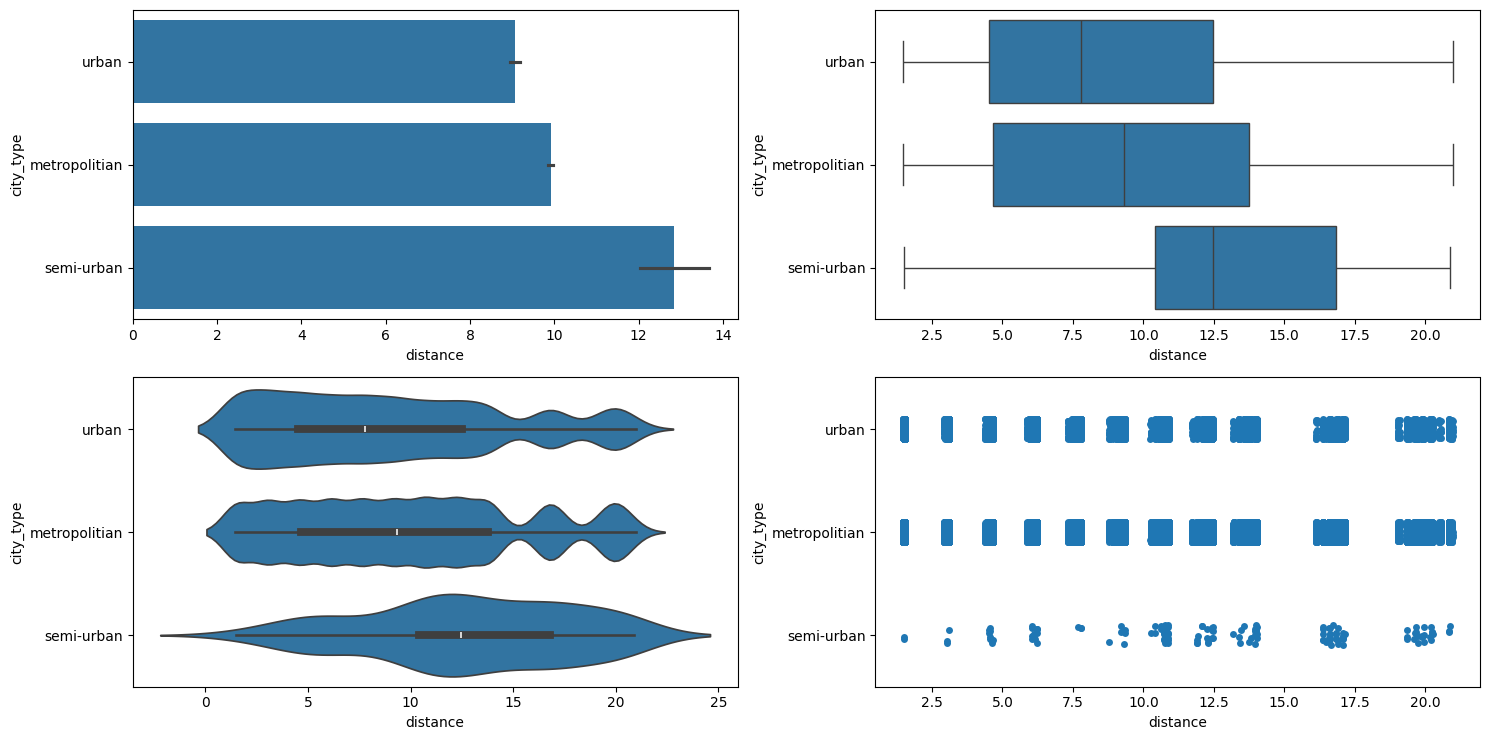

In [125]:
# distance and city type
numerical_categorical_analysis(df_final, "distance", "city_type")

In [126]:
# new feature based on distance
df_final = df_final.assign(distance_type = pd.cut(df_final["distance"],bins=[0,5,10,15,25],right=False,labels=["short","medium","long","very_long"]))

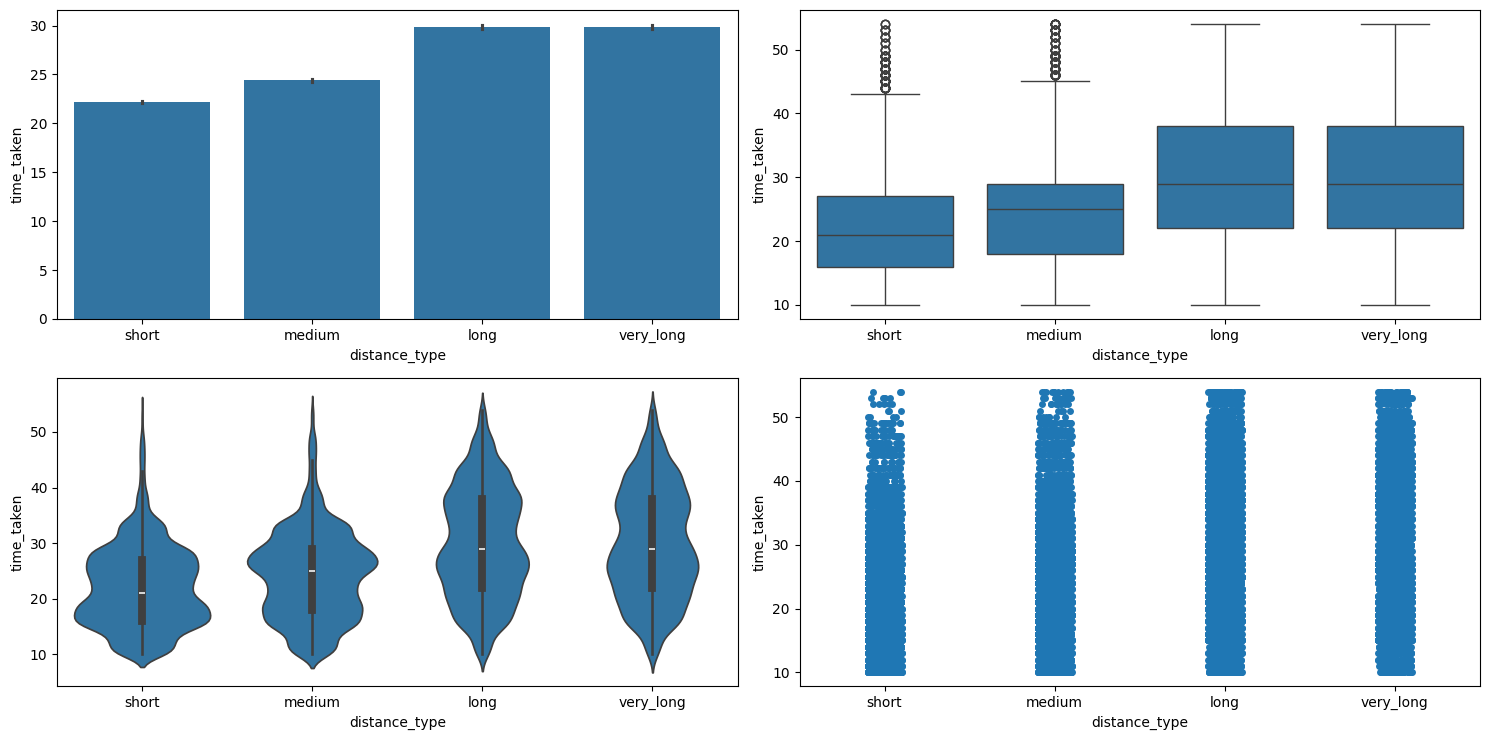

In [129]:
# does distance type affects delivery times
numerical_categorical_analysis(df_final, "distance_type", "time_taken")

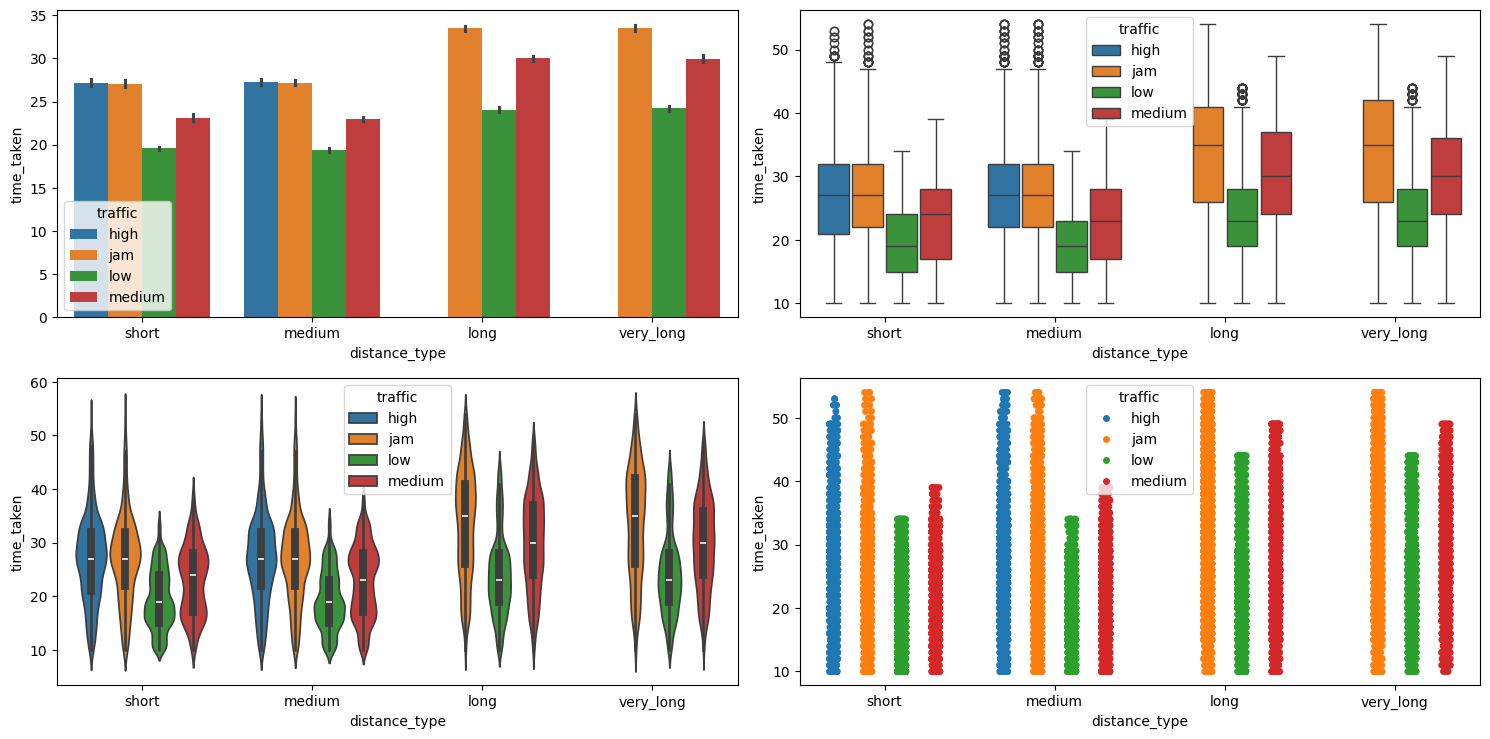

In [130]:
# delivery times based on distance and traffic
multivariate_analysis(df_final, "time_taken", "distance_type", "traffic")

### 🚚 Delivery Time vs Distance Type & Traffic – Interpretation

- <span style="color:#60a5fa;">Delivery time increases as <b>distance type increases</b> (short → medium → long → very_long), showing a strong positive relationship between distance and time taken.</span>

- <span style="color:#f87171;"><b>Traffic condition has a significant impact</b> on delivery time. Orders during <b>traffic jams</b> consistently take the longest time across all distance categories.</span>

- <span style="color:#34d399;"><b>Low traffic</b> results in the fastest deliveries, regardless of distance type.</span>

- <span style="color:#facc15;">For long and very long distances, the effect of traffic becomes more pronounced, increasing delivery time substantially under high or jam conditions.</span>

- <span style="color:#a78bfa;">Medium traffic conditions show moderate delivery times, lying between low and jam categories consistently.</span>

- <span style="color:#fb923c;">Variability (spread) increases for longer distances, meaning delivery time becomes less predictable as distance grows.</span>